In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[3]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd

DATA = PROJECT_ROOT / "data" / "processed" / "preprocessed_data_2"

print(PROJECT_ROOT)

c:\Users\herosys\codeit-final\team4-final-project


In [2]:
user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
uqr  = pd.read_csv(DATA / "accounts_userquestionrecord_preprocessed_2.csv")
fr   = pd.read_csv(DATA / "accounts_friendrequest_preprocessed_2.csv",
                   usecols=['send_user_id', 'receive_user_id', 'status'])
pay  = pd.read_csv(DATA / "accounts_paymenthistory_preprocessed_2.csv")

uqr['created_at'] = pd.to_datetime(uqr['created_at'])

print(f"user {len(user):,} / uqr {len(uqr):,} / fr {len(fr):,} / pay {len(pay):,}")

user 677,075 / uqr 800,793 / fr 7,793,140 / pay 95,137


In [3]:
step1 = set(user['id'])

fr_a = fr[fr['status'] == 'A']
friends = pd.concat([fr_a['send_user_id'], fr_a['receive_user_id']]).value_counts()
step2 = set(friends.index) & step1

step3 = step2 & set(uqr['chosen_user_id'])

print(f"Step 1 가입:      {len(step1):>9,}")
print(f"Step 2 친구 형성: {len(step2):>9,}  ({len(step2)/len(step1)*100:.2f}%)")
print(f"Step 3 투표 수신: {len(step3):>9,}  ({len(step3)/len(step2)*100:.2f}%)")

Step 1 가입:        677,075
Step 2 친구 형성:   574,163  (84.80%)
Step 3 투표 수신:    10,647  (1.85%)


In [4]:
recv = uqr['chosen_user_id'].value_counts()

print(f"수신자 {len(recv):,}명 / 총 {recv.sum():,}건")
print(f"중앙값 {recv.median():.0f}건 / 평균 {recv.mean():.1f}건 / 최대 {recv.max():,}건")
print()
for p in [0.01, 0.05, 0.1, 0.2, 0.5]:
    n = int(len(recv) * p)
    print(f"상위 {p*100:>4.0f}% ({n:>5,}명) 점유율: {recv.head(n).sum()/recv.sum()*100:5.1f}%")

수신자 13,811명 / 총 800,793건
중앙값 10건 / 평균 58.0건 / 최대 1,054건

상위    1% (  138명) 점유율:  10.5%
상위    5% (  690명) 점유율:  37.2%
상위   10% (1,381명) 점유율:  58.7%
상위   20% (2,762명) 점유율:  81.7%
상위   50% (6,905명) 점유율:  97.2%


In [5]:
prof = user.copy()
prof['friend_cnt'] = prof['id'].map(friends).fillna(0).astype(int)
prof['수신건수'] = prof['id'].map(recv).fillna(0).astype(int)

sub = prof[prof['friend_cnt'] > 0]
print(sub.groupby(pd.cut(sub['friend_cnt'], [0,9,29,59,99,float('inf')],
    labels=['1-9','10-29','30-59','60-99','100+']), observed=True).agg(
    인원=('id','size'),
    수신경험=('수신건수', lambda x: (x>0).sum()),
    수신률=('수신건수', lambda x: round((x>0).mean()*100,2)),
    평균수신=('수신건수','mean')
).round(2))

                인원  수신경험   수신률  평균수신
friend_cnt                          
1-9         175358  3866  2.20  0.63
10-29       189570  3107  1.64  1.26
30-59       144557  2383  1.65  1.44
60-99        55672  1103  1.98  2.66
100+          9006   188  2.09  3.70


In [6]:
top = set(recv.head(int(len(recv)*0.1)).index)
prof['상위수신'] = prof['id'].isin(top)

print(prof[prof['id'].isin(set(recv.index))].groupby('상위수신').agg(
    인원=('id','size'),
    평균친구=('friend_cnt','mean'),
    친구중앙=('friend_cnt','median'),
    포인트중앙=('point','median'),
    결제율=('id', lambda x: round(x.isin(set(pay['user_id'])).mean()*100,2))
).round(1))

          인원  평균친구  친구중앙   포인트중앙   결제율
상위수신                                  
False  12430  17.6   7.0  1123.0   7.8
True    1381  44.0  38.0  1614.0  12.4


In [7]:
recv_df = recv.to_frame('수신건수')
recv_df['결제'] = recv_df.index.isin(set(pay['user_id']))

print(recv_df.groupby(pd.cut(recv_df['수신건수'], [0,5,20,100,500,float('inf')],
    labels=['1-5','6-20','21-100','101-500','500+']), observed=True).agg(
    인원=('결제','size'),
    결제율=('결제', lambda x: round(x.mean()*100,2))
))

           인원    결제율
수신건수                
1-5      5554   7.76
6-20     3120   7.24
21-100   2683   7.16
101-500  2304  11.72
500+      150  16.00


In [8]:
sub = prof[prof['수신건수'] > 0]
print(sub.groupby(pd.cut(sub['friend_cnt'], [0,9,29,59,99,float('inf')],
    labels=['1-9','10-29','30-59','60-99','100+']), observed=True).agg(
    인원=('id','size'),
    수신중앙=('수신건수','median'),
    수신평균=('수신건수','mean'),
    백건이상=('수신건수', lambda x: round((x>=100).mean()*100,1))
).round(1))

              인원  수신중앙   수신평균  백건이상
friend_cnt                         
1-9         3866   6.0   28.5   7.7
10-29       3107  16.0   76.9  27.1
30-59       2383  15.0   87.3  30.6
60-99       1103  24.0  134.3  37.6
100+         188  25.5  177.4  39.9


In [9]:
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()
first_pay = pay.groupby('user_id')['created_at'].min()
pay['created_at'] = pd.to_datetime(pay['created_at'])

common = first_recv.index.intersection(first_pay.index)
cmp = pd.DataFrame({'첫수신': first_recv.loc[common], '첫결제': first_pay.loc[common]})
print(f"수신이 먼저: {(cmp['첫수신'] < cmp['첫결제']).sum():,}명")
print(f"결제가 먼저: {(cmp['첫결제'] < cmp['첫수신']).sum():,}명")

수신이 먼저: 788명
결제가 먼저: 355명


In [10]:
# 친구를 보낸 쪽 vs 받은 쪽 구분
sent = fr_a['send_user_id'].value_counts()
recvd = fr_a['receive_user_id'].value_counts()

prof['친구_발신'] = prof['id'].map(sent).fillna(0).astype(int)
prof['친구_수신'] = prof['id'].map(recvd).fillna(0).astype(int)

sub = prof[prof['수신건수'] > 0]
print("친구 요청을 받은 횟수(인기도)와 투표 수신량의 관계")
print(sub.groupby(pd.cut(sub['친구_수신'], [-1,4,14,29,59,float('inf')],
    labels=['0-4','5-14','15-29','30-59','60+']), observed=True).agg(
    인원=('id','size'),
    투표수신중앙=('수신건수','median'),
    백건이상=('수신건수', lambda x: round((x>=100).mean()*100,1))
).round(1))

친구 요청을 받은 횟수(인기도)와 투표 수신량의 관계
         인원  투표수신중앙  백건이상
친구_수신                    
0-4    7178     7.0   6.2
5-14   3098    14.0  24.4
15-29  1967    19.0  35.1
30-59  1346    17.0  34.9
60+     222    37.5  43.7


In [11]:
sub2 = prof[prof['friend_cnt'] > 0]
detail = sub2.groupby('friend_cnt').agg(
    인원=('id','size'),
    수신경험=('수신건수', lambda x: (x>0).sum())
)
detail['수신률'] = (detail['수신경험'] / detail['인원'] * 100).round(2)

print("친구 1~15명 구간 세부")
print(detail.head(15))

친구 1~15명 구간 세부
               인원  수신경험   수신률
friend_cnt                   
1           27473   873  3.18
2           23636   652  2.76
3           22033   513  2.33
4           21252   428  2.01
5           18535   350  1.89
6           16844   277  1.64
7           16078   253  1.57
8           15276   245  1.60
9           14231   275  1.93
10          13395   208  1.55
11          12895   240  1.86
12          12308   203  1.65
13          11643   188  1.61
14          11107   190  1.71
15          10684   160  1.50


In [12]:
qpiece = pd.read_csv(DATA / "polls_questionpiece_preprocessed_2.csv")
print(f"질문 인스턴스: {len(qpiece):,}건")
print(f"투표 기록: {len(uqr):,}건")
print(f"투표율: {len(uqr)/len(qpiece)*100:.1f}%")

질문 인스턴스: 823,739건
투표 기록: 800,793건
투표율: 97.2%


In [13]:
uqr['월'] = uqr['created_at'].dt.to_period('M')

for m in sorted(uqr['월'].unique())[:6]:
    sub_m = uqr[uqr['월'] == m]
    r = sub_m['chosen_user_id'].value_counts()
    if len(r) < 10: continue
    top10 = r.head(int(len(r)*0.1)).sum() / r.sum() * 100
    print(f"{m}: 수신자 {len(r):>6,}명, 상위10% 점유 {top10:5.1f}%")

2023-05: 수신자 12,882명, 상위10% 점유  58.0%
2023-06: 수신자  7,932명, 상위10% 점유  51.4%
2023-07: 수신자  2,433명, 상위10% 점유  32.8%
2023-08: 수신자  1,135명, 상위10% 점유  29.0%
2023-09: 수신자  1,078명, 상위10% 점유  29.0%
2023-10: 수신자    244명, 상위10% 점유  25.2%


In [14]:
zero = prof[(prof['friend_cnt'] > 0) & (prof['pending_votes'] == 0)]
nonzero = prof[(prof['friend_cnt'] > 0) & (prof['pending_votes'] > 0)]

print(f"친구 있고 pending_votes=0: {len(zero):,}명")
print(f"친구 있고 pending_votes>0: {len(nonzero):,}명")
print()
print(pd.DataFrame({
    'pending=0': zero[['friend_cnt','point','alarm_count']].median(),
    'pending>0': nonzero[['friend_cnt','point','alarm_count']].median()
}).round(0))

친구 있고 pending_votes=0: 96,473명
친구 있고 pending_votes>0: 477,690명

             pending=0  pending>0
friend_cnt        17.0       20.0
point            698.0     1074.0
alarm_count        0.0        1.0


In [15]:
grp_size = prof.groupby('group_id').size().rename('학급인원')
prof['학급인원'] = prof['group_id'].map(grp_size)

sub3 = prof[prof['수신건수'] > 0]
print(sub3.groupby(pd.cut(sub3['학급인원'], [0,4,9,19,49,float('inf')],
    labels=['1-4','5-9','10-19','20-49','50+']), observed=True).agg(
    인원=('id','size'),
    수신중앙=('수신건수','median'),
    친구중앙=('friend_cnt','median')
).round(1))

         인원  수신중앙  친구중앙
학급인원                   
1-4     538   3.0   3.0
5-9    1693   4.0   8.0
10-19  8710  10.0   9.0
20-49  2858  23.0  10.0
50+      12   1.5   3.5


In [16]:
sub = prof[prof['수신건수'] > 0].copy()
sub['인기도'] = pd.cut(sub['친구_수신'], [-1,4,14,float('inf')],
                      labels=['낮음(0-4)','중간(5-14)','높음(15+)'])
sub['학급'] = pd.cut(sub['학급인원'], [0,9,19,float('inf')],
                    labels=['소(1-9)','중(10-19)','대(20+)'])

print("수신 중앙값")
print(sub.pivot_table(index='인기도', columns='학급', values='수신건수',
                      aggfunc='median', observed=True))
print()
print("100건 이상 도달률(%)")
print(sub.pivot_table(index='인기도', columns='학급', values='수신건수',
                      aggfunc=lambda x: round((x>=100).mean()*100,1), observed=True))
print()
print("인원")
print(sub.pivot_table(index='인기도', columns='학급', values='id',
                      aggfunc='size', observed=True))

수신 중앙값
학급        소(1-9)  중(10-19)  대(20+)
인기도                               
낮음(0-4)      3.0       7.0    15.0
중간(5-14)     5.0      14.0    38.0
높음(15+)      6.0      18.0   145.0

100건 이상 도달률(%)


학급        소(1-9)  중(10-19)  대(20+)
인기도                               
낮음(0-4)      1.9       5.2    13.3
중간(5-14)     9.3      24.6    35.0
높음(15+)     11.7      33.7    54.9

인원
학급        소(1-9)  중(10-19)  대(20+)
인기도                               
낮음(0-4)     1299      4447    1432
중간(5-14)     497      1921     680
높음(15+)      435      2342     758


In [17]:
zero = prof[(prof['friend_cnt'] > 0) & (prof['pending_votes'] == 0)]
in_uqr = zero['id'].isin(set(uqr['chosen_user_id']))

print(f"친구 있고 pending_votes=0: {len(zero):,}명")
print(f"  uqr 수신 기록 있음: {in_uqr.sum():,}명 (받았으나 전량 확인)")
print(f"  uqr 기록 없음:     {(~in_uqr).sum():,}명 (안 받았거나 표본 밖)")
print()
print(zero.groupby(in_uqr).agg(
    인원=('id','size'),
    친구중앙=('friend_cnt','median'),
    포인트중앙=('point','median'),
    결제율=('id', lambda x: round(x.isin(set(pay['user_id'])).mean()*100,2))
).round(1))

친구 있고 pending_votes=0: 96,473명
  uqr 수신 기록 있음: 1,445명 (받았으나 전량 확인)
  uqr 기록 없음:     95,028명 (안 받았거나 표본 밖)

          인원  친구중앙  포인트중앙   결제율
id                             
False  95028  17.0  696.0  11.8
True    1445  16.0  872.0  12.9


In [18]:
sub = prof[prof['수신건수'] > 0].copy()
sub['학급내순위'] = sub.groupby('group_id')['수신건수'].rank(pct=True, ascending=False)

print(sub.groupby(pd.cut(sub['학급내순위'], [0,0.2,0.5,0.8,1.0],
    labels=['상위20%','20-50%','50-80%','하위20%']), observed=True).agg(
    인원=('id','size'),
    수신중앙=('수신건수','median'),
    친구중앙=('friend_cnt','median'),
    결제율=('id', lambda x: round(x.isin(set(pay['user_id'])).mean()*100,2))
).round(1))

          인원  수신중앙  친구중앙  결제율
학급내순위                        
상위20%   1415  82.0  13.0  9.5
20-50%  3702  22.0   9.0  8.5
50-80%  3055  10.0   9.0  8.5
하위20%   5639   3.0   8.0  7.7


In [19]:
# 사용자별로 몇 개의 서로 다른 질문에서 선택됐나
q_variety = uqr.groupby('chosen_user_id')['question_id'].nunique()
recv_cnt = uqr['chosen_user_id'].value_counts()

df = pd.DataFrame({'수신건수': recv_cnt, '질문종류': q_variety})
df['질문당수신'] = (df['수신건수'] / df['질문종류']).round(2)

print(df.groupby(pd.cut(df['수신건수'], [0,10,50,100,500,float('inf')],
    labels=['1-10','11-50','51-100','101-500','500+']), observed=True).agg(
    인원=('수신건수','size'),
    질문종류중앙=('질문종류','median'),
    질문당수신=('질문당수신','median')
).round(2))

           인원  질문종류중앙  질문당수신
수신건수                        
1-10     7093     3.0   1.00
11-50    3277    21.0   1.00
51-100    987    68.0   1.03
101-500  2304   191.0   1.10
500+      150   456.0   1.27


In [20]:
q = pd.read_csv(DATA / "polls_question_preprocessed_2.csv") if (DATA / "polls_question_preprocessed_2.csv").exists() else None

# 질문별 수신자 집중도
q_conc = uqr.groupby('question_id').agg(
    투표수=('id','size'),
    수신자수=('chosen_user_id','nunique')
)
q_conc['집중도'] = (q_conc['투표수'] / q_conc['수신자수']).round(2)

print(q_conc[q_conc['투표수'] >= 100]['집중도'].describe().round(2))
print()
print("집중도 상위 질문")
print(q_conc[q_conc['투표수'] >= 100].nlargest(10, '집중도'))

count    1536.00
mean        1.11
std         0.05
min         1.01
25%         1.07
50%         1.10
75%         1.15
max         1.31
Name: 집중도, dtype: float64

집중도 상위 질문
             투표수  수신자수   집중도
question_id                 
244          814   622  1.31
151          711   554  1.28
613          761   593  1.28
169          832   657  1.27
274          799   629  1.27
316          760   598  1.27
364          790   622  1.27
575          760   599  1.27
369          713   568  1.26
631          780   620  1.26


In [21]:
active = uqr.groupby(
    uqr['chosen_user_id'].map(prof.set_index('id')['group_id'])
)['chosen_user_id'].nunique().rename('활동인원')

grp = pd.DataFrame({'가입인원': grp_size, '활동인원': active}).fillna(0)
grp['활동률'] = (grp['활동인원'] / grp['가입인원'] * 100).round(1)

print(grp[grp['활동인원'] > 0].groupby(
    pd.cut(grp['가입인원'], [0,9,19,49,float('inf')],
           labels=['1-9','10-19','20-49','50+']), observed=True).agg(
    학급수=('가입인원','size'),
    가입중앙=('가입인원','median'),
    활동중앙=('활동인원','median'),
    활동률중앙=('활동률','median')
).round(1))

        학급수  가입중앙  활동중앙  활동률중앙
가입인원                          
1-9    1375   6.0   1.0   25.0
10-19  2565  14.0   1.0   10.0
20-49   448  22.0   2.0   10.0
50+       4  65.0   3.0    4.3


In [22]:
voted = set(uqr['user_id'])
recv = set(uqr['chosen_user_id'])

prof['투표함'] = prof['id'].isin(voted)
prof['수신함'] = prof['id'].isin(recv)

print(pd.crosstab(prof['투표함'], prof['수신함']))
print()

sub = prof[prof['수신함']]
print(sub.groupby('투표함').agg(
    인원=('id','size'),
    수신중앙=('수신건수','median'),
    결제율=('id', lambda x: round(x.isin(set(pay['user_id'])).mean()*100,2))
).round(1))

수신함     False  True 
투표함                 
False  663232   9549
True       32   4262

         인원   수신중앙  결제율
투표함                    
False  9549    4.0  7.8
True   4262  117.0  9.4


In [23]:
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()
last_recv = uqr.groupby('chosen_user_id')['created_at'].max()

span = (last_recv - first_recv).dt.days
recv_cnt = uqr['chosen_user_id'].value_counts()

df = pd.DataFrame({'수신건수': recv_cnt, '기간일': span})
df['일평균'] = (df['수신건수'] / df['기간일'].clip(lower=1)).round(2)

print(df.groupby(pd.cut(df['수신건수'], [0,10,50,100,500,float('inf')],
    labels=['1-10','11-50','51-100','101-500','500+']), observed=True).agg(
    인원=('수신건수','size'),
    기간중앙=('기간일','median'),
    일평균중앙=('일평균','median')
).round(2))

           인원   기간중앙  일평균중앙
수신건수                       
1-10     7093    3.0   1.00
11-50    3277   24.0   0.82
51-100    987   42.0   1.63
101-500  2304   68.0   3.56
500+      150  110.5   5.65


In [24]:
# 투표자와 수신자가 같은 표본인가
voted = set(uqr['user_id'])
recv = set(uqr['chosen_user_id'])

print(f"투표자: {len(voted):,}")
print(f"수신자: {len(recv):,}")
print(f"합집합: {len(voted | recv):,}")
print(f"교집합: {len(voted & recv):,}")
print()
print(f"투표자 중 수신 경험: {len(voted & recv)/len(voted)*100:.1f}%")
print(f"수신자 중 투표 경험: {len(voted & recv)/len(recv)*100:.1f}%")

투표자: 4,294
수신자: 13,811
합집합: 13,843
교집합: 4,262

투표자 중 수신 경험: 99.3%
수신자 중 투표 경험: 30.9%


In [25]:
first_vote = uqr.groupby('user_id')['created_at'].min().rename('첫투표')
first_recv = uqr.groupby('chosen_user_id')['created_at'].min().rename('첫수신')

cmp = pd.concat([first_vote, first_recv], axis=1, join='inner')

print(f"둘 다 있는 사용자: {len(cmp):,}명")
print(f"투표가 먼저: {(cmp['첫투표'] < cmp['첫수신']).sum():,}명")
print(f"수신이 먼저: {(cmp['첫수신'] < cmp['첫투표']).sum():,}명")
print(f"동시:        {(cmp['첫투표'] == cmp['첫수신']).sum():,}명")

둘 다 있는 사용자: 4,262명
투표가 먼저: 1,561명
수신이 먼저: 2,675명
동시:        26명


In [26]:
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()
uqr_7d = uqr.merge(first_recv.rename('first'), left_on='chosen_user_id', right_index=True)
uqr_7d = uqr_7d[(uqr_7d['created_at'] - uqr_7d['first']).dt.days <= 7]

early = uqr_7d['chosen_user_id'].value_counts().rename('초기7일수신')
span = (uqr.groupby('chosen_user_id')['created_at'].max() - first_recv).dt.days

df = pd.concat([early, span.rename('체류일')], axis=1).fillna(0)
print(df.groupby(pd.cut(df['초기7일수신'], [0,3,10,30,float('inf')],
    labels=['1-3','4-10','11-30','30+']), observed=True).agg(
    인원=('체류일','size'),
    체류중앙=('체류일','median')
).round(1))

          인원  체류중앙
초기7일수신            
1-3     5334   1.0
4-10    2784  15.0
11-30   2106  24.0
30+     3587  56.0


In [27]:
first_pay = pay.groupby('user_id')['created_at'].min()
recv_before = uqr.merge(first_pay.rename('fp'), left_on='chosen_user_id', right_index=True)
recv_before = recv_before[recv_before['created_at'] < recv_before['fp']]

cnt = recv_before['chosen_user_id'].value_counts()
print(f"결제 전 수신 중앙값: {cnt.median():.0f}건")
print(cnt.describe().round(0))

결제 전 수신 중앙값: 8건
count    788.0
mean      36.0
std       68.0
min        1.0
25%        2.0
50%        8.0
75%       37.0
max      600.0
Name: count, dtype: float64


In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

# ============================================
# 0. 데이터 로드 및 변수 구성
# ============================================
user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
uqr  = pd.read_csv(DATA / "accounts_userquestionrecord_preprocessed_2.csv")
pay  = pd.read_csv(DATA / "accounts_paymenthistory_preprocessed_2.csv")
ph   = pd.read_csv(DATA / "accounts_pointhistory_preprocessed_2.csv")
fr   = pd.read_csv(DATA / "accounts_friendrequest_preprocessed_2.csv",
                   usecols=['send_user_id', 'receive_user_id', 'status', 'updated_at'])

uqr['created_at'] = pd.to_datetime(uqr['created_at'])
pay['created_at'] = pd.to_datetime(pay['created_at'])
ph['created_at']  = pd.to_datetime(ph['created_at'])
fr['updated_at']  = pd.to_datetime(fr['updated_at'])

END = pd.Timestamp('2024-05-07 23:59:59')

fr_a = fr[fr['status'] == 'A']
friends     = pd.concat([fr_a['send_user_id'], fr_a['receive_user_id']]).value_counts()
friend_recv = fr_a['receive_user_id'].value_counts()
recv        = uqr['chosen_user_id'].value_counts()
grp_size    = user.groupby('group_id').size()

prof = user[['id', 'group_id']].copy()
prof['friend_cnt'] = prof['id'].map(friends).fillna(0).astype(int)
prof['친구_수신']  = prof['id'].map(friend_recv).fillna(0).astype(int)
prof['수신건수']   = prof['id'].map(recv).fillna(0).astype(int)
prof['학급인원']   = prof['group_id'].map(grp_size)


# ============================================
# 1. 초기 7일 재검증 — 수신과 독립적인 체류 기간
# ============================================
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()

# 초기 7일 수신 건수
t = uqr[['chosen_user_id', 'created_at']].copy()
t['first'] = t['chosen_user_id'].map(first_recv)
early = t[t['created_at'] <= t['first'] + pd.Timedelta(days=7)]['chosen_user_id'].value_counts()

# 본인 행동만 모은 독립 활동 기록
#  - 친구 수락: receive_user_id 쪽의 updated_at만 (본인이 수락한 시각)
#  - 결제, 포인트 변동
act = pd.concat([
    fr_a[['receive_user_id', 'updated_at']].rename(columns={'receive_user_id': 'user_id', 'updated_at': 't'}),
    pay[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
    ph[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
])
act = act[act['user_id'].isin(first_recv.index)]
act['first'] = act['user_id'].map(first_recv)
last_act = act[act['t'] > act['first']].groupby('user_id')['t'].max()

r = pd.DataFrame({'first_recv': first_recv})
r['초기7일']    = early.reindex(r.index).fillna(0).astype(int)
r['last_act']   = last_act
r['독립체류일'] = (r['last_act'] - r['first_recv']).dt.days.fillna(0)
r['관찰가능일'] = (END - r['first_recv']).dt.days
r['30일후활동'] = (r['last_act'] > r['first_recv'] + pd.Timedelta(days=30)).fillna(False)

# 첫 수신 후 60일 이상 관찰 가능한 사용자만 (관찰 기간 부족 편향 제거)
obs = r[r['관찰가능일'] >= 60].copy()
obs['구간'] = pd.cut(obs['초기7일'], [0, 3, 10, 30, float('inf')],
                    labels=['1-3', '4-10', '11-30', '30+'])

print("=" * 64)
print("[1] 초기 7일 수신 × 독립 체류 (첫 수신 후 60일 이상 관찰 가능자)")
print("=" * 64)
print(f"대상: {len(obs):,}명 (전체 수신자 {len(r):,}명 중)")
print()
print(obs.groupby('구간', observed=True).agg(
    인원=('초기7일', 'size'),
    독립활동기록보유=('last_act', lambda x: round(x.notna().mean() * 100, 1)),
    독립체류중앙=('독립체류일', 'median'),
    독립체류평균=('독립체류일', 'mean'),
    잔존률_30일후=('30일후활동', lambda x: round(x.mean() * 100, 1))
).round(1))

ct = pd.crosstab(obs['구간'], obs['30일후활동'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"\n30일 후 활동 여부 카이제곱: chi2={chi2:.1f}, p={p:.2e}")


# ============================================
# 2. 회귀 — 학급 규모·인기도·체류를 동시에 통제
# ============================================
m = prof[prof['수신건수'] > 0].merge(r[['독립체류일']], left_on='id', right_index=True, how='left')
m = m.dropna(subset=['학급인원']).copy()

m['y']        = np.log1p(m['수신건수'])
m['log_학급'] = np.log1p(m['학급인원'])
m['log_인기'] = np.log1p(m['친구_수신'])
m['log_체류'] = np.log1p(m['독립체류일'])

X_cols = ['log_학급', 'log_인기', 'log_체류']
Z = (m[X_cols] - m[X_cols].mean()) / m[X_cols].std()

print()
print("=" * 64)
print("[2] 회귀: log(수신건수) ~ 표준화 변수 (HC3 강건 표준오차)")
print("=" * 64)
print("변수 간 상관")
print(m[X_cols].corr().round(2))

for name, cols in [('모형 A: 학급 + 인기도', ['log_학급', 'log_인기']),
                   ('모형 B: 학급 + 인기도 + 체류', X_cols)]:
    res = sm.OLS(m['y'], sm.add_constant(Z[cols])).fit(cov_type='HC3')
    ci = res.conf_int()
    out = pd.DataFrame({
        '계수': res.params, 'CI하한': ci[0], 'CI상한': ci[1], 'p값': res.pvalues
    }).drop('const').round(3)
    print(f"\n{name}  (N={int(res.nobs):,}, R²={res.rsquared:.3f})")
    print(out)


# ============================================
# 3. 통계 검정
# ============================================
print()
print("=" * 64)
print("[3-1] 인기도 수준별: 학급 규모에 따른 100건 도달률 차이 (카이제곱)")
print("=" * 64)
m['인기도'] = pd.cut(m['친구_수신'], [-1, 4, 14, float('inf')], labels=['낮음', '중간', '높음'])
m['학급']   = pd.cut(m['학급인원'], [0, 9, 19, float('inf')], labels=['소', '중', '대'])
m['백건']   = m['수신건수'] >= 100

for lv in ['낮음', '중간', '높음']:
    s = m[m['인기도'] == lv]
    ct = pd.crosstab(s['학급'], s['백건'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"인기도 {lv}: N={len(s):,}, chi2={chi2:.1f}, p={p:.2e}")

print()
print("=" * 64)
print("[3-2] 핵심 대비 부트스트랩: '인기 높음+학급 소' vs '인기 낮음+학급 대'")
print("=" * 64)
rng = np.random.default_rng(42)

def boot_ci(x, n=2000):
    x = np.asarray(x)
    meds = [np.median(rng.choice(x, len(x), replace=True)) for _ in range(n)]
    return np.percentile(meds, [2.5, 97.5])

a = m[(m['인기도'] == '높음') & (m['학급'] == '소')]['수신건수'].values
b = m[(m['인기도'] == '낮음') & (m['학급'] == '대')]['수신건수'].values

print(f"인기 높음+학급 소: N={len(a):,}, 중앙값 {np.median(a):.1f}, 95% CI {boot_ci(a).round(1)}")
print(f"인기 낮음+학급 대: N={len(b):,}, 중앙값 {np.median(b):.1f}, 95% CI {boot_ci(b).round(1)}")

diffs = [np.median(rng.choice(b, len(b))) - np.median(rng.choice(a, len(a))) for _ in range(2000)]
print(f"중앙값 차이(대-소) 95% CI: {np.percentile(diffs, [2.5, 97.5]).round(1)}")

print()
print("=" * 64)
print("[3-3] 친구 수 역설: 친구 1명 vs 15명 수신률 (카이제곱)")
print("=" * 64)
f = prof[prof['friend_cnt'].isin([1, 15])].copy()
f['수신'] = f['수신건수'] > 0
ct = pd.crosstab(f['friend_cnt'], f['수신'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(ct)
print(f"chi2={chi2:.1f}, p={p:.2e}")

[1] 초기 7일 수신 × 독립 체류 (첫 수신 후 60일 이상 관찰 가능자)
대상: 13,803명 (전체 수신자 13,811명 중)

         인원  독립활동기록보유  독립체류중앙  독립체류평균  잔존률_30일후
구간                                             
1-3    5452      49.5     0.0     8.3       6.5
4-10   2808      68.1     5.0    12.7       8.7
11-30  2061      79.1     8.0    17.5      12.9
30+    3482      95.5    15.0    27.8      20.6

30일 후 활동 여부 카이제곱: chi2=443.9, p=6.96e-96

[2] 회귀: log(수신건수) ~ 표준화 변수 (HC3 강건 표준오차)
변수 간 상관
        log_학급  log_인기  log_체류
log_학급    1.00    0.10    0.19
log_인기    0.10    1.00    0.47
log_체류    0.19    0.47    1.00

모형 A: 학급 + 인기도  (N=13,811, R²=0.126)
           계수   CI하한   CI상한   p값
log_학급  0.385  0.362  0.409  0.0
log_인기  0.406  0.379  0.434  0.0

모형 B: 학급 + 인기도 + 체류  (N=13,811, R²=0.245)
           계수   CI하한   CI상한   p값
log_학급  0.293  0.270  0.315  0.0
log_인기  0.105  0.077  0.133  0.0
log_체류  0.659  0.632  0.685  0.0

[3-1] 인기도 수준별: 학급 규모에 따른 100건 도달률 차이 (카이제곱)
인기도 낮음: N=7,178, chi2=174.0, p=1.63e-38
인기도 중간: N=3,098, chi2=1

In [29]:
# ============================================
# A. 전수 재현 — pending_votes 기준
# ============================================
full = prof.merge(user[['id', 'pending_votes']], on='id').dropna(subset=['학급인원']).copy()
full['pending보유'] = full['pending_votes'] > 0

full['학급구간'] = pd.cut(full['학급인원'], [0, 4, 9, 19, 49, float('inf')],
                        labels=['1-4', '5-9', '10-19', '20-49', '50+'])
full['친구구간'] = pd.cut(full['friend_cnt'], [-1, 0, 4, 9, 29, 59, 99, float('inf')],
                        labels=['0', '1-4', '5-9', '10-29', '30-59', '60-99', '100+'])

print("=" * 64)
print("[A-1] 전수: 학급 규모별 투표 수신 흔적")
print("=" * 64)
print(full.groupby('학급구간', observed=True).agg(
    인원=('id', 'size'),
    pending보유율=('pending보유', lambda x: round(x.mean() * 100, 1)),
    pending중앙=('pending_votes', 'median'),
    친구중앙=('friend_cnt', 'median')
))

print()
print("=" * 64)
print("[A-2] 전수: 친구 수별 투표 수신 흔적")
print("=" * 64)
print(full.groupby('친구구간', observed=True).agg(
    인원=('id', 'size'),
    pending보유율=('pending보유', lambda x: round(x.mean() * 100, 1)),
    pending중앙=('pending_votes', 'median')
))

print()
print("=" * 64)
print("[A-3] 전수: 친구 수를 고정했을 때 학급 효과 (pending 중앙값)")
print("=" * 64)
print(full[full['friend_cnt'] > 0].pivot_table(
    index='친구구간', columns='학급구간', values='pending_votes',
    aggfunc='median', observed=True))


# ============================================
# B. 초기 7일 효과 — 학급·인기도·첫 수신 시기 통제
# ============================================
lg = obs.join(prof.set_index('id')[['학급인원', '친구_수신']], how='left').dropna(subset=['학급인원']).copy()

m_ = lg['first_recv'].dt.to_period('M').astype(str)
lg['시기'] = np.where(m_ <= '2023-05', '5월 이전',
             np.where(m_ == '2023-06', '6월', '7월 이후'))

print()
print("=" * 64)
print("[B-1] 첫 수신 시기 × 초기 7일 → 30일 후 활동률(%)")
print("=" * 64)
print(lg.pivot_table(index='구간', columns='시기', values='30일후활동',
                     aggfunc=lambda x: round(x.mean() * 100, 1), observed=True))
print()
print(lg.pivot_table(index='구간', columns='시기', values='30일후활동',
                     aggfunc='size', observed=True).rename_axis(None))

lg['log_초기7일'] = np.log1p(lg['초기7일'])
lg['log_학급']    = np.log1p(lg['학급인원'])
lg['log_인기']    = np.log1p(lg['친구_수신'])

cont = ['log_초기7일', 'log_학급', 'log_인기']
Xc = (lg[cont] - lg[cont].mean()) / lg[cont].std()
Xd = pd.get_dummies(lg['시기'], drop_first=True, dtype=float)
X  = sm.add_constant(pd.concat([Xc, Xd], axis=1))

res = sm.Logit(lg['30일후활동'].astype(int), X).fit(disp=0, cov_type='HC3')
ci = np.exp(res.conf_int())

print()
print("=" * 64)
print(f"[B-2] 로지스틱: 30일 후 활동 ~ 초기7일 + 학급 + 인기도 + 시기 (N={int(res.nobs):,})")
print("=" * 64)
print(pd.DataFrame({
    '오즈비': np.exp(res.params), 'CI하한': ci[0], 'CI상한': ci[1], 'p값': res.pvalues
}).drop('const').round(3))


# ============================================
# C. 소규모 학급 대상 규모 (전수)
# ============================================
print()
print("=" * 64)
print("[C] 소규모 학급(10명 미만) 대상 규모 — 전수")
print("=" * 64)
small = full[full['학급인원'] < 10]
print(f"학급 10명 미만 소속:          {len(small):>9,}명 ({len(small)/len(full)*100:.1f}%)")
print(f"그중 친구 보유:               {(small['friend_cnt'] > 0).sum():>9,}명")
print(f"해당 학급 수:                 {small['group_id'].nunique():>9,}개")
print(f"전체 학급 중 10명 미만 비율:  {(grp_size < 10).mean()*100:.1f}%")

[A-1] 전수: 학급 규모별 투표 수신 흔적
           인원  pending보유율  pending중앙  친구중앙
학급구간                                      
1-4     57067        69.4        5.0   3.0
5-9    134857        82.1       21.0  12.0
10-19  414213        85.2       40.0  17.0
20-49   70044        86.2       48.0  18.0
50+       894        85.1       24.5  24.5

[A-2] 전수: 친구 수별 투표 수신 흔적
           인원  pending보유율  pending중앙
친구구간                                
0      102912        84.1       37.0
1-4     94394        81.3       26.0
5-9     80964        82.3       26.0
10-29  189570        81.5       20.0
30-59  144557        84.6       31.0
60-99   55672        88.9       64.0
100+     9006        90.3       94.0

[A-3] 전수: 친구 수를 고정했을 때 학급 효과 (pending 중앙값)
학급구간    1-4   5-9  10-19  20-49   50+
친구구간                                 
1-4     3.0  18.0   43.0   53.0  28.0
5-9     4.0  16.0   38.0   53.0  63.0
10-29   7.0  14.0   24.0   32.0  30.0
30-59  16.0  26.0   33.0   38.0  16.0
60-99  38.5  53.0   66.0   68.0  28.0
100+

In [30]:
# ============================================
# 1. 빈 기준값 — 학급 규모별 30일 후 활동률·결제율 (전수 근사)
#    가입 후 30일 이후 본인 활동(친구 수락·결제·포인트 변동)이 있으면 잔존
#    행동 데이터가 2023-05-13부터라 이후 가입자만, 60일 관찰 가능자만 사용
# ============================================
START = pd.Timestamp('2023-05-13')

u = user[['id', 'created_at', 'group_id']].copy()
u['created_at'] = pd.to_datetime(u['created_at'])
u['학급인원'] = u['group_id'].map(grp_size)
u = u[(u['created_at'] >= START) & (u['created_at'] <= END - pd.Timedelta(days=60))].copy()

act_all = pd.concat([
    fr_a[['receive_user_id', 'updated_at']].rename(columns={'receive_user_id': 'user_id', 'updated_at': 't'}),
    pay[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
    ph[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
])
act_all['signup'] = act_all['user_id'].map(u.set_index('id')['created_at'])
act_all = act_all.dropna(subset=['signup'])
late_users = set(act_all.loc[act_all['t'] > act_all['signup'] + pd.Timedelta(days=30), 'user_id'])

u['30일후활동'] = u['id'].isin(late_users)
u['결제'] = u['id'].isin(set(pay['user_id']))
u['학급구간'] = pd.cut(u['학급인원'], [0, 4, 9, 19, 49, float('inf')],
                     labels=['1-4', '5-9', '10-19', '20-49', '50+'])

base = u.groupby('학급구간', observed=True).agg(
    인원=('id', 'size'),
    활동률_30일후=('30일후활동', lambda x: round(x.mean() * 100, 2)),
    결제율=('결제', lambda x: round(x.mean() * 100, 2))
)
print("=" * 64)
print("[1] 학급 규모별 기준값 (2023-05-13 이후 가입, 60일 관찰 가능)")
print("=" * 64)
print(f"대상: {len(u):,}명")
print(base)


# ============================================
# 2. 기대 효과 A — 소규모 학급을 10-19명 학급 수준으로
# ============================================
ref = base.loc['10-19']
n_full = full.groupby('학급구간', observed=True).size()       # 전수 인원
hold   = full.groupby('학급구간', observed=True)['pending보유'].mean() * 100

print()
print("=" * 64)
print("[2] 기대 효과 A: 소규모 학급(1-9명)이 10-19명 학급 수준에 도달할 때 (상한 추정)")
print("=" * 64)
tot_hold = tot_ret = tot_pay = 0
for g in ['1-4', '5-9']:
    N = n_full[g]
    d_hold = N * (hold['10-19'] - hold[g]) / 100
    d_ret  = N * (ref['활동률_30일후'] - base.loc[g, '활동률_30일후']) / 100
    d_pay  = N * (ref['결제율'] - base.loc[g, '결제율']) / 100
    tot_hold += d_hold; tot_ret += d_ret; tot_pay += d_pay
    print(f"학급 {g}명 (전수 {N:,}명)")
    print(f"  수신 흔적 보유율 {hold[g]:.1f}% → {hold['10-19']:.1f}%  : +{d_hold:,.0f}명")
    print(f"  30일 후 활동률  {base.loc[g,'활동률_30일후']:.2f}% → {ref['활동률_30일후']:.2f}% : +{d_ret:,.0f}명")
    print(f"  결제율          {base.loc[g,'결제율']:.2f}% → {ref['결제율']:.2f}%  : +{d_pay:,.0f}명")
print(f"\n합계: 수신 경험 +{tot_hold:,.0f}명 / 30일 잔존 +{tot_ret:,.0f}명 / 결제자 +{tot_pay:,.0f}명")
print(f"결제 건수 환산 (결제자당 평균 {len(pay)/pay['user_id'].nunique():.2f}건): "
      f"+{tot_pay * len(pay)/pay['user_id'].nunique():,.0f}건")


# ============================================
# 3. 기대 효과 B — 초기 7일 저수신 구간을 끌어올릴 때
# ============================================
rate  = obs.groupby('구간', observed=True)['30일후활동'].mean()
share = obs['구간'].value_counts(normalize=True)

print()
print("=" * 64)
print("[3] 기대 효과 B: 초기 7일 1-3건 수신자를 상위 구간 수준으로 (상한 추정)")
print("=" * 64)
print(f"초기 1-3건 비중: {share['1-3']*100:.1f}%  /  30일 후 활동률 {rate['1-3']*100:.1f}%")
for tgt in ['4-10', '11-30']:
    per10k = 10000 * share['1-3'] * (rate[tgt] - rate['1-3'])
    print(f"  → {tgt}건 수준({rate[tgt]*100:.1f}%)으로 이동 시: 첫 수신자 1만 명당 +{per10k:,.0f}명 잔존")


# ============================================
# 4. 리스크 점검 — 현재도 다른 학급 사용자가 후보로 뜨는가
# ============================================
g = prof.set_index('id')['group_id']
v = uqr[['user_id', 'chosen_user_id']].copy()
v['g_voter']  = v['user_id'].map(g)
v['g_chosen'] = v['chosen_user_id'].map(g)
v = v.dropna(subset=['g_voter', 'g_chosen'])
v['같은학급'] = v['g_voter'] == v['g_chosen']
v['투표자학급'] = pd.cut(v['g_voter'].map(grp_size), [0, 4, 9, 19, 49, float('inf')],
                        labels=['1-4', '5-9', '10-19', '20-49', '50+'])

print()
print("=" * 64)
print("[4] 현재 투표에서 같은 학급 사용자를 뽑은 비율")
print("=" * 64)
print(f"전체 투표 {len(v):,}건 중 같은 학급: {v['같은학급'].mean()*100:.1f}%")
print()
print(v.groupby('투표자학급', observed=True).agg(
    투표건수=('같은학급', 'size'),
    같은학급비율=('같은학급', lambda x: round(x.mean() * 100, 1))
))

[1] 학급 규모별 기준값 (2023-05-13 이후 가입, 60일 관찰 가능)
대상: 358,131명
           인원  활동률_30일후    결제율
학급구간                          
1-4     37519      4.80   6.19
5-9     77773      6.52   9.65
10-19  208010      7.95  11.36
20-49   34230     10.41  11.54
50+       599     14.86   8.35

[2] 기대 효과 A: 소규모 학급(1-9명)이 10-19명 학급 수준에 도달할 때 (상한 추정)
학급 1-4명 (전수 57,067명)
  수신 흔적 보유율 69.4% → 85.2%  : +9,032명
  30일 후 활동률  4.80% → 7.95% : +1,798명
  결제율          6.19% → 11.36%  : +2,950명
학급 5-9명 (전수 134,857명)
  수신 흔적 보유율 82.1% → 85.2%  : +4,166명
  30일 후 활동률  6.52% → 7.95% : +1,928명
  결제율          9.65% → 11.36%  : +2,306명

합계: 수신 경험 +13,199명 / 30일 잔존 +3,726명 / 결제자 +5,256명
결제 건수 환산 (결제자당 평균 1.61건): +8,449건

[3] 기대 효과 B: 초기 7일 1-3건 수신자를 상위 구간 수준으로 (상한 추정)
초기 1-3건 비중: 39.5%  /  30일 후 활동률 6.5%
  → 4-10건 수준(8.7%)으로 이동 시: 첫 수신자 1만 명당 +85명 잔존
  → 11-30건 수준(12.9%)으로 이동 시: 첫 수신자 1만 명당 +251명 잔존

[4] 현재 투표에서 같은 학급 사용자를 뽑은 비율
전체 투표 800,793건 중 같은 학급: 30.4%

         투표건수  같은학급비율
투표자학급                
1-4      3591     6.4
5

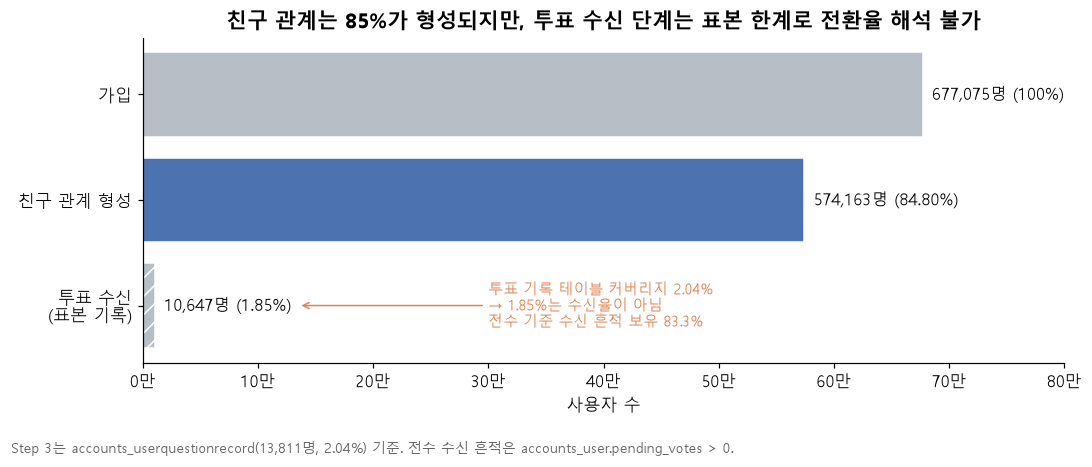

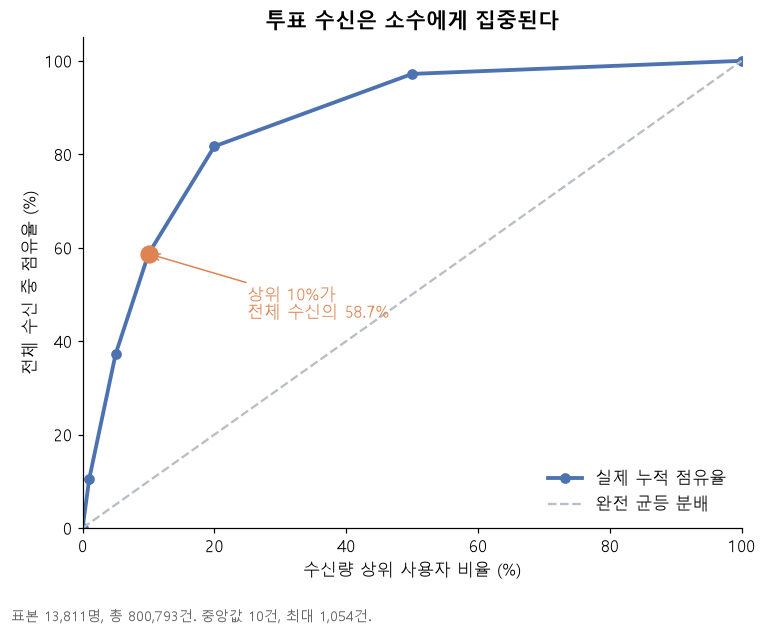

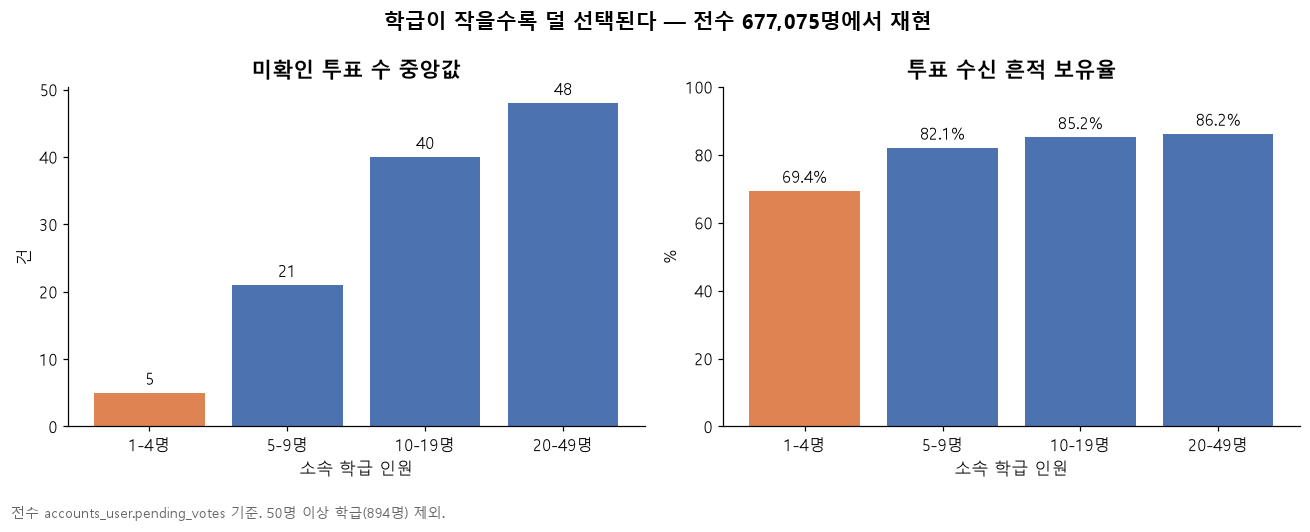

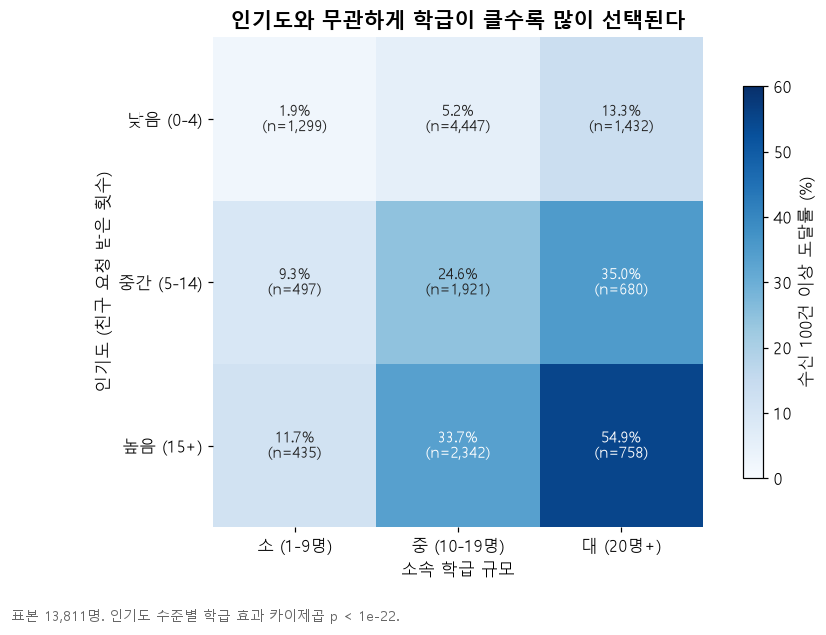

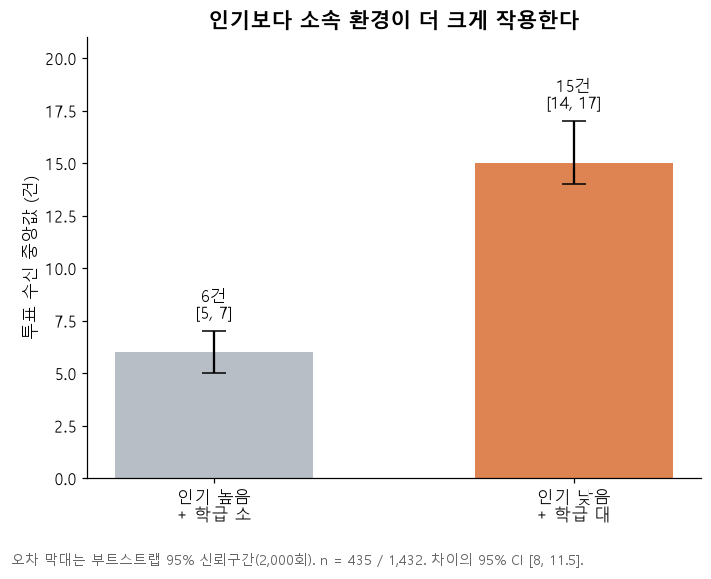

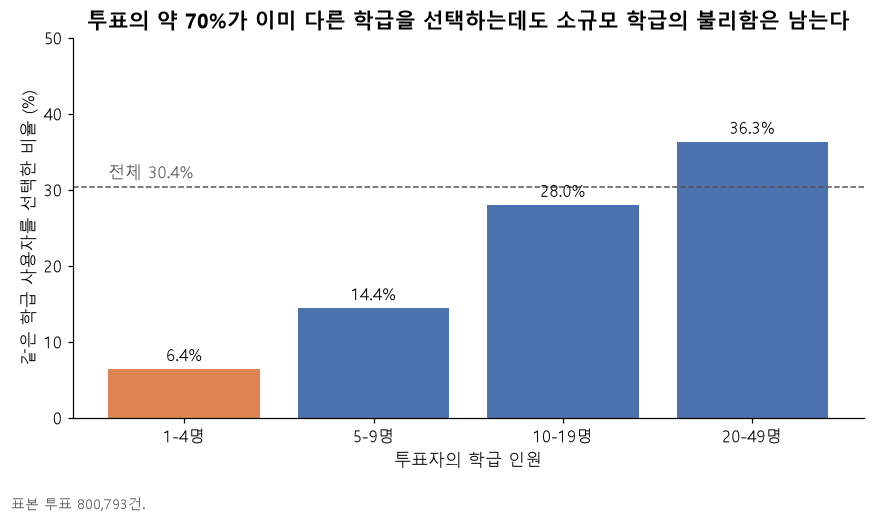

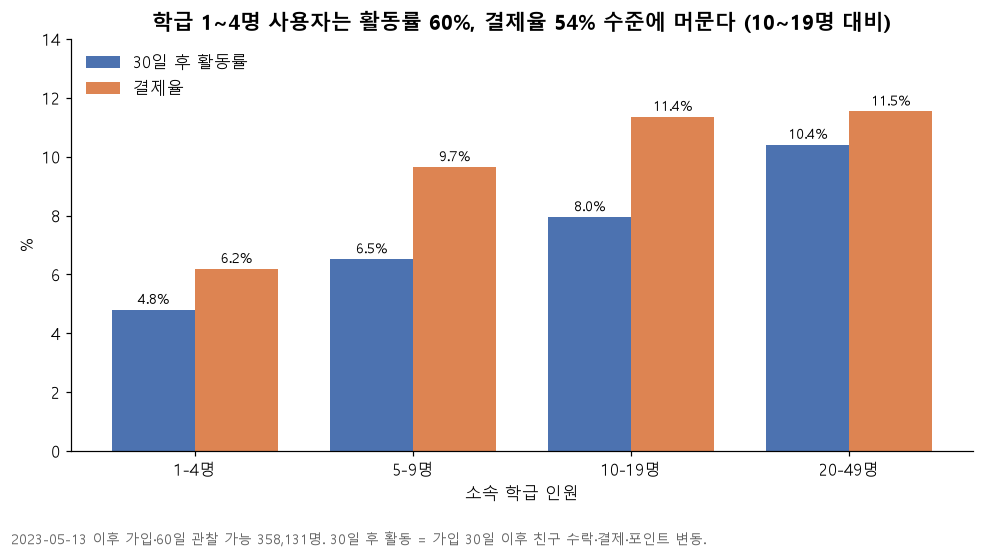

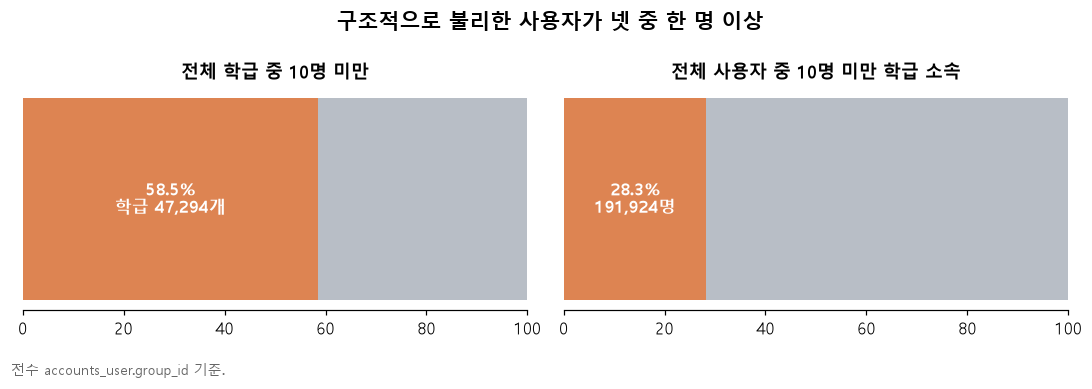

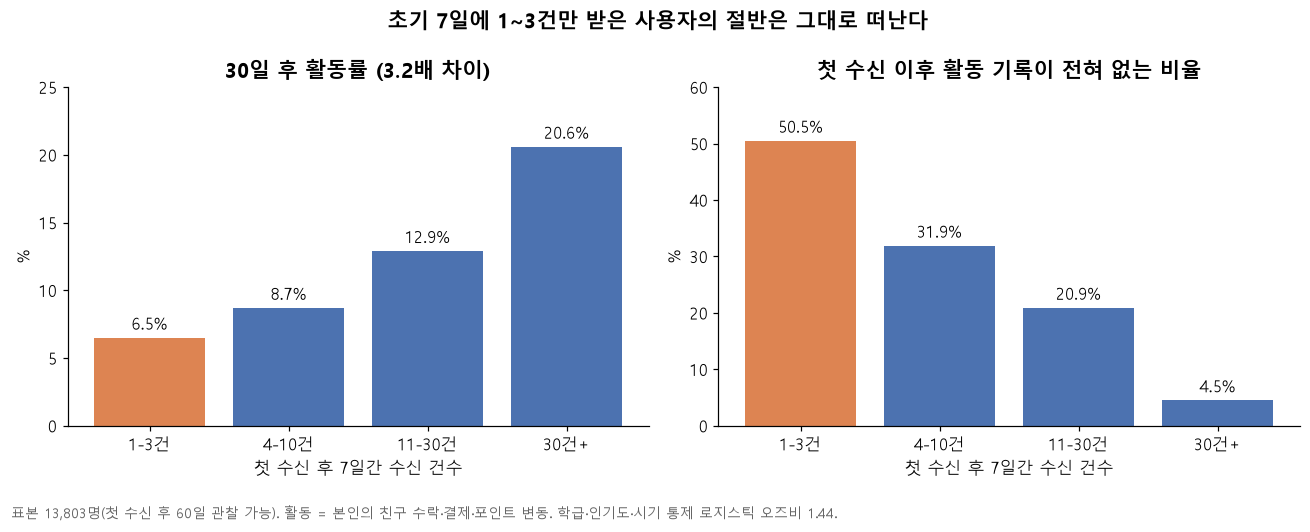

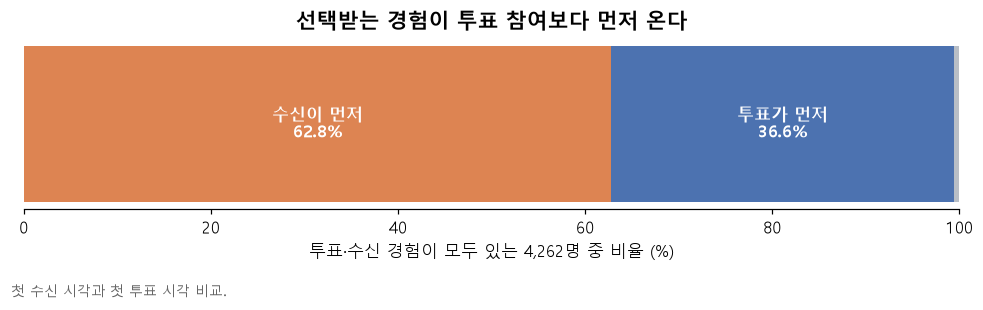

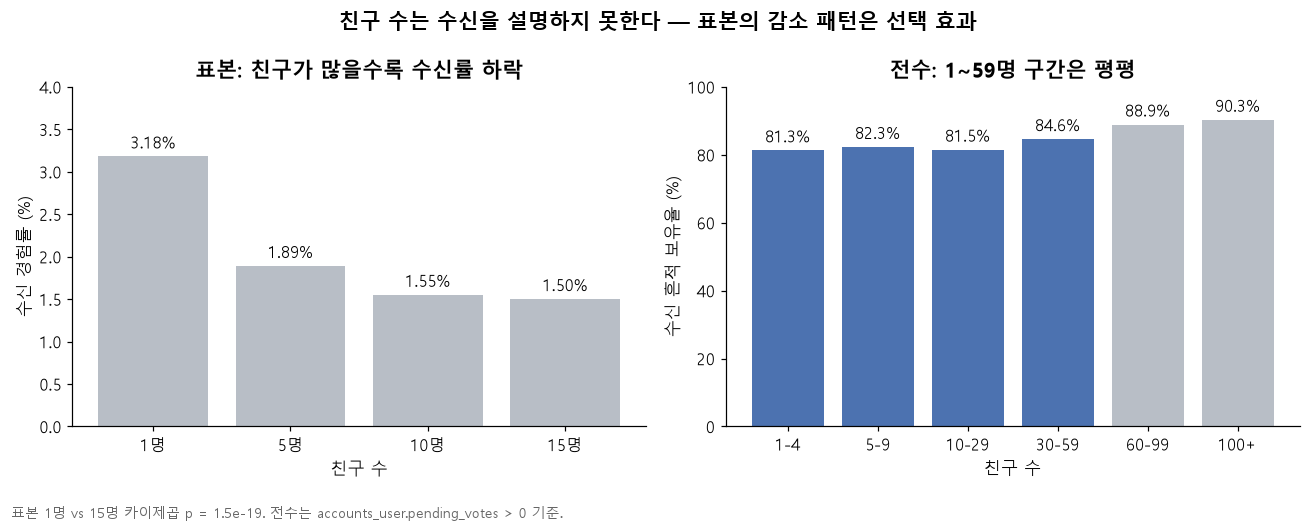

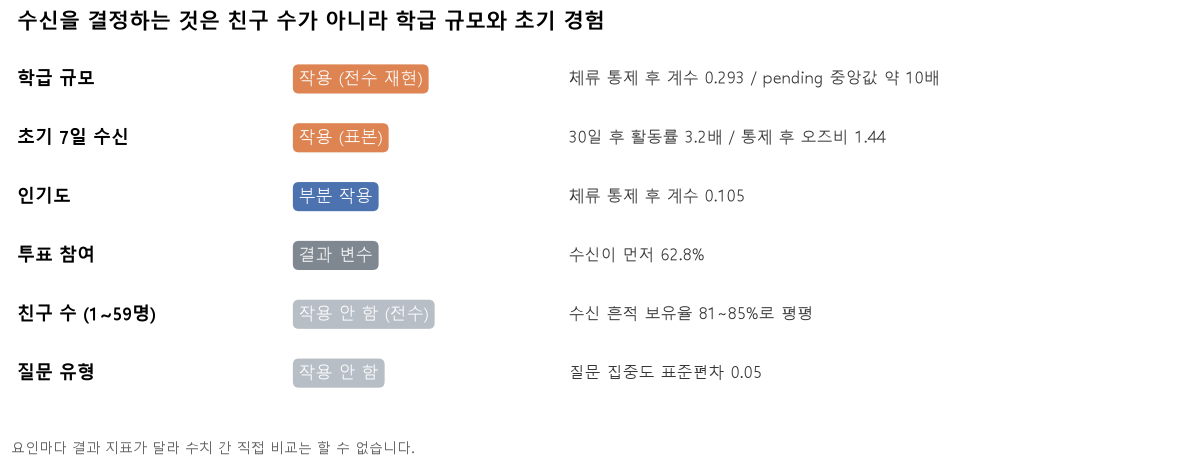

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_step2_3


In [31]:
# Step 2 → 3 종합 시각화
# 값은 최종 EDA 문서(step2_3_friend_to_vote.md)의 수치를 사용합니다.
# 노트북 재실행으로 수치가 바뀌면 각 셀 상단의 값만 수정하세요.
# VSCode에서 '# %%' 단위로 셀 실행이 가능합니다.

# %% 0. 설정
import platform
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    mpl.rcParams["font.family"] = "Noto Sans CJK KR"

mpl.rcParams.update({
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#4C72B0"     # 기본
ORANGE = "#DD8452"   # 강조 (핵심 인사이트)
GRAY = "#B8BEC6"     # 보조

OUT = Path("figures_step2_3")
OUT.mkdir(exist_ok=True)


def finish(fig, name, note=None):
    if note:
        fig.text(0.01, -0.02, note, fontsize=9, color="#666666", ha="left", va="top")
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


# %% 1. 퍼널과 데이터 함정 — 1.85%는 수신율이 아니다
steps = ["가입", "친구 관계 형성", "투표 수신\n(표본 기록)"]
vals = [677_075, 574_163, 10_647]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(steps, vals, color=[GRAY, BLUE, GRAY], hatch=["", "", "//"], edgecolor="white")
ax.invert_yaxis()
ax.set_xlim(0, 800_000)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f"{x/1e4:.0f}만"))
for b, v, t in zip(bars, vals, ["100%", "84.80%", "1.85%"]):
    ax.text(v + 8_000, b.get_y() + b.get_height() / 2, f"{v:,}명 ({t})", va="center")
ax.annotate("투표 기록 테이블 커버리지 2.04%\n→ 1.85%는 수신율이 아님\n전수 기준 수신 흔적 보유 83.3%",
            xy=(135_000, 2), xytext=(300_000, 2), va="center", color=ORANGE, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_title("친구 관계는 85%가 형성되지만, 투표 수신 단계는 표본 한계로 전환율 해석 불가")
ax.set_xlabel("사용자 수")
finish(fig, "01_funnel_coverage",
       "Step 3는 accounts_userquestionrecord(13,811명, 2.04%) 기준. 전수 수신 흔적은 accounts_user.pending_votes > 0.")


# %% 2. 수신 편중 — 상위 10%가 58.7%
x = [0, 1, 5, 10, 20, 50, 100]
y = [0, 10.5, 37.2, 58.7, 81.7, 97.2, 100]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(x, y, marker="o", color=BLUE, linewidth=2.5, label="실제 누적 점유율")
ax.plot([0, 100], [0, 100], linestyle="--", color=GRAY, label="완전 균등 분배")
ax.scatter([10], [58.7], s=120, color=ORANGE, zorder=5)
ax.annotate("상위 10%가\n전체 수신의 58.7%", xy=(10, 58.7), xytext=(25, 45),
            color=ORANGE, fontsize=11, arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
ax.set_xlabel("수신량 상위 사용자 비율 (%)")
ax.set_ylabel("전체 수신 중 점유율 (%)")
ax.set_title("투표 수신은 소수에게 집중된다")
ax.legend(loc="lower right", frameon=False)
finish(fig, "02_concentration_curve",
       "표본 13,811명, 총 800,793건. 중앙값 10건, 최대 1,054건.")


# %% 3. 학급 규모 효과 — 전수 재현
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
median_pending = [5, 21, 40, 48]
hold_rate = [69.4, 82.1, 85.2, 86.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [ORANGE, BLUE, BLUE, BLUE]

b = axes[0].bar(classes, median_pending, color=colors)
axes[0].bar_label(b, fmt="%d", padding=3)
axes[0].set_title("미확인 투표 수 중앙값")
axes[0].set_ylabel("건")
axes[0].set_xlabel("소속 학급 인원")

b = axes[1].bar(classes, hold_rate, color=colors)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("투표 수신 흔적 보유율")
axes[1].set_ylabel("%")
axes[1].set_xlabel("소속 학급 인원")

fig.suptitle("학급이 작을수록 덜 선택된다 — 전수 677,075명에서 재현", fontsize=14, fontweight="bold")
finish(fig, "03_class_size_full",
       "전수 accounts_user.pending_votes 기준. 50명 이상 학급(894명) 제외.")


# %% 4. 학급 × 인기도 히트맵 — 두 요인은 독립적이다
rate = np.array([
    [1.9, 5.2, 13.3],
    [9.3, 24.6, 35.0],
    [11.7, 33.7, 54.9],
])
n = np.array([
    [1299, 4447, 1432],
    [497, 1921, 680],
    [435, 2342, 758],
])
rows = ["낮음 (0-4)", "중간 (5-14)", "높음 (15+)"]
cols = ["소 (1-9명)", "중 (10-19명)", "대 (20명+)"]

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(rate, cmap="Blues", vmin=0, vmax=60)
ax.set_xticks(range(3), cols)
ax.set_yticks(range(3), rows)
ax.set_xlabel("소속 학급 규모")
ax.set_ylabel("인기도 (친구 요청 받은 횟수)")
for i in range(3):
    for j in range(3):
        c = "white" if rate[i, j] > 30 else "#222222"
        ax.text(j, i, f"{rate[i, j]:.1f}%\n(n={n[i, j]:,})", ha="center", va="center", color=c, fontsize=10)
ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("수신 100건 이상 도달률 (%)")
ax.set_title("인기도와 무관하게 학급이 클수록 많이 선택된다")
finish(fig, "04_heatmap_class_popularity",
       "표본 13,811명. 인기도 수준별 학급 효과 카이제곱 p < 1e-22.")


# %% 5. 핵심 대비 — 인기 높음+학급 소 < 인기 낮음+학급 대
labels = ["인기 높음\n+ 학급 소", "인기 낮음\n+ 학급 대"]
med = [6, 15]
ci_low = [5, 14]
ci_high = [7, 17]
yerr = [[m - l for m, l in zip(med, ci_low)], [h - m for m, h in zip(med, ci_high)]]

fig, ax = plt.subplots(figsize=(6.5, 5))
b = ax.bar(labels, med, color=[GRAY, ORANGE], yerr=yerr, capsize=8, width=0.55)
for rect, m, lo, hi in zip(b, med, ci_low, ci_high):
    ax.text(rect.get_x() + rect.get_width() / 2, hi + 0.6, f"{m}건\n[{lo}, {hi}]", ha="center")
ax.set_ylim(0, 21)
ax.set_ylabel("투표 수신 중앙값 (건)")
ax.set_title("인기보다 소속 환경이 더 크게 작용한다")
finish(fig, "05_key_contrast",
       "오차 막대는 부트스트랩 95% 신뢰구간(2,000회). n = 435 / 1,432. 차이의 95% CI [8, 11.5].")


# %% 6. 반 간 혼합 — 이미 70%가 다른 학급을 선택
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
same = [6.4, 14.4, 28.0, 36.3]

fig, ax = plt.subplots(figsize=(8, 4.5))
b = ax.bar(classes, same, color=[ORANGE, BLUE, BLUE, BLUE])
ax.bar_label(b, fmt="%.1f%%", padding=3)
ax.axhline(30.4, color="#555555", linestyle="--", linewidth=1)
ax.text(-0.4, 31.5, "전체 30.4%", ha="left", color="#555555")
ax.set_ylim(0, 50)
ax.set_xlabel("투표자의 학급 인원")
ax.set_ylabel("같은 학급 사용자를 선택한 비율 (%)")
ax.set_title("투표의 약 70%가 이미 다른 학급을 선택하는데도 소규모 학급의 불리함은 남는다")
finish(fig, "06_cross_class_votes", "표본 투표 800,793건.")


# %% 7. 소규모 학급 사용자의 활동과 결제
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
act30 = [4.80, 6.52, 7.95, 10.41]
pay = [6.19, 9.65, 11.36, 11.54]
xpos = np.arange(len(classes))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.8))
b1 = ax.bar(xpos - w / 2, act30, w, color=BLUE, label="30일 후 활동률")
b2 = ax.bar(xpos + w / 2, pay, w, color=ORANGE, label="결제율")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xticks(xpos, classes)
ax.set_ylim(0, 14)
ax.set_xlabel("소속 학급 인원")
ax.set_ylabel("%")
ax.legend(frameon=False)
ax.set_title("학급 1~4명 사용자는 활동률 60%, 결제율 54% 수준에 머문다 (10~19명 대비)")
finish(fig, "07_small_class_activity_payment",
       "2023-05-13 이후 가입·60일 관찰 가능 358,131명. 30일 후 활동 = 가입 30일 이후 친구 수락·결제·포인트 변동.")


# %% 8. 대상 규모 — 학급의 58.5%가 10명 미만
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (title, small, total_label) in zip(axes, [
    ("전체 학급 중 10명 미만", 58.5, "학급 47,294개"),
    ("전체 사용자 중 10명 미만 학급 소속", 28.3, "191,924명"),
]):
    ax.barh([0], [100], color=GRAY, height=0.5)
    ax.barh([0], [small], color=ORANGE, height=0.5)
    ax.text(small / 2, 0, f"{small}%\n{total_label}", ha="center", va="center", color="white", fontweight="bold")
    ax.set_xlim(0, 100); ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    ax.spines[["left"]].set_visible(False)
fig.suptitle("구조적으로 불리한 사용자가 넷 중 한 명 이상", fontsize=14, fontweight="bold")
finish(fig, "08_target_size", "전수 accounts_user.group_id 기준.")


# %% 9. 초기 7일 — 초기 수신이 잔존을 가른다
groups = ["1-3건", "4-10건", "11-30건", "30건+"]
act30 = [6.5, 8.7, 12.9, 20.6]
no_act = [50.5, 31.9, 20.9, 4.5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
b = axes[0].bar(groups, act30, color=[ORANGE, BLUE, BLUE, BLUE])
axes[0].bar_label(b, fmt="%.1f%%", padding=3)
axes[0].set_ylim(0, 25)
axes[0].set_title("30일 후 활동률 (3.2배 차이)")
axes[0].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[0].set_ylabel("%")

b = axes[1].bar(groups, no_act, color=[ORANGE, BLUE, BLUE, BLUE])
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 60)
axes[1].set_title("첫 수신 이후 활동 기록이 전혀 없는 비율")
axes[1].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[1].set_ylabel("%")

fig.suptitle("초기 7일에 1~3건만 받은 사용자의 절반은 그대로 떠난다", fontsize=14, fontweight="bold")
finish(fig, "09_first_7days",
       "표본 13,803명(첫 수신 후 60일 관찰 가능). 활동 = 본인의 친구 수락·결제·포인트 변동. "
       "학급·인기도·시기 통제 로지스틱 오즈비 1.44.")


# %% 10. 수신 → 투표 순서
labels = ["수신이 먼저", "투표가 먼저", "동시"]
share = [62.8, 36.6, 0.6]

fig, ax = plt.subplots(figsize=(9, 2.6))
left = 0
for lab, s, c in zip(labels, share, [ORANGE, BLUE, GRAY]):
    ax.barh([0], [s], left=left, color=c, height=0.5)
    if s > 5:
        ax.text(left + s / 2, 0, f"{lab}\n{s}%", ha="center", va="center", color="white", fontweight="bold")
    left += s
ax.set_xlim(0, 100); ax.set_yticks([])
ax.spines[["left"]].set_visible(False)
ax.set_xlabel("투표·수신 경험이 모두 있는 4,262명 중 비율 (%)")
ax.set_title("선택받는 경험이 투표 참여보다 먼저 온다")
finish(fig, "10_receive_before_vote", "첫 수신 시각과 첫 투표 시각 비교.")


# %% 11. 친구 수 — 표본의 역설은 전수에서 재현되지 않는다
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

f_sample = ["1명", "5명", "10명", "15명"]
r_sample = [3.18, 1.89, 1.55, 1.50]
b = axes[0].bar(f_sample, r_sample, color=GRAY)
axes[0].bar_label(b, fmt="%.2f%%", padding=3)
axes[0].set_ylim(0, 4)
axes[0].set_title("표본: 친구가 많을수록 수신률 하락")
axes[0].set_xlabel("친구 수")
axes[0].set_ylabel("수신 경험률 (%)")

f_full = ["1-4", "5-9", "10-29", "30-59", "60-99", "100+"]
h_full = [81.3, 82.3, 81.5, 84.6, 88.9, 90.3]
b = axes[1].bar(f_full, h_full, color=[BLUE] * 4 + [GRAY] * 2)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("전수: 1~59명 구간은 평평")
axes[1].set_xlabel("친구 수")
axes[1].set_ylabel("수신 흔적 보유율 (%)")

fig.suptitle("친구 수는 수신을 설명하지 못한다 — 표본의 감소 패턴은 선택 효과", fontsize=14, fontweight="bold")
finish(fig, "11_friend_count_sample_vs_full",
       "표본 1명 vs 15명 카이제곱 p = 1.5e-19. 전수는 accounts_user.pending_votes > 0 기준.")


# %% 12. 요인 요약 — 무엇이 작용하고 무엇이 작용하지 않는가
factors = ["학급 규모", "초기 7일 수신", "인기도", "투표 참여", "친구 수 (1~59명)", "질문 유형"]
verdict = ["작용 (전수 재현)", "작용 (표본)", "부분 작용", "결과 변수", "작용 안 함 (전수)", "작용 안 함"]
evidence = [
    "체류 통제 후 계수 0.293 / pending 중앙값 약 10배",
    "30일 후 활동률 3.2배 / 통제 후 오즈비 1.44",
    "체류 통제 후 계수 0.105",
    "수신이 먼저 62.8%",
    "수신 흔적 보유율 81~85%로 평평",
    "질문 집중도 표준편차 0.05",
]
def verdict_color(v):
    if v.startswith("작용 ("):
        return ORANGE
    if v.startswith("부분"):
        return BLUE
    if v.startswith("결과"):
        return "#7F8790"
    return GRAY


fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")
for i, (f, v, e) in enumerate(zip(factors, verdict, evidence)):
    y = len(factors) - i
    c = verdict_color(v)
    ax.text(0.00, y, f, fontsize=12, fontweight="bold", va="center")
    ax.text(0.24, y, v, fontsize=11, va="center", color="white",
            bbox=dict(boxstyle="round,pad=0.35", fc=c, ec="none"))
    ax.text(0.47, y, e, fontsize=10.5, va="center", color="#333333")
ax.set_xlim(0, 1); ax.set_ylim(0.3, len(factors) + 0.7)
ax.set_title("수신을 결정하는 것은 친구 수가 아니라 학급 규모와 초기 경험", loc="left")
finish(fig, "12_factor_summary", "요인마다 결과 지표가 달라 수치 간 직접 비교는 할 수 없습니다.")

print(f"저장 위치: {OUT.resolve()}")

In [32]:
from scipy import stats

# 퍼널과 동일하게 Step 2(친구 형성) 통과자로 제한
o2 = obs[obs.index.isin(step2)].copy()

# 보조: 학급 인원 4명 이상 (진입 조건의 근사치, 학교 조건은 확인 불가)
o2 = o2.join(prof.set_index('id')['학급인원'])
o3 = o2[o2['학급인원'] >= 4]

for name, d in [('전체 수신자', obs), ('Step 2 통과자', o2), ('Step 2 + 학급 4명 이상', o3)]:
    t = d.groupby('구간', observed=True).agg(
        인원=('초기7일', 'size'),
        무활동=('last_act', lambda x: round(x.isna().mean() * 100, 1)),
        활동률_30일후=('30일후활동', lambda x: round(x.mean() * 100, 1))
    )
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(d['구간'], d['30일후활동']))
    print(f"\n[{name}] N={len(d):,}  chi2={chi2:.1f}, p={p:.1e}")
    print(t)


[전체 수신자] N=13,803  chi2=443.9, p=7.0e-96
         인원   무활동  활동률_30일후
구간                         
1-3    5452  50.5       6.5
4-10   2808  31.9       8.7
11-30  2061  20.9      12.9
30+    3482   4.5      20.6

[Step 2 통과자] N=10,642  chi2=256.9, p=2.1e-55
         인원   무활동  활동률_30일후
구간                         
1-3    3933  33.5       8.7
4-10   1974  13.2      10.5
11-30  1491   7.0      14.8
30+    3244   2.2      21.2

[Step 2 + 학급 4명 이상] N=10,420  chi2=251.1, p=3.9e-54
         인원   무활동  활동률_30일후
구간                         
1-3    3811  33.3       8.7
4-10   1924  12.7      10.7
11-30  1462   6.6      15.0
30+    3223   2.2      21.3


In [33]:
import numpy as np
import statsmodels.api as sm

# 기대 효과 재계산
rate  = o2.groupby('구간', observed=True)['30일후활동'].mean()
share = o2['구간'].value_counts(normalize=True)
print(f"초기 1-3건 비중: {share['1-3']*100:.1f}%")
for tgt in ['4-10', '11-30']:
    print(f"→ {tgt}건 수준: 1만 명당 +{10000 * share['1-3'] * (rate[tgt] - rate['1-3']):.0f}명")

# 로지스틱 재추정 (Step 2 통과자)
lg2 = o2.join(prof.set_index('id')['친구_수신']).dropna(subset=['학급인원']).copy()
m_ = lg2['first_recv'].dt.to_period('M').astype(str)
lg2['시기'] = np.where(m_ <= '2023-05', '5월 이전', np.where(m_ == '2023-06', '6월', '7월 이후'))

cont = pd.DataFrame({
    'log_초기7일': np.log1p(lg2['초기7일']),
    'log_학급':    np.log1p(lg2['학급인원']),
    'log_인기':    np.log1p(lg2['친구_수신']),
})
Xc = (cont - cont.mean()) / cont.std()
X  = sm.add_constant(pd.concat([Xc, pd.get_dummies(lg2['시기'], drop_first=True, dtype=float)], axis=1))
res = sm.Logit(lg2['30일후활동'].astype(int), X).fit(disp=0, cov_type='HC3')
ci = np.exp(res.conf_int())
print(pd.DataFrame({'오즈비': np.exp(res.params), 'CI하한': ci[0], 'CI상한': ci[1], 'p값': res.pvalues})
      .drop('const').round(3))

초기 1-3건 비중: 37.0%
→ 4-10건 수준: 1만 명당 +65명
→ 11-30건 수준: 1만 명당 +223명
            오즈비   CI하한   CI상한     p값
log_초기7일  1.411  1.332  1.495  0.000
log_학급    1.286  1.196  1.383  0.000
log_인기    1.019  0.965  1.077  0.492
6월        0.572  0.395  0.828  0.003
7월 이후     0.293  0.108  0.798  0.016


In [34]:
from scipy import stats

# 1. 본인 제외 학급 인원 4명 이상 (= 학급 가입자 5명 이상)
o_cls = o2[o2['학급인원'] >= 5]

# 2. 실제 투표 경험자 (조건 충족이 확실한 집단)
voters = set(uqr['user_id'])
o_vote = o2[o2.index.isin(voters)]

# 3. 두 조건 모두
o_both = o_cls[o_cls.index.isin(voters)]

for name, d in [('Step 2 통과자 (현재 기준)', o2),
                ('+ 본인 제외 학급 4명 이상', o_cls),
                ('+ 실제 투표 경험자', o_vote),
                ('+ 두 조건 모두', o_both)]:
    t = d.groupby('구간', observed=True).agg(
        인원=('초기7일', 'size'),
        무활동=('last_act', lambda x: round(x.isna().mean() * 100, 1)),
        활동률_30일후=('30일후활동', lambda x: round(x.mean() * 100, 1))
    )
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(d['구간'], d['30일후활동']))
    print(f"\n[{name}] N={len(d):,}  chi2={chi2:.1f}, p={p:.1e}")
    print(t)


[Step 2 통과자 (현재 기준)] N=10,642  chi2=256.9, p=2.1e-55
         인원   무활동  활동률_30일후
구간                         
1-3    3933  33.5       8.7
4-10   1974  13.2      10.5
11-30  1491   7.0      14.8
30+    3244   2.2      21.2

[+ 본인 제외 학급 4명 이상] N=10,283  chi2=249.9, p=6.8e-54
         인원   무활동  활동률_30일후
구간                         
1-3    3737  33.1       8.7
4-10   1893  12.4      10.7
11-30  1442   6.6      15.1
30+    3211   2.1      21.3

[+ 실제 투표 경험자] N=3,522  chi2=10.6, p=1.4e-02
         인원   무활동  활동률_30일후
구간                         
1-3      82  26.8      24.4
4-10    190   9.5      24.7
11-30   476   4.0      30.3
30+    2774   0.9      23.3

[+ 두 조건 모두] N=3,487  chi2=11.3, p=1.0e-02
         인원   무활동  활동률_30일후
구간                         
1-3      78  26.9      24.4
4-10    185   8.6      24.9
11-30   468   3.8      30.6
30+    2756   0.9      23.3


In [35]:
from scipy import stats

voters = set(uqr['user_id'])
first_vote = uqr.groupby('user_id')['created_at'].min()

o = o2.copy()
o['투표경험'] = o.index.isin(voters)
o['첫투표'] = o.index.map(first_vote)

# 1. 비투표자 안에서 초기 7일 효과 (역산값 검증)
nv = o[~o['투표경험']]
print(f"[비투표자] N={len(nv):,}")
print(nv.groupby('구간', observed=True).agg(
    인원=('초기7일', 'size'),
    활동률_30일후=('30일후활동', lambda x: round(x.mean() * 100, 1))
))
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(nv['구간'], nv['30일후활동']))
print(f"chi2={chi2:.1f}, p={p:.2e}")

# 2. 매개 확인: 첫 수신 시점까지 투표한 적 없던 사람이
#    초기 수신량에 따라 7일 이후 투표를 시작하는가
#    (7일 안에 투표를 시작한 사람은 수신과 투표가 동시에 섞이므로 제외)
pre = o[o['첫투표'].isna() | (o['첫투표'] > o['first_recv'])].copy()
pre = pre[pre['첫투표'].isna() | (pre['첫투표'] > pre['first_recv'] + pd.Timedelta(days=7))]
pre['이후투표시작'] = pre['첫투표'].notna()

print(f"\n[첫 수신 전 투표 경험 없음, 7일 내 투표 시작자 제외] N={len(pre):,}")
print(pre.groupby('구간', observed=True).agg(
    인원=('초기7일', 'size'),
    투표시작률=('이후투표시작', lambda x: round(x.mean() * 100, 2))
))
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(pre['구간'], pre['이후투표시작']))
print(f"chi2={chi2:.1f}, p={p:.2e}")

[비투표자] N=7,120
         인원  활동률_30일후
구간                   
1-3    3851       8.4
4-10   1784       9.0
11-30  1015       7.5
30+     470       8.9
chi2=2.0, p=5.73e-01

[첫 수신 전 투표 경험 없음, 7일 내 투표 시작자 제외] N=7,222
         인원  투표시작률
구간                
1-3    3861   0.26
4-10   1814   1.65
11-30  1052   3.52
30+     495   5.05
chi2=118.2, p=1.91e-25


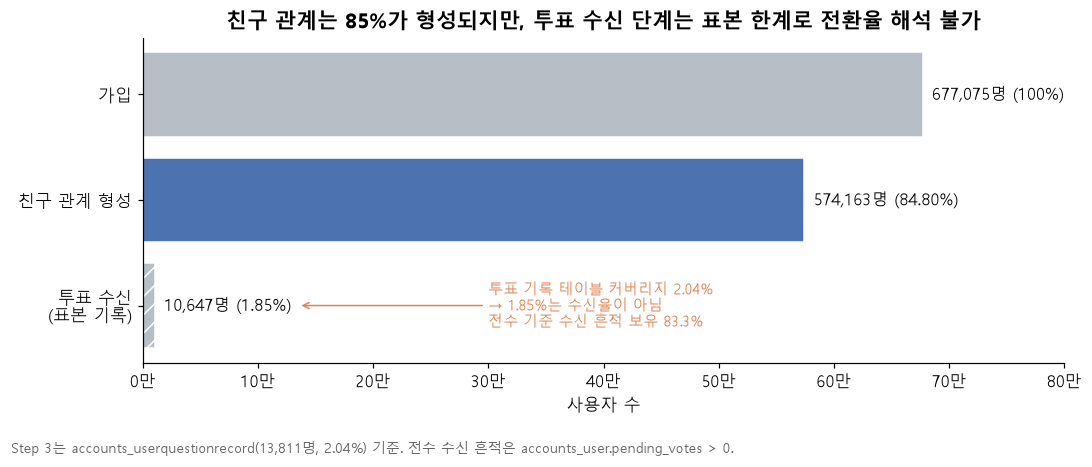

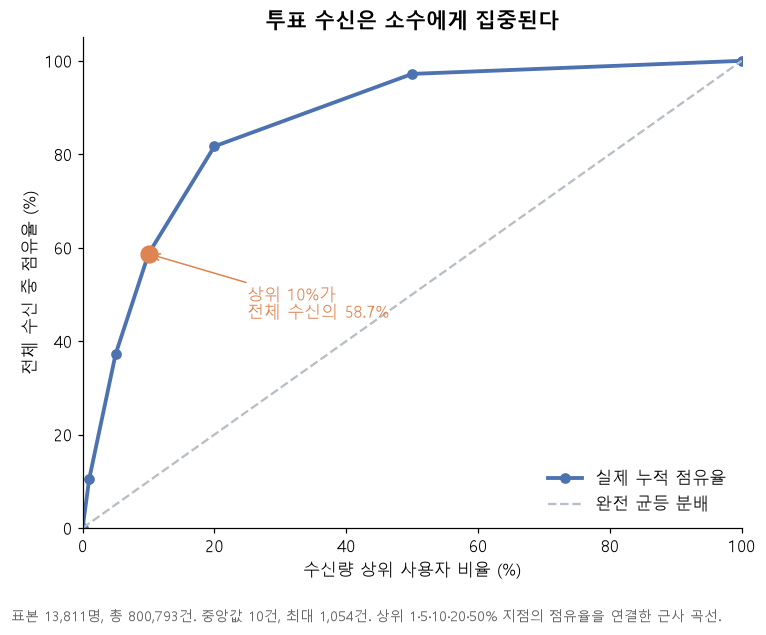

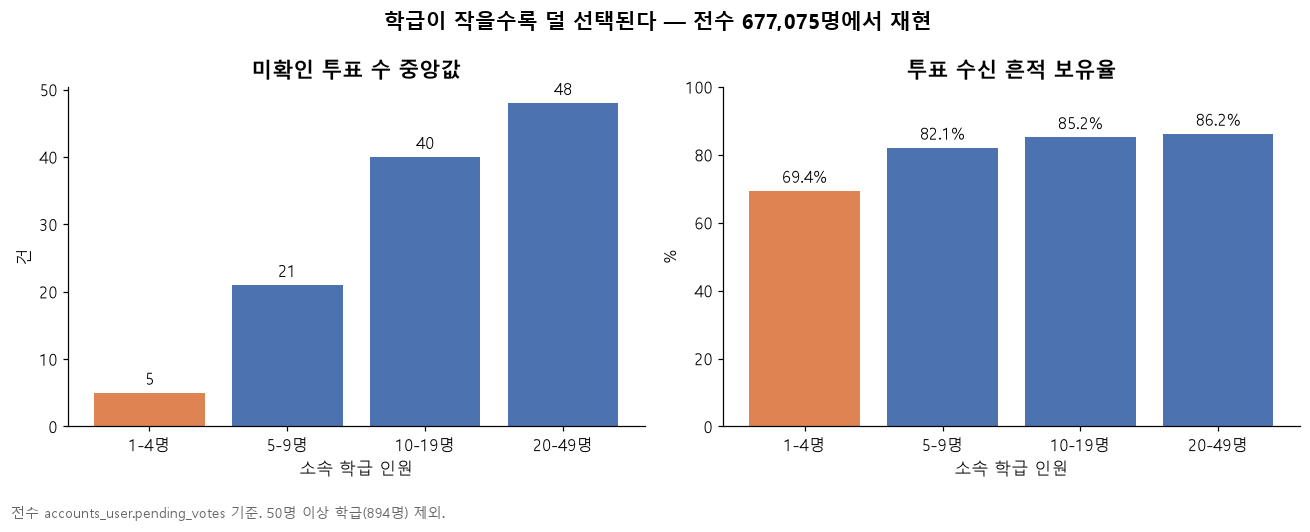

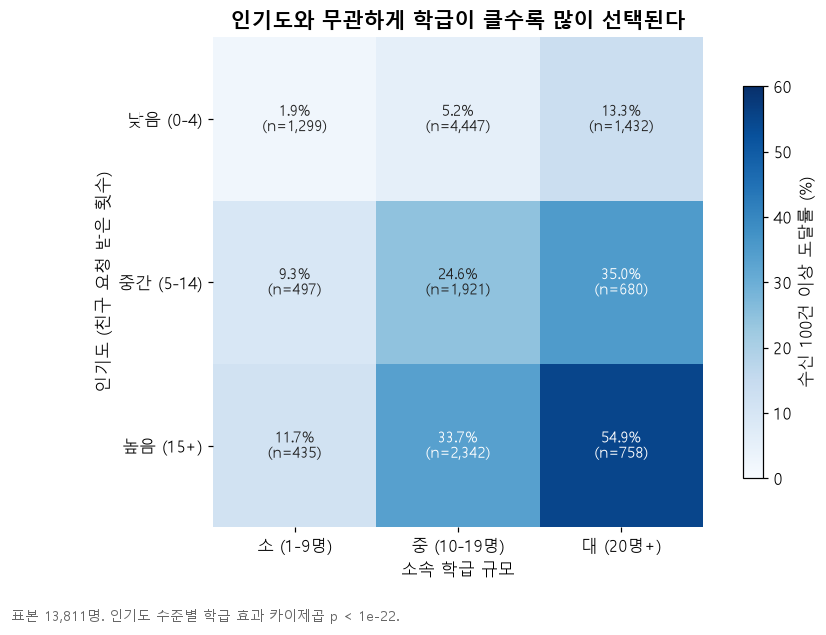

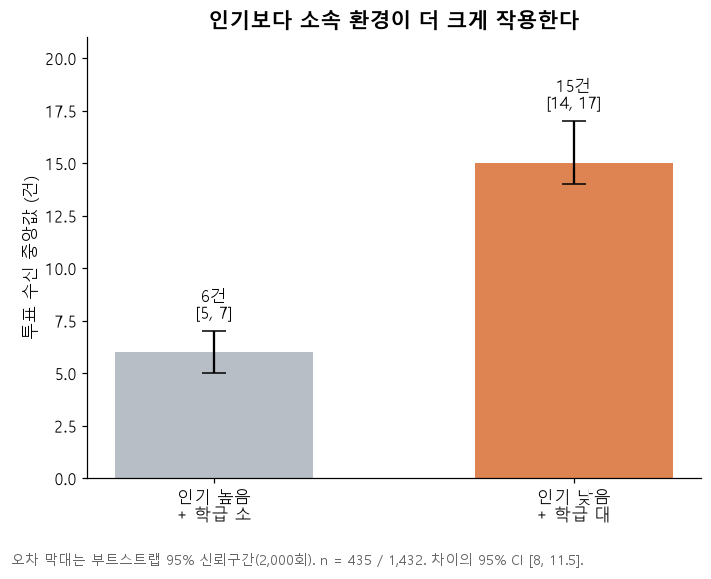

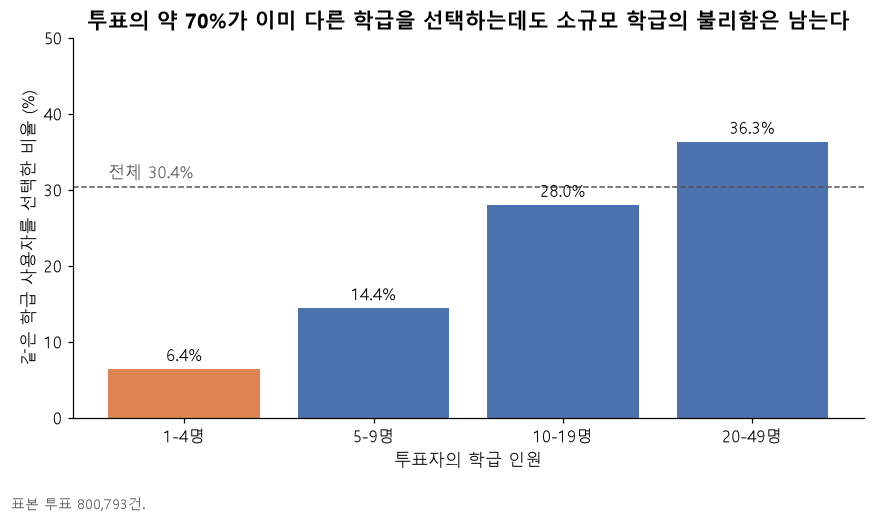

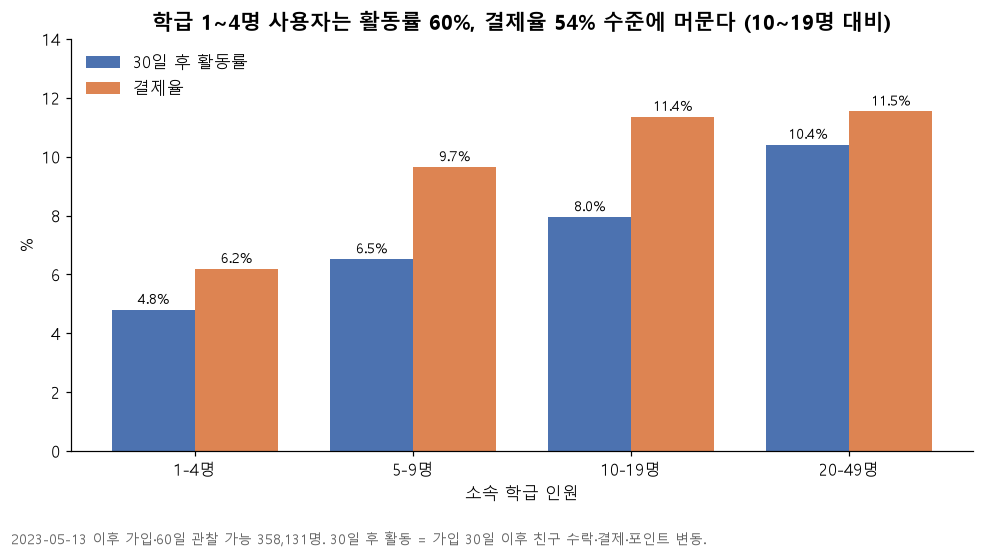

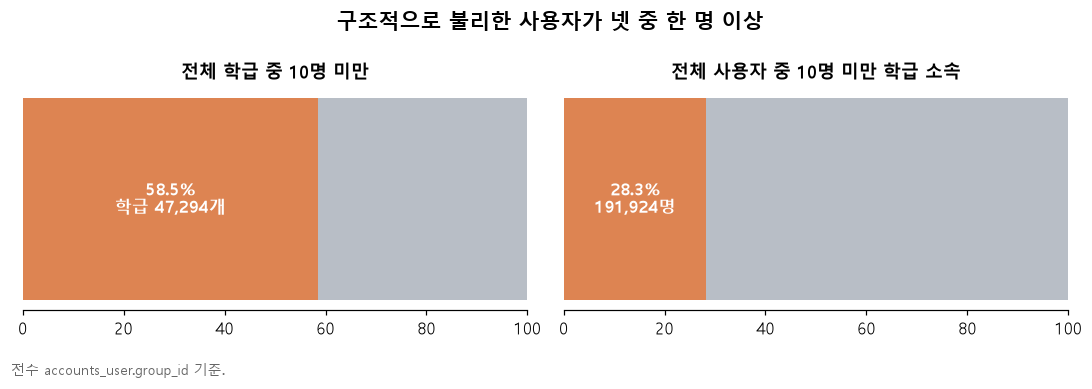

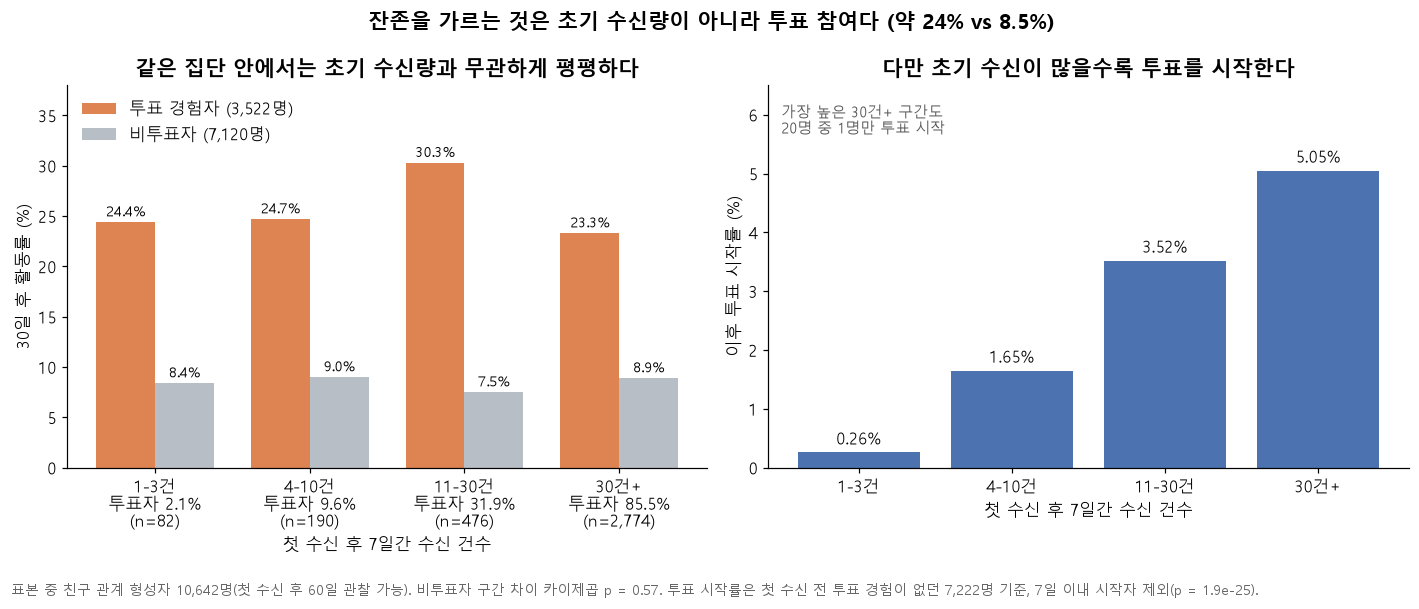

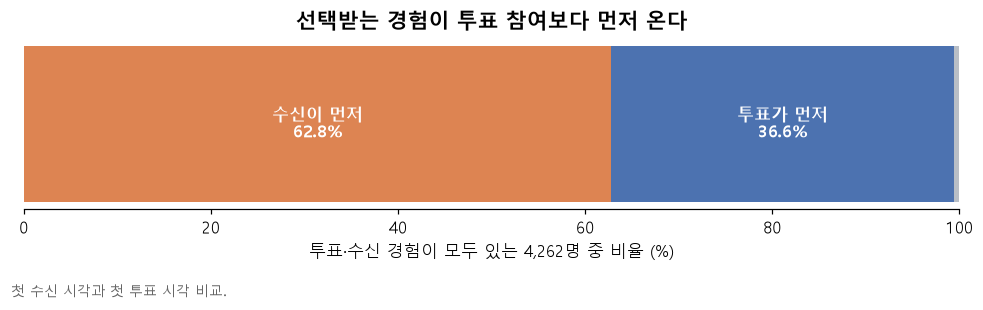

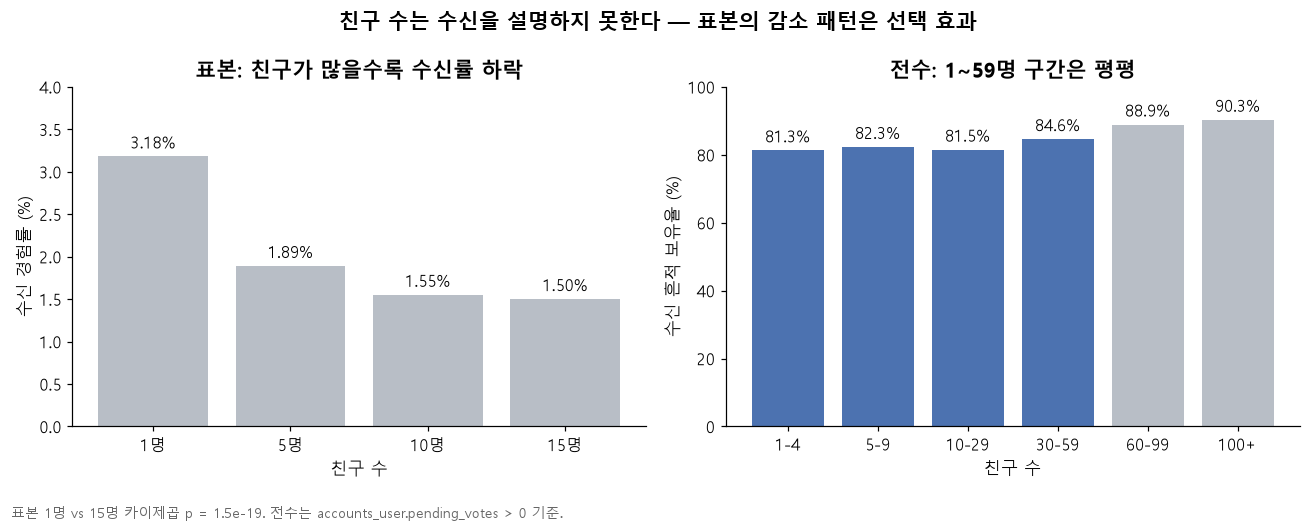

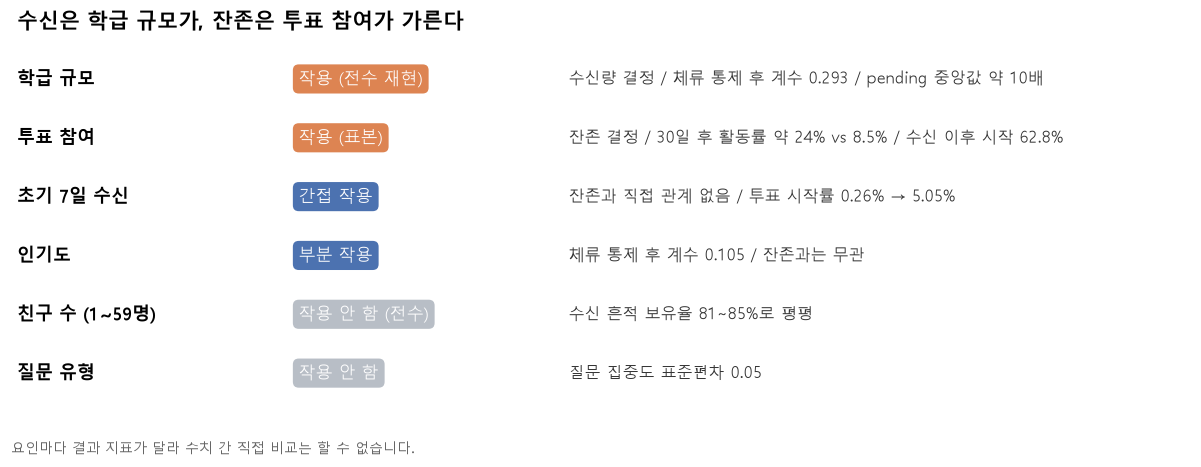

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_step2_3


In [36]:
# Step 2 → 3 종합 시각화
# 값은 최종 EDA 문서(step2_3_friend_to_vote.md)의 수치를 사용합니다.
# 노트북 재실행으로 수치가 바뀌면 각 셀 상단의 값만 수정하세요.
# VSCode에서 '# %%' 단위로 셀 실행이 가능합니다.

# %% 0. 설정
import platform
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    mpl.rcParams["font.family"] = "Noto Sans CJK KR"

mpl.rcParams.update({
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#4C72B0"     # 기본
ORANGE = "#DD8452"   # 강조 (핵심 인사이트)
GRAY = "#B8BEC6"     # 보조

OUT = Path("figures_step2_3")
OUT.mkdir(exist_ok=True)


def finish(fig, name, note=None):
    if note:
        fig.text(0.01, -0.02, note, fontsize=9, color="#666666", ha="left", va="top")
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


# %% 1. 퍼널과 데이터 함정 — 1.85%는 수신율이 아니다
steps = ["가입", "친구 관계 형성", "투표 수신\n(표본 기록)"]
vals = [677_075, 574_163, 10_647]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(steps, vals, color=[GRAY, BLUE, GRAY], hatch=["", "", "//"], edgecolor="white")
ax.invert_yaxis()
ax.set_xlim(0, 800_000)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f"{x/1e4:.0f}만"))
for b, v, t in zip(bars, vals, ["100%", "84.80%", "1.85%"]):
    ax.text(v + 8_000, b.get_y() + b.get_height() / 2, f"{v:,}명 ({t})", va="center")
ax.annotate("투표 기록 테이블 커버리지 2.04%\n→ 1.85%는 수신율이 아님\n전수 기준 수신 흔적 보유 83.3%",
            xy=(135_000, 2), xytext=(300_000, 2), va="center", color=ORANGE, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_title("친구 관계는 85%가 형성되지만, 투표 수신 단계는 표본 한계로 전환율 해석 불가")
ax.set_xlabel("사용자 수")
finish(fig, "01_funnel_coverage",
       "Step 3는 accounts_userquestionrecord(13,811명, 2.04%) 기준. 전수 수신 흔적은 accounts_user.pending_votes > 0.")


# %% 2. 수신 편중 — 상위 10%가 58.7%
x = [0, 1, 5, 10, 20, 50, 100]
y = [0, 10.5, 37.2, 58.7, 81.7, 97.2, 100]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(x, y, marker="o", color=BLUE, linewidth=2.5, label="실제 누적 점유율")
ax.plot([0, 100], [0, 100], linestyle="--", color=GRAY, label="완전 균등 분배")
ax.scatter([10], [58.7], s=120, color=ORANGE, zorder=5)
ax.annotate("상위 10%가\n전체 수신의 58.7%", xy=(10, 58.7), xytext=(25, 45),
            color=ORANGE, fontsize=11, arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
ax.set_xlabel("수신량 상위 사용자 비율 (%)")
ax.set_ylabel("전체 수신 중 점유율 (%)")
ax.set_title("투표 수신은 소수에게 집중된다")
ax.legend(loc="lower right", frameon=False)
finish(fig, "02_concentration_curve",
       "표본 13,811명, 총 800,793건. 중앙값 10건, 최대 1,054건. 상위 1·5·10·20·50% 지점의 점유율을 연결한 근사 곡선.")


# %% 3. 학급 규모 효과 — 전수 재현
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
median_pending = [5, 21, 40, 48]
hold_rate = [69.4, 82.1, 85.2, 86.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [ORANGE, BLUE, BLUE, BLUE]

b = axes[0].bar(classes, median_pending, color=colors)
axes[0].bar_label(b, fmt="%d", padding=3)
axes[0].set_title("미확인 투표 수 중앙값")
axes[0].set_ylabel("건")
axes[0].set_xlabel("소속 학급 인원")

b = axes[1].bar(classes, hold_rate, color=colors)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("투표 수신 흔적 보유율")
axes[1].set_ylabel("%")
axes[1].set_xlabel("소속 학급 인원")

fig.suptitle("학급이 작을수록 덜 선택된다 — 전수 677,075명에서 재현", fontsize=14, fontweight="bold")
finish(fig, "03_class_size_full",
       "전수 accounts_user.pending_votes 기준. 50명 이상 학급(894명) 제외.")


# %% 4. 학급 × 인기도 히트맵 — 두 요인은 독립적이다
rate = np.array([
    [1.9, 5.2, 13.3],
    [9.3, 24.6, 35.0],
    [11.7, 33.7, 54.9],
])
n = np.array([
    [1299, 4447, 1432],
    [497, 1921, 680],
    [435, 2342, 758],
])
rows = ["낮음 (0-4)", "중간 (5-14)", "높음 (15+)"]
cols = ["소 (1-9명)", "중 (10-19명)", "대 (20명+)"]

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(rate, cmap="Blues", vmin=0, vmax=60)
ax.set_xticks(range(3), cols)
ax.set_yticks(range(3), rows)
ax.set_xlabel("소속 학급 규모")
ax.set_ylabel("인기도 (친구 요청 받은 횟수)")
for i in range(3):
    for j in range(3):
        c = "white" if rate[i, j] > 30 else "#222222"
        ax.text(j, i, f"{rate[i, j]:.1f}%\n(n={n[i, j]:,})", ha="center", va="center", color=c, fontsize=10)
ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("수신 100건 이상 도달률 (%)")
ax.set_title("인기도와 무관하게 학급이 클수록 많이 선택된다")
finish(fig, "04_heatmap_class_popularity",
       "표본 13,811명. 인기도 수준별 학급 효과 카이제곱 p < 1e-22.")


# %% 5. 핵심 대비 — 인기 높음+학급 소 < 인기 낮음+학급 대
labels = ["인기 높음\n+ 학급 소", "인기 낮음\n+ 학급 대"]
med = [6, 15]
ci_low = [5, 14]
ci_high = [7, 17]
yerr = [[m - l for m, l in zip(med, ci_low)], [h - m for m, h in zip(med, ci_high)]]

fig, ax = plt.subplots(figsize=(6.5, 5))
b = ax.bar(labels, med, color=[GRAY, ORANGE], yerr=yerr, capsize=8, width=0.55)
for rect, m, lo, hi in zip(b, med, ci_low, ci_high):
    ax.text(rect.get_x() + rect.get_width() / 2, hi + 0.6, f"{m}건\n[{lo}, {hi}]", ha="center")
ax.set_ylim(0, 21)
ax.set_ylabel("투표 수신 중앙값 (건)")
ax.set_title("인기보다 소속 환경이 더 크게 작용한다")
finish(fig, "05_key_contrast",
       "오차 막대는 부트스트랩 95% 신뢰구간(2,000회). n = 435 / 1,432. 차이의 95% CI [8, 11.5].")


# %% 6. 반 간 혼합 — 이미 70%가 다른 학급을 선택
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
same = [6.4, 14.4, 28.0, 36.3]

fig, ax = plt.subplots(figsize=(8, 4.5))
b = ax.bar(classes, same, color=[ORANGE, BLUE, BLUE, BLUE])
ax.bar_label(b, fmt="%.1f%%", padding=3)
ax.axhline(30.4, color="#555555", linestyle="--", linewidth=1)
ax.text(-0.4, 31.5, "전체 30.4%", ha="left", color="#555555")
ax.set_ylim(0, 50)
ax.set_xlabel("투표자의 학급 인원")
ax.set_ylabel("같은 학급 사용자를 선택한 비율 (%)")
ax.set_title("투표의 약 70%가 이미 다른 학급을 선택하는데도 소규모 학급의 불리함은 남는다")
finish(fig, "06_cross_class_votes", "표본 투표 800,793건.")


# %% 7. 소규모 학급 사용자의 활동과 결제
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
act30 = [4.80, 6.52, 7.95, 10.41]
pay = [6.19, 9.65, 11.36, 11.54]
xpos = np.arange(len(classes))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.8))
b1 = ax.bar(xpos - w / 2, act30, w, color=BLUE, label="30일 후 활동률")
b2 = ax.bar(xpos + w / 2, pay, w, color=ORANGE, label="결제율")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xticks(xpos, classes)
ax.set_ylim(0, 14)
ax.set_xlabel("소속 학급 인원")
ax.set_ylabel("%")
ax.legend(frameon=False)
ax.set_title("학급 1~4명 사용자는 활동률 60%, 결제율 54% 수준에 머문다 (10~19명 대비)")
finish(fig, "07_small_class_activity_payment",
       "2023-05-13 이후 가입·60일 관찰 가능 358,131명. 30일 후 활동 = 가입 30일 이후 친구 수락·결제·포인트 변동.")


# %% 8. 대상 규모 — 학급의 58.5%가 10명 미만
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (title, small, total_label) in zip(axes, [
    ("전체 학급 중 10명 미만", 58.5, "학급 47,294개"),
    ("전체 사용자 중 10명 미만 학급 소속", 28.3, "191,924명"),
]):
    ax.barh([0], [100], color=GRAY, height=0.5)
    ax.barh([0], [small], color=ORANGE, height=0.5)
    ax.text(small / 2, 0, f"{small}%\n{total_label}", ha="center", va="center", color="white", fontweight="bold")
    ax.set_xlim(0, 100); ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    ax.spines[["left"]].set_visible(False)
fig.suptitle("구조적으로 불리한 사용자가 넷 중 한 명 이상", fontsize=14, fontweight="bold")
finish(fig, "08_target_size", "전수 accounts_user.group_id 기준.")


# %% 9. 잔존을 가르는 것은 초기 수신량이 아니라 투표 참여
groups = ["1-3건", "4-10건", "11-30건", "30건+"]
act_voter = [24.4, 24.7, 30.3, 23.3]      # 투표 경험자
act_nonvoter = [8.4, 9.0, 7.5, 8.9]       # 비투표자
voter_share = [2.1, 9.6, 31.9, 85.5]      # 구간 내 투표 경험자 비율
voter_n = [82, 190, 476, 2774]            # 구간 내 투표 경험자 수
vote_start = [0.26, 1.65, 3.52, 5.05]     # 첫 수신 전 투표 경험 없던 사람의 이후 투표 시작률

xpos = np.arange(len(groups))
w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# 왼쪽: 집단별 30일 후 활동률
b1 = axes[0].bar(xpos - w / 2, act_voter, w, color=ORANGE, label="투표 경험자 (3,522명)")
b2 = axes[0].bar(xpos + w / 2, act_nonvoter, w, color=GRAY, label="비투표자 (7,120명)")
axes[0].bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
axes[0].bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
axes[0].set_xticks(xpos, [f"{g}\n투표자 {s}%\n(n={n:,})"
                          for g, s, n in zip(groups, voter_share, voter_n)])
axes[0].set_ylim(0, 38)
axes[0].set_ylabel("30일 후 활동률 (%)")
axes[0].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[0].legend(frameon=False, loc="upper left")
axes[0].set_title("같은 집단 안에서는 초기 수신량과 무관하게 평평하다")

# 오른쪽: 이후 투표 시작률 (왼쪽 색 의미와 겹치지 않도록 단색)
b = axes[1].bar(groups, vote_start, color=BLUE)
axes[1].bar_label(b, fmt="%.2f%%", padding=3)
axes[1].set_ylim(0, 6.5)
axes[1].set_ylabel("이후 투표 시작률 (%)")
axes[1].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[1].set_title("다만 초기 수신이 많을수록 투표를 시작한다")
axes[1].text(0.02, 0.95, "가장 높은 30건+ 구간도\n20명 중 1명만 투표 시작",
             transform=axes[1].transAxes, va="top", fontsize=10, color="#555555")

fig.suptitle("잔존을 가르는 것은 초기 수신량이 아니라 투표 참여다 (약 24% vs 8.5%)",
             fontsize=14, fontweight="bold")
finish(fig, "09_voting_drives_retention",
       "표본 중 친구 관계 형성자 10,642명(첫 수신 후 60일 관찰 가능). 비투표자 구간 차이 카이제곱 p = 0.57. "
       "투표 시작률은 첫 수신 전 투표 경험이 없던 7,222명 기준, 7일 이내 시작자 제외(p = 1.9e-25).")


# %% 10. 수신 → 투표 순서
labels = ["수신이 먼저", "투표가 먼저", "동시"]
share = [62.8, 36.6, 0.6]

fig, ax = plt.subplots(figsize=(9, 2.6))
left = 0
for lab, s, c in zip(labels, share, [ORANGE, BLUE, GRAY]):
    ax.barh([0], [s], left=left, color=c, height=0.5)
    if s > 5:
        ax.text(left + s / 2, 0, f"{lab}\n{s}%", ha="center", va="center", color="white", fontweight="bold")
    left += s
ax.set_xlim(0, 100); ax.set_yticks([])
ax.spines[["left"]].set_visible(False)
ax.set_xlabel("투표·수신 경험이 모두 있는 4,262명 중 비율 (%)")
ax.set_title("선택받는 경험이 투표 참여보다 먼저 온다")
finish(fig, "10_receive_before_vote", "첫 수신 시각과 첫 투표 시각 비교.")


# %% 11. 친구 수 — 표본의 역설은 전수에서 재현되지 않는다
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

f_sample = ["1명", "5명", "10명", "15명"]
r_sample = [3.18, 1.89, 1.55, 1.50]
b = axes[0].bar(f_sample, r_sample, color=GRAY)
axes[0].bar_label(b, fmt="%.2f%%", padding=3)
axes[0].set_ylim(0, 4)
axes[0].set_title("표본: 친구가 많을수록 수신률 하락")
axes[0].set_xlabel("친구 수")
axes[0].set_ylabel("수신 경험률 (%)")

f_full = ["1-4", "5-9", "10-29", "30-59", "60-99", "100+"]
h_full = [81.3, 82.3, 81.5, 84.6, 88.9, 90.3]
b = axes[1].bar(f_full, h_full, color=[BLUE] * 4 + [GRAY] * 2)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("전수: 1~59명 구간은 평평")
axes[1].set_xlabel("친구 수")
axes[1].set_ylabel("수신 흔적 보유율 (%)")

fig.suptitle("친구 수는 수신을 설명하지 못한다 — 표본의 감소 패턴은 선택 효과", fontsize=14, fontweight="bold")
finish(fig, "11_friend_count_sample_vs_full",
       "표본 1명 vs 15명 카이제곱 p = 1.5e-19. 전수는 accounts_user.pending_votes > 0 기준.")


# %% 12. 요인 요약 — 무엇이 작용하고 무엇이 작용하지 않는가
factors = ["학급 규모", "투표 참여", "초기 7일 수신", "인기도", "친구 수 (1~59명)", "질문 유형"]
verdict = ["작용 (전수 재현)", "작용 (표본)", "간접 작용", "부분 작용", "작용 안 함 (전수)", "작용 안 함"]
evidence = [
    "수신량 결정 / 체류 통제 후 계수 0.293 / pending 중앙값 약 10배",
    "잔존 결정 / 30일 후 활동률 약 24% vs 8.5% / 수신 이후 시작 62.8%",
    "잔존과 직접 관계 없음 / 투표 시작률 0.26% → 5.05%",
    "체류 통제 후 계수 0.105 / 잔존과는 무관",
    "수신 흔적 보유율 81~85%로 평평",
    "질문 집중도 표준편차 0.05",
]
def verdict_color(v):
    if v.startswith("작용 ("):
        return ORANGE
    if v.startswith("부분") or v.startswith("간접"):
        return BLUE
    if v.startswith("결과"):
        return "#7F8790"
    return GRAY


fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")
for i, (f, v, e) in enumerate(zip(factors, verdict, evidence)):
    y = len(factors) - i
    c = verdict_color(v)
    ax.text(0.00, y, f, fontsize=12, fontweight="bold", va="center")
    ax.text(0.24, y, v, fontsize=11, va="center", color="white",
            bbox=dict(boxstyle="round,pad=0.35", fc=c, ec="none"))
    ax.text(0.47, y, e, fontsize=10.5, va="center", color="#333333")
ax.set_xlim(0, 1); ax.set_ylim(0.3, len(factors) + 0.7)
ax.set_title("수신은 학급 규모가, 잔존은 투표 참여가 가른다", loc="left")
finish(fig, "12_factor_summary", "요인마다 결과 지표가 달라 수치 간 직접 비교는 할 수 없습니다.")

print(f"저장 위치: {OUT.resolve()}")

In [37]:
from scipy import stats

# 첫 수신 전 투표 경험이 없던 사용자 (7일 이내 시작자 제외)
pre = o[o['첫투표'].isna() | (o['첫투표'] > o['first_recv'] + pd.Timedelta(days=7))].copy()
pre['이후투표시작'] = pre['첫투표'].notna()
pre['학급인원'] = pre.index.map(g).map(grp_size)
pre = pre.dropna(subset=['학급인원'])

pre['학급구분'] = pd.cut(pre['학급인원'], [0, 9, 19, float('inf')],
                       labels=['소(1-9)', '중(10-19)', '대(20+)'])

print("=== 학급 규모 × 초기 7일 → 이후 투표 시작률(%) ===")
print(pre.pivot_table(index='학급구분', columns='구간', values='이후투표시작',
                      aggfunc=lambda x: round(x.mean() * 100, 2), observed=True))
print()
print("=== 인원 ===")
print(pre.pivot_table(index='학급구분', columns='구간', values='이후투표시작',
                      aggfunc='size', observed=True))

print()
for lv in ['소(1-9)', '중(10-19)', '대(20+)']:
    d = pre[pre['학급구분'] == lv]
    if d['이후투표시작'].sum() < 5:
        print(f"{lv}: 시작자 {d['이후투표시작'].sum()}명으로 검정 불가")
        continue
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(d['구간'], d['이후투표시작']))
    print(f"{lv}: N={len(d):,}, 시작자 {d['이후투표시작'].sum()}명, chi2={chi2:.1f}, p={p:.2e}")

=== 학급 규모 × 초기 7일 → 이후 투표 시작률(%) ===
구간         1-3  4-10  11-30    30+
학급구분                              
소(1-9)    0.12  0.88   0.00   1.41
중(10-19)  0.28  1.66   3.78   4.32
대(20+)    0.36  2.41   6.21  10.00

=== 인원 ===
구간         1-3  4-10  11-30  30+
학급구분                            
소(1-9)     845   339    187   71
중(10-19)  2460  1143    688  324
대(20+)     556   332    177  100

소(1-9): N=1,442, 시작자 5명, chi2=7.1, p=6.93e-02
중(10-19): N=4,615, 시작자 66명, chi2=69.5, p=5.53e-15
대(20+): N=1,165, 시작자 31명, chi2=40.9, p=6.95e-09


In [38]:
# 1) 학급 규모별 투표자-비투표자 잔존 차이
o['학급인원'] = o.index.map(g).map(grp_size)
o['학급구분'] = pd.cut(o['학급인원'], [0, 9, 19, float('inf')],
                     labels=['소(1-9)', '중(10-19)', '대(20+)'])

gap = o.dropna(subset=['학급구분']).groupby(['학급구분', '투표경험'], observed=True)['30일후활동'].mean().unstack() * 100
gap.columns = ['비투표자', '투표자']
gap['차이_%p'] = (gap['투표자'] - gap['비투표자']).round(1)
print("=== 학급 규모별 30일 후 활동률 (%) ===")
print(gap.round(1))

# 2) 학급 규모별 초기 1-3건 비중
share = (pre.groupby('학급구분', observed=True)['구간']
           .value_counts(normalize=True).unstack()['1-3'] * 100).round(1)
print("\n=== 초기 1-3건 비중 (%) ===")
print(share)

# 3) 기대 효과 재계산
rate = pre.pivot_table(index='학급구분', columns='구간', values='이후투표시작',
                       aggfunc='mean', observed=True) * 100

print("\n=== 첫 수신자 1만 명당 추가 잔존 (상한 추정) ===")
for lv in ['중(10-19)', '대(20+)']:
    for tgt in ['4-10', '11-30']:
        inc = rate.loc[lv, tgt] - rate.loc[lv, '1-3']          # 투표 시작률 증가분(%p)
        eff = 10000 * (share[lv] / 100) * (inc / 100) * (gap.loc[lv, '차이_%p'] / 100)
        print(f"{lv} → {tgt}건 수준: 시작률 +{inc:.2f}%p, 잔존 차이 {gap.loc[lv,'차이_%p']:.1f}%p "
              f"→ 1만 명당 +{eff:.0f}명")

# 참고: 대상 규모 (전수)
print("\n=== 학급 10명 이상 사용자 (전수) ===")
u = user.copy()
u['학급인원'] = u['group_id'].map(grp_size)
big = (u['학급인원'] >= 10).sum()
print(f"{big:,}명 ({big/len(u)*100:.1f}%)")

=== 학급 규모별 30일 후 활동률 (%) ===
          비투표자   투표자  차이_%p
학급구분                       
소(1-9)     7.3  18.7   11.4
중(10-19)   8.6  21.7   13.1
대(20+)     9.2  30.3   21.1

=== 초기 1-3건 비중 (%) ===
학급구분
소(1-9)      58.6
중(10-19)    53.3
대(20+)      47.7
Name: 1-3, dtype: float64

=== 첫 수신자 1만 명당 추가 잔존 (상한 추정) ===
중(10-19) → 4-10건 수준: 시작률 +1.38%p, 잔존 차이 13.1%p → 1만 명당 +10명
중(10-19) → 11-30건 수준: 시작률 +3.49%p, 잔존 차이 13.1%p → 1만 명당 +24명
대(20+) → 4-10건 수준: 시작률 +2.05%p, 잔존 차이 21.1%p → 1만 명당 +21명
대(20+) → 11-30건 수준: 시작률 +5.85%p, 잔존 차이 21.1%p → 1만 명당 +59명

=== 학급 10명 이상 사용자 (전수) ===
485,151명 (71.7%)


In [39]:
pay = pd.read_csv(DATA / "accounts_paymenthistory_preprocessed_2.csv")
pay['created_at'] = pd.to_datetime(pay['created_at'])
print(f"pay: {pay.shape}")

pay: (95137, 5)


In [40]:
# 1) 학급 규모별 투표자의 투표 횟수
vote_cnt = uqr['user_id'].value_counts()
ov = o[o['투표경험']].copy()
ov['투표횟수'] = ov.index.map(vote_cnt)

print("=== 학급 규모별 투표자의 투표 횟수 ===")
print(ov.groupby('학급구분', observed=True).agg(
    인원=('투표횟수', 'size'),
    투표중앙=('투표횟수', 'median'),
    활동률=('30일후활동', lambda x: round(x.mean() * 100, 1))
).round(1))

# 2) 포인트를 뺀 활동(친구 수락 + 결제)으로 재측정
act_np = pd.concat([
    fr_a[['receive_user_id', 'updated_at']].rename(columns={'receive_user_id': 'user_id', 'updated_at': 't'}),
    pay[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
])
act_np['first'] = act_np['user_id'].map(o['first_recv'])
act_np = act_np.dropna(subset=['first'])
late_np = set(act_np.loc[act_np['t'] > act_np['first'] + pd.Timedelta(days=30), 'user_id'])

o['활동_포인트제외'] = o.index.isin(late_np)

print("\n=== 포인트 제외 후 30일 활동률 (%) ===")
g2 = o.dropna(subset=['학급구분']).groupby(['학급구분', '투표경험'], observed=True)['활동_포인트제외'].mean().unstack() * 100
g2.columns = ['비투표자', '투표자']
g2['차이_%p'] = (g2['투표자'] - g2['비투표자']).round(1)
print(g2.round(1))

=== 학급 규모별 투표자의 투표 횟수 ===
            인원   투표중앙   활동률
학급구분                       
소(1-9)     203   94.0  18.7
중(10-19)  2161  149.0  21.7
대(20+)    1158  169.0  30.3

=== 포인트 제외 후 30일 활동률 (%) ===
          비투표자  투표자  차이_%p
학급구분                      
소(1-9)     7.3  8.4    1.1
중(10-19)   8.6  7.1   -1.5
대(20+)     8.8  9.8    1.0


In [41]:
o['결제여부'] = o.index.isin(set(pay['user_id']))

print("=== 투표 경험별 결제율 (%) ===")
print(o.dropna(subset=['학급구분']).groupby(['학급구분', '투표경험'], observed=True)
        .agg(인원=('결제여부', 'size'),
             결제율=('결제여부', lambda x: round(x.mean() * 100, 2))))

print("\n=== 포인트 제외 활동의 구성 ===")
fr_only = set(act_np.loc[(act_np['t'] > act_np['first'] + pd.Timedelta(days=30)) &
                         act_np['user_id'].isin(fr_a['receive_user_id']), 'user_id'])
pay_only = set(pay.loc[pay['user_id'].isin(o.index), 'user_id'])
print(f"30일 후 친구 수락만 있는 사용자: {len(fr_only):,}")
print(f"결제 경험자: {len(pay_only & set(o.index)):,}")

=== 투표 경험별 결제율 (%) ===
                  인원    결제율
학급구분     투표경험              
소(1-9)   False  1437   9.60
         True    203   4.93
중(10-19) False  4549   9.87
         True   2161  10.50
대(20+)   False  1134   8.29
         True   1158  10.62

=== 포인트 제외 활동의 구성 ===
30일 후 친구 수락만 있는 사용자: 875
결제 경험자: 1,041


In [42]:
# ============================================
# 재현성 검증 — 커널 재시작 후 이 셀만 실행
# ============================================
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parents[3]        # 노트북 위치에 따라 조정
sys.path.append(str(PROJECT_ROOT))
DATA = PROJECT_ROOT / "data" / "processed" / "preprocessed_data_2"

user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
uqr  = pd.read_csv(DATA / "accounts_userquestionrecord_preprocessed_2.csv")
pay  = pd.read_csv(DATA / "accounts_paymenthistory_preprocessed_2.csv")
ph   = pd.read_csv(DATA / "accounts_pointhistory_preprocessed_2.csv")
fr   = pd.read_csv(DATA / "accounts_friendrequest_preprocessed_2.csv",
                   usecols=['send_user_id', 'receive_user_id', 'status', 'updated_at'])

for df, col in [(uqr, 'created_at'), (pay, 'created_at'), (ph, 'created_at'), (fr, 'updated_at')]:
    df[col] = pd.to_datetime(df[col])

END = pd.Timestamp('2024-05-07 23:59:59')

# ── 기본 변수
fr_a = fr[fr['status'] == 'A']
friends  = pd.concat([fr_a['send_user_id'], fr_a['receive_user_id']]).value_counts()
grp_size = user.groupby('group_id').size()
g = user.set_index('id')['group_id']

step1 = set(user['id'])
step2 = set(friends.index) & step1
recv  = set(uqr['chosen_user_id'])
voters = set(uqr['user_id'])
paid  = set(pay['user_id'])

# ── 첫 수신 · 초기 7일 · 독립 활동
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()

t = uqr[['chosen_user_id', 'created_at']].copy()
t['first'] = t['chosen_user_id'].map(first_recv)
early = t[t['created_at'] <= t['first'] + pd.Timedelta(days=7)]['chosen_user_id'].value_counts()

act_all = pd.concat([
    fr_a[['receive_user_id', 'updated_at']].rename(columns={'receive_user_id': 'user_id', 'updated_at': 't'}),
    pay[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
    ph[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
])
act_np = pd.concat([                      # 포인트 제외
    fr_a[['receive_user_id', 'updated_at']].rename(columns={'receive_user_id': 'user_id', 'updated_at': 't'}),
    pay[['user_id', 'created_at']].rename(columns={'created_at': 't'}),
])

def late_set(act):
    a = act.copy()
    a['first'] = a['user_id'].map(first_recv)
    a = a.dropna(subset=['first'])
    return set(a.loc[a['t'] > a['first'] + pd.Timedelta(days=30), 'user_id'])

late_all, late_np = late_set(act_all), late_set(act_np)

o = pd.DataFrame({'first_recv': first_recv})
o['초기7일']  = early.reindex(o.index).fillna(0).astype(int)
o['관찰가능'] = (END - o['first_recv']).dt.days
o = o[(o['관찰가능'] >= 60) & (o.index.isin(step2))].copy()     # Step 2 통과 + 60일 관찰
o['30일후활동']   = o.index.isin(late_all)
o['활동_포인트제외'] = o.index.isin(late_np)
o['투표경험']     = o.index.isin(voters)
o['결제']        = o.index.isin(paid)
o['학급인원']     = o.index.map(g).map(grp_size)
o['구간']  = pd.cut(o['초기7일'], [0, 3, 10, 30, float('inf')], labels=['1-3', '4-10', '11-30', '30+'])
o['학급구분'] = pd.cut(o['학급인원'], [0, 9, 19, float('inf')], labels=['소(1-9)', '중(10-19)', '대(20+)'])

# ── 투표 시작률 (첫 수신 전 투표 경험 없음, 7일 이내 시작자 제외)
first_vote = uqr.groupby('user_id')['created_at'].min()
o['첫투표'] = o.index.map(first_vote)
pre = o[o['첫투표'].isna() | (o['첫투표'] > o['first_recv'] + pd.Timedelta(days=7))].copy()
pre['이후투표시작'] = pre['첫투표'].notna()


# ============================================
# 검증
# ============================================
def check(name, got, want, tol=0.05):
    ok = abs(got - want) <= tol * max(abs(want), 1)
    print(f"{'OK ' if ok else '!! '} {name:38s} {got:>12,.2f}  (문서 {want:,.2f})")

print("=" * 70)
print("기본 규모")
print("=" * 70)
check("Step 1 가입",            len(step1), 677075, 0)
check("Step 2 친구 형성",        len(step2), 574163, 0)
check("Step 2 비율(%)",          len(step2)/len(step1)*100, 84.80, 0.01)
check("투표 수신자(표본)",        len(recv), 13811, 0)
check("분석 대상(Step2·60일)",    len(o), 10642, 0.01)
check("투표 경험자",             o['투표경험'].sum(), 3522, 0.02)
check("비투표자",               (~o['투표경험']).sum(), 7120, 0.02)

print()
print("=" * 70)
print("1차 정정 — 구성 효과 (포인트 포함 활동률 %)")
print("=" * 70)
tab = o.groupby(['구간', '투표경험'], observed=True)['30일후활동'].mean().unstack() * 100
share = o.groupby('구간', observed=True)['투표경험'].mean() * 100
for lv, v_want, nv_want, s_want in [('1-3', 24.4, 8.4, 2.1), ('30+', 23.3, 8.9, 85.5)]:
    check(f"{lv} 투표자 활동률",   tab.loc[lv, True],  v_want, 0.05)
    check(f"{lv} 비투표자 활동률", tab.loc[lv, False], nv_want, 0.05)
    check(f"{lv} 투표자 비율",     share[lv],          s_want, 0.05)
chi2, p, _, _ = stats.chi2_contingency(
    pd.crosstab(o.loc[~o['투표경험'], '구간'], o.loc[~o['투표경험'], '30일후활동']))
print(f"{'OK ' if p > 0.05 else '!! '} 비투표자 구간차 p값                   {p:>12.3f}  (문서 0.57, 유의하지 않아야 함)")

print()
print("=" * 70)
print("2차 정정 — 측정 순환 (투표자 − 비투표자, %p)")
print("=" * 70)
for col, want in [('30일후활동', [11.4, 13.1, 21.1]), ('활동_포인트제외', [1.1, -1.5, 1.0])]:
    t2 = o.dropna(subset=['학급구분']).groupby(['학급구분', '투표경험'], observed=True)[col].mean().unstack() * 100
    label = "포인트 포함" if col == '30일후활동' else "포인트 제외"
    for lv, w in zip(['소(1-9)', '중(10-19)', '대(20+)'], want):
        check(f"{label} {lv}", t2.loc[lv, True] - t2.loc[lv, False], w, 0.15)

print()
print("=" * 70)
print("결제율 교차 검증 (%)")
print("=" * 70)
t3 = o.dropna(subset=['학급구분']).groupby(['학급구분', '투표경험'], observed=True)['결제'].mean().unstack() * 100
for lv, nv, v in [('소(1-9)', 9.60, 4.93), ('중(10-19)', 9.87, 10.50), ('대(20+)', 8.29, 10.62)]:
    check(f"{lv} 비투표자 결제율", t3.loc[lv, False], nv, 0.05)
    check(f"{lv} 투표자 결제율",   t3.loc[lv, True],  v,  0.05)

print()
print("=" * 70)
print("제안 근거 — 투표 시작률 (%)")
print("=" * 70)
r = pre.groupby('구간', observed=True)['이후투표시작'].mean() * 100
for lv, w in [('1-3', 0.26), ('4-10', 1.65), ('11-30', 3.52), ('30+', 5.05)]:
    check(f"전체 {lv}", r[lv], w, 0.1)
rc = pre.dropna(subset=['학급구분']).pivot_table(
    index='학급구분', columns='구간', values='이후투표시작', aggfunc='mean', observed=True) * 100
for lv, w1, w30 in [('소(1-9)', 0.12, 1.41), ('중(10-19)', 0.28, 4.32), ('대(20+)', 0.36, 10.00)]:
    check(f"{lv} 1-3건",  rc.loc[lv, '1-3'], w1, 0.15)
    check(f"{lv} 30건+",  rc.loc[lv, '30+'], w30, 0.1)

print()
print("=" * 70)
print("전수 지표")
print("=" * 70)
u = user.copy()
u['학급인원'] = u['group_id'].map(grp_size)
u['pending보유'] = u['pending_votes'] > 0
for lv, lo, hi, want_med, want_hold in [('1-4', 1, 4, 5, 69.4), ('20-49', 20, 49, 48, 86.2)]:
    sub = u[(u['학급인원'] >= lo) & (u['학급인원'] <= hi)]
    check(f"학급 {lv} pending 중앙값", sub['pending_votes'].median(), want_med, 0.1)
    check(f"학급 {lv} 수신흔적 보유율", sub['pending보유'].mean()*100, want_hold, 0.02)
check("학급 10명 미만 사용자", (u['학급인원'] < 10).sum(), 191924, 0.01)
check("학급 10명 이상 사용자", (u['학급인원'] >= 10).sum(), 485151, 0.01)
check("전체 결제율(%)", len(paid)/len(user)*100, 8.74, 0.01)

print()
print("검증 완료 — '!!' 표시가 없으면 문서 수치와 일치합니다.")

기본 규모
OK  Step 1 가입                                677,075.00  (문서 677,075.00)
OK  Step 2 친구 형성                             574,163.00  (문서 574,163.00)
OK  Step 2 비율(%)                                  84.80  (문서 84.80)
OK  투표 수신자(표본)                                13,811.00  (문서 13,811.00)
OK  분석 대상(Step2·60일)                          10,642.00  (문서 10,642.00)
OK  투표 경험자                                     3,522.00  (문서 3,522.00)
OK  비투표자                                       7,120.00  (문서 7,120.00)

1차 정정 — 구성 효과 (포인트 포함 활동률 %)
OK  1-3 투표자 활동률                                   24.39  (문서 24.40)
OK  1-3 비투표자 활동률                                   8.39  (문서 8.40)
OK  1-3 투표자 비율                                     2.08  (문서 2.10)
OK  30+ 투표자 활동률                                   23.32  (문서 23.30)
OK  30+ 비투표자 활동률                                   8.94  (문서 8.90)
OK  30+ 투표자 비율                                    85.51  (문서 85.50)
OK  비투표자 구간차 p값                          0.573  (문서 0.57, 유

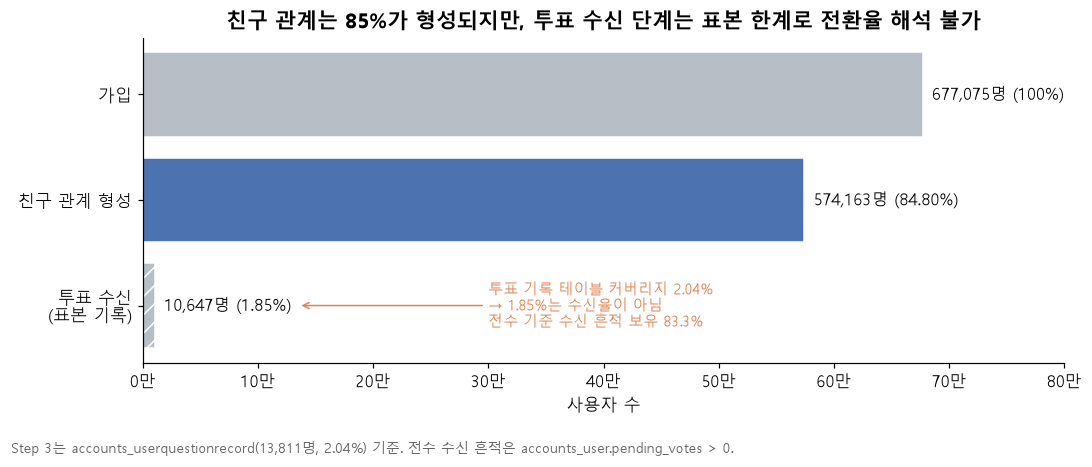

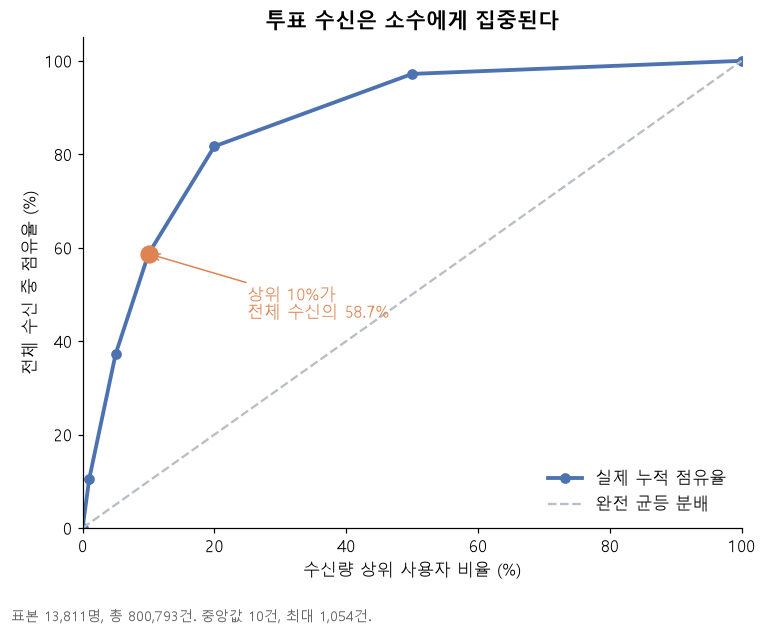

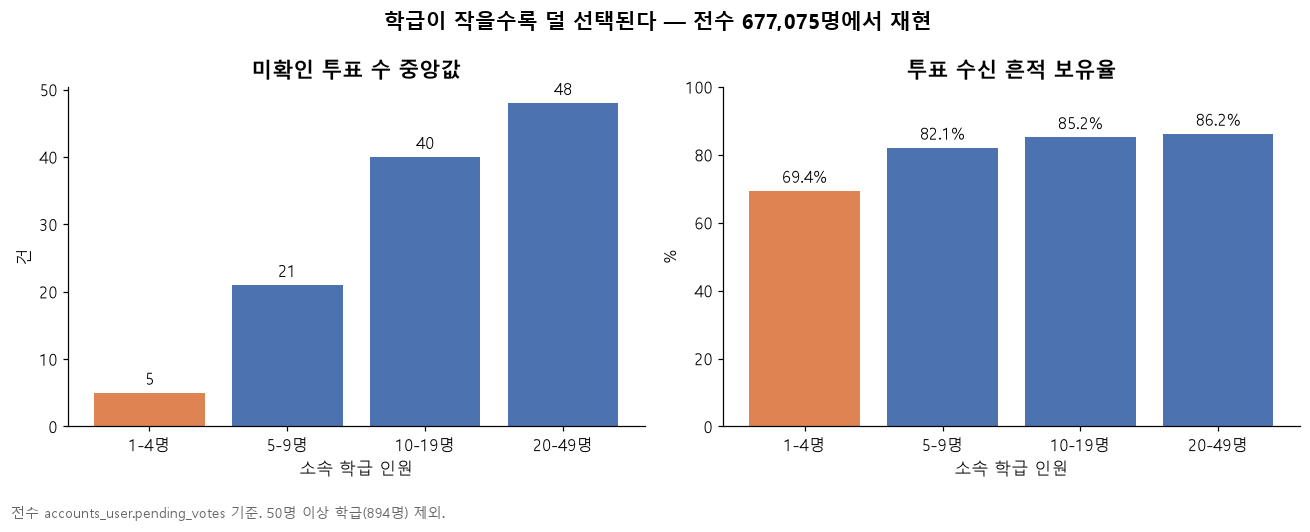

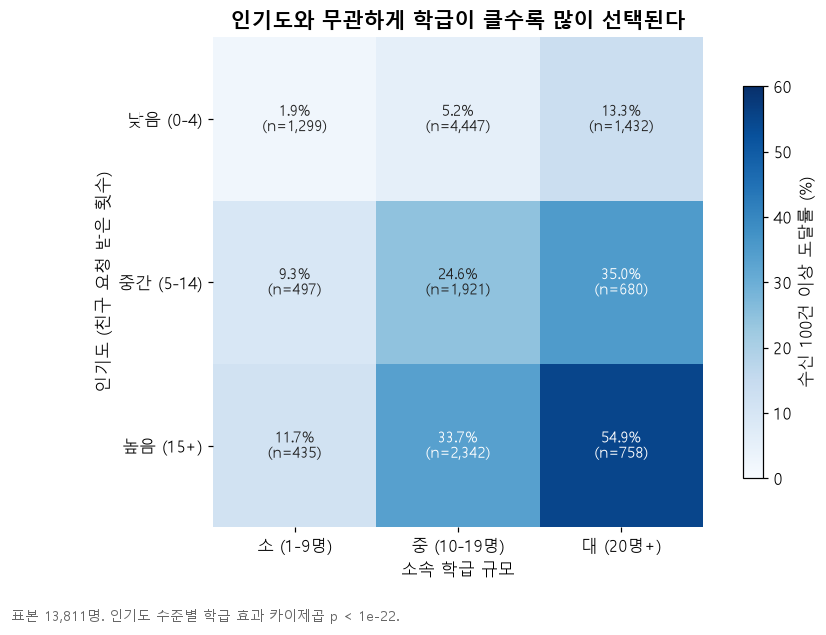

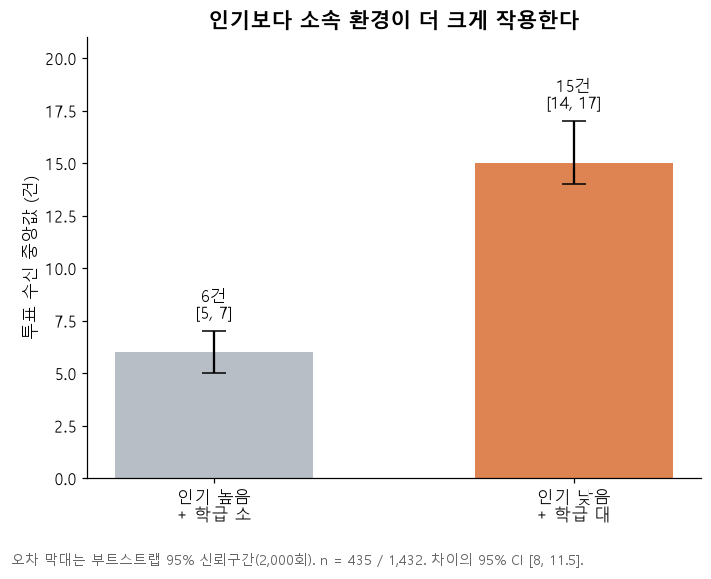

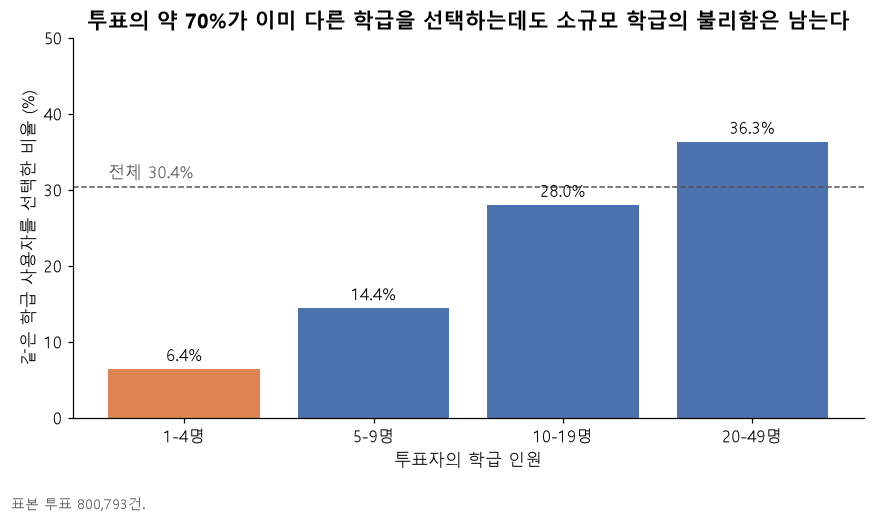

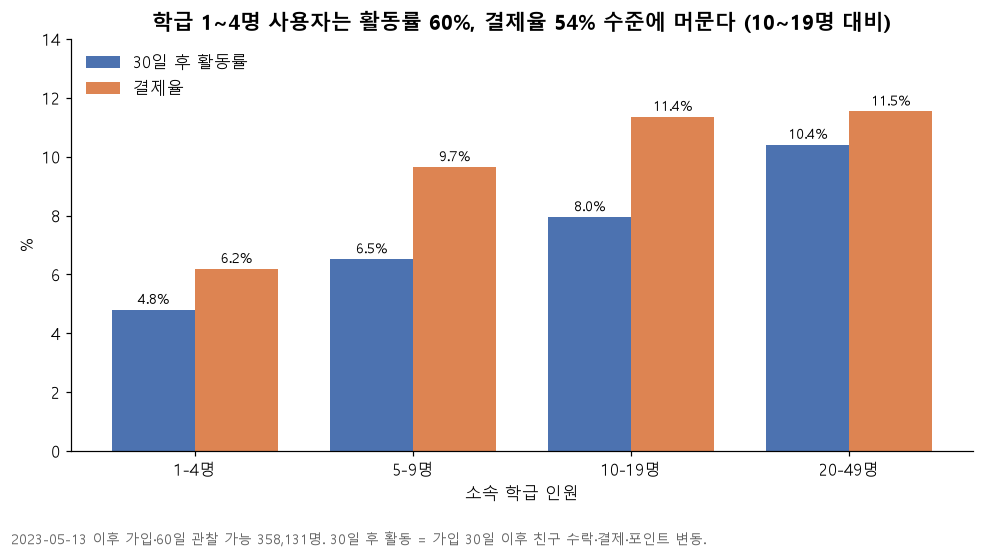

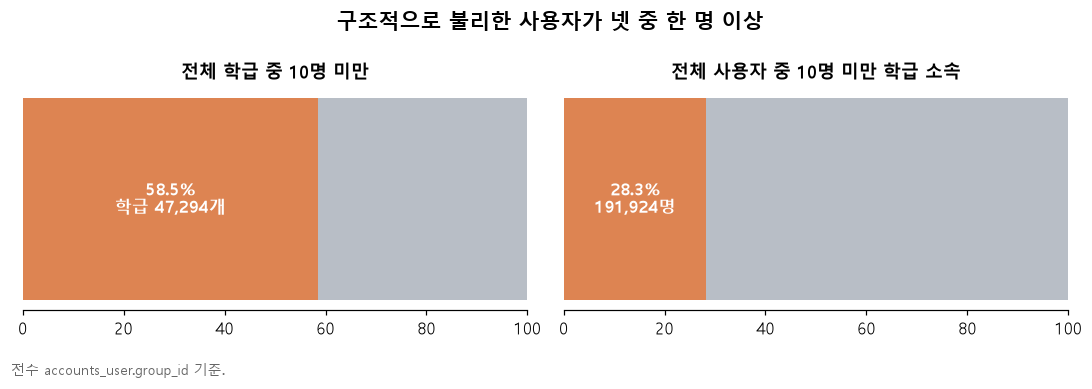

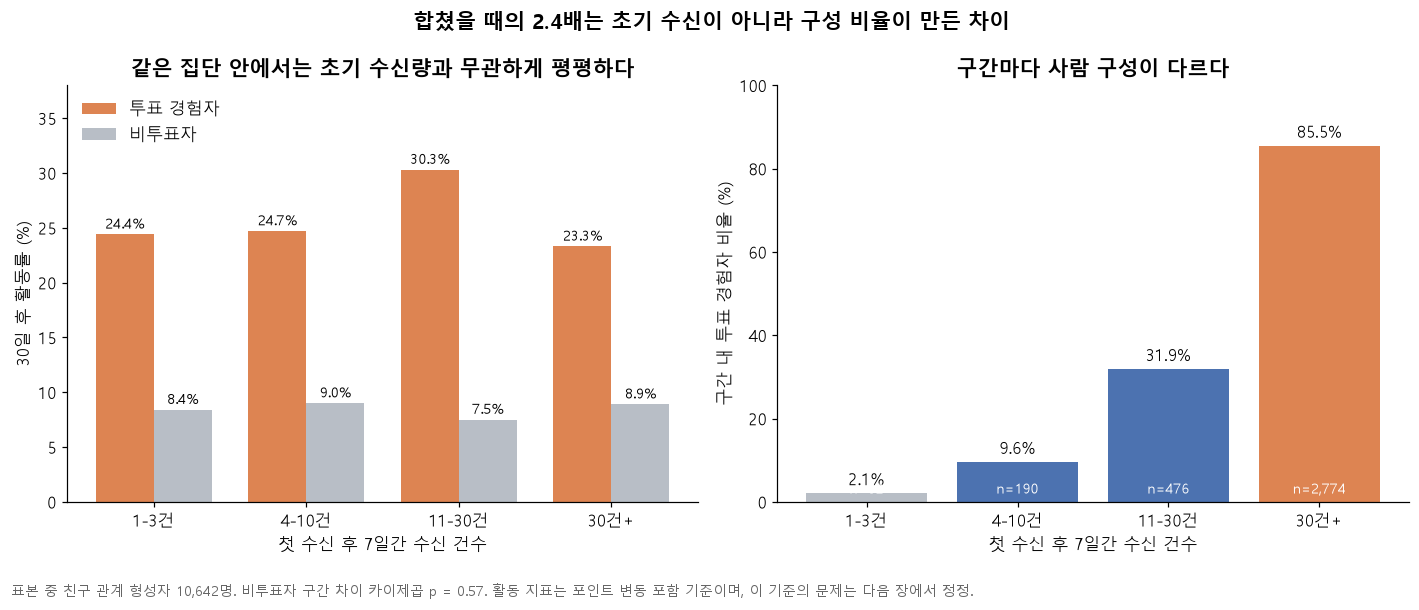

C:\Users\herosys\AppData\Local\Temp\ipykernel_23092\3868261251.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()
C:\Users\herosys\AppData\Local\Temp\ipykernel_23092\3868261251.py:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
c:\Users\herosys\codeit-final\team4-final-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


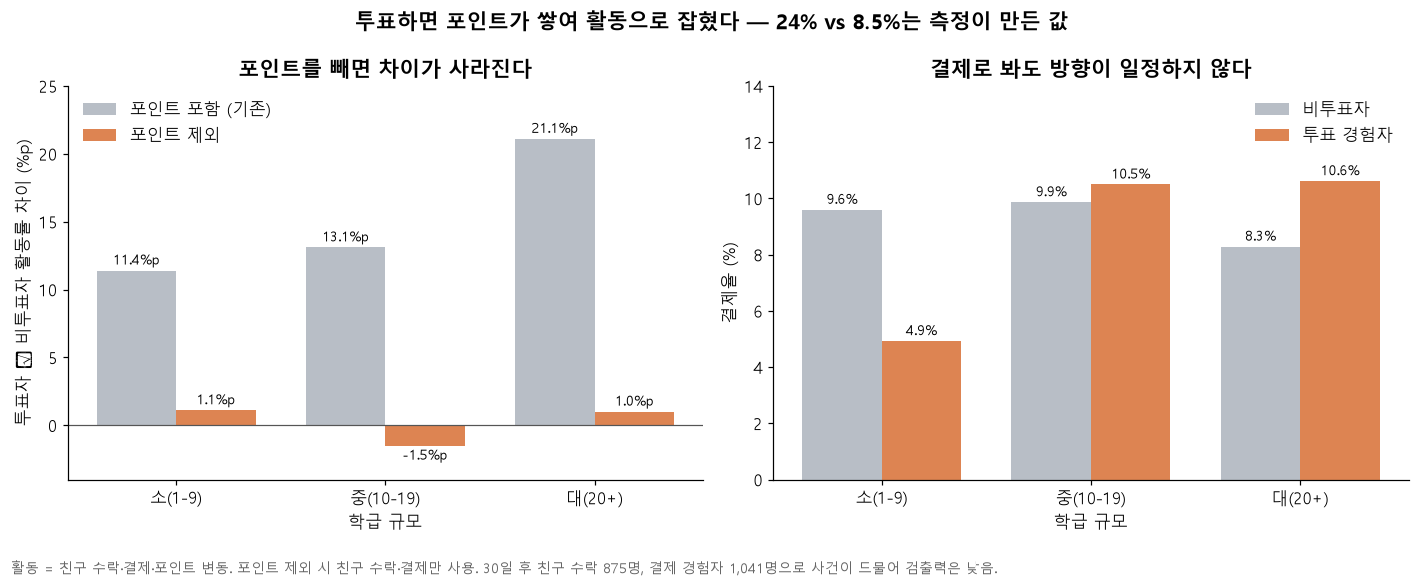

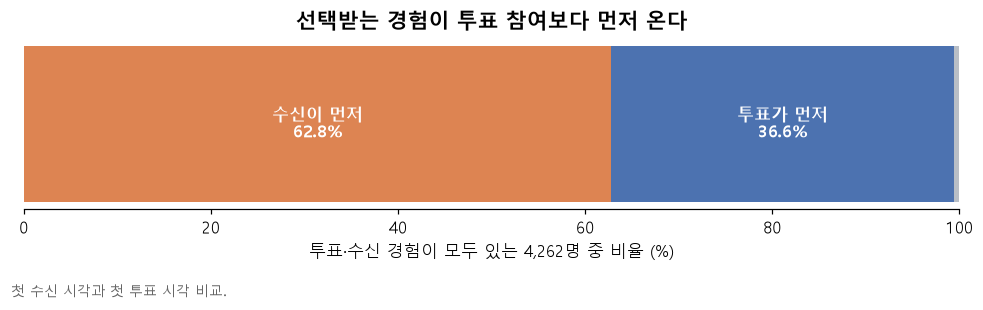

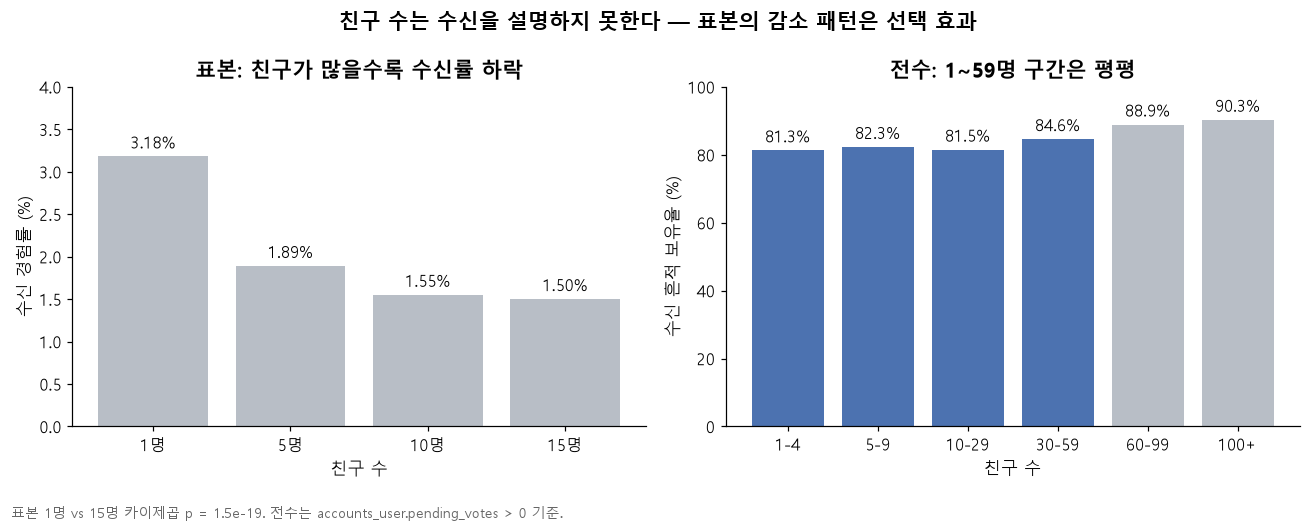

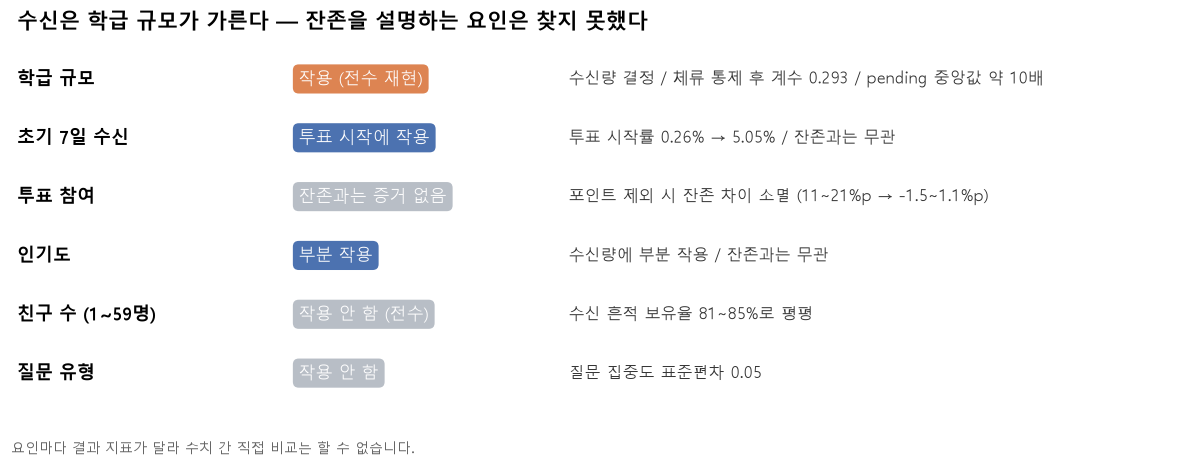

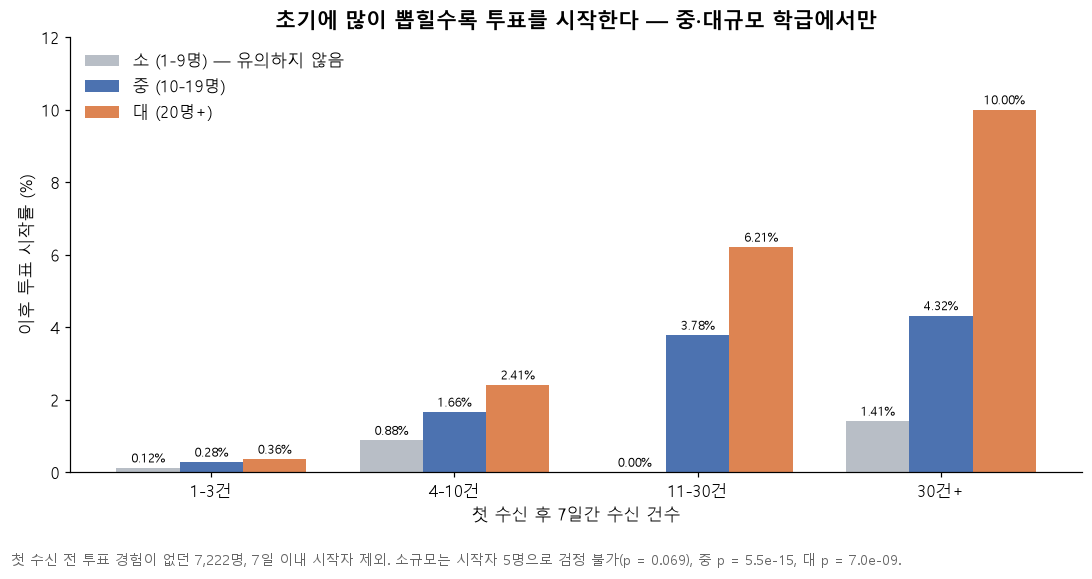

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_step2_3


In [43]:
# Step 2 → 3 종합 시각화
# 값은 최종 EDA 문서(step2_3_friend_to_vote.md)의 수치를 사용합니다.
# 노트북 재실행으로 수치가 바뀌면 각 셀 상단의 값만 수정하세요.
# VSCode에서 '# %%' 단위로 셀 실행이 가능합니다.

# %% 0. 설정
import platform
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    mpl.rcParams["font.family"] = "Noto Sans CJK KR"

mpl.rcParams.update({
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#4C72B0"     # 기본
ORANGE = "#DD8452"   # 강조 (핵심 인사이트)
GRAY = "#B8BEC6"     # 보조

OUT = Path("figures_step2_3")
OUT.mkdir(exist_ok=True)


def finish(fig, name, note=None):
    if note:
        fig.text(0.01, -0.02, note, fontsize=9, color="#666666", ha="left", va="top")
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


# %% 1. 퍼널과 데이터 함정 — 1.85%는 수신율이 아니다
steps = ["가입", "친구 관계 형성", "투표 수신\n(표본 기록)"]
vals = [677_075, 574_163, 10_647]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(steps, vals, color=[GRAY, BLUE, GRAY], hatch=["", "", "//"], edgecolor="white")
ax.invert_yaxis()
ax.set_xlim(0, 800_000)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f"{x/1e4:.0f}만"))
for b, v, t in zip(bars, vals, ["100%", "84.80%", "1.85%"]):
    ax.text(v + 8_000, b.get_y() + b.get_height() / 2, f"{v:,}명 ({t})", va="center")
ax.annotate("투표 기록 테이블 커버리지 2.04%\n→ 1.85%는 수신율이 아님\n전수 기준 수신 흔적 보유 83.3%",
            xy=(135_000, 2), xytext=(300_000, 2), va="center", color=ORANGE, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_title("친구 관계는 85%가 형성되지만, 투표 수신 단계는 표본 한계로 전환율 해석 불가")
ax.set_xlabel("사용자 수")
finish(fig, "01_funnel_coverage",
       "Step 3는 accounts_userquestionrecord(13,811명, 2.04%) 기준. 전수 수신 흔적은 accounts_user.pending_votes > 0.")


# %% 2. 수신 편중 — 상위 10%가 58.7%
x = [0, 1, 5, 10, 20, 50, 100]
y = [0, 10.5, 37.2, 58.7, 81.7, 97.2, 100]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(x, y, marker="o", color=BLUE, linewidth=2.5, label="실제 누적 점유율")
ax.plot([0, 100], [0, 100], linestyle="--", color=GRAY, label="완전 균등 분배")
ax.scatter([10], [58.7], s=120, color=ORANGE, zorder=5)
ax.annotate("상위 10%가\n전체 수신의 58.7%", xy=(10, 58.7), xytext=(25, 45),
            color=ORANGE, fontsize=11, arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
ax.set_xlabel("수신량 상위 사용자 비율 (%)")
ax.set_ylabel("전체 수신 중 점유율 (%)")
ax.set_title("투표 수신은 소수에게 집중된다")
ax.legend(loc="lower right", frameon=False)
finish(fig, "02_concentration_curve",
       "표본 13,811명, 총 800,793건. 중앙값 10건, 최대 1,054건.")


# %% 3. 학급 규모 효과 — 전수 재현
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
median_pending = [5, 21, 40, 48]
hold_rate = [69.4, 82.1, 85.2, 86.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [ORANGE, BLUE, BLUE, BLUE]

b = axes[0].bar(classes, median_pending, color=colors)
axes[0].bar_label(b, fmt="%d", padding=3)
axes[0].set_title("미확인 투표 수 중앙값")
axes[0].set_ylabel("건")
axes[0].set_xlabel("소속 학급 인원")

b = axes[1].bar(classes, hold_rate, color=colors)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("투표 수신 흔적 보유율")
axes[1].set_ylabel("%")
axes[1].set_xlabel("소속 학급 인원")

fig.suptitle("학급이 작을수록 덜 선택된다 — 전수 677,075명에서 재현", fontsize=14, fontweight="bold")
finish(fig, "03_class_size_full",
       "전수 accounts_user.pending_votes 기준. 50명 이상 학급(894명) 제외.")


# %% 4. 학급 × 인기도 히트맵 — 두 요인은 독립적이다
rate = np.array([
    [1.9, 5.2, 13.3],
    [9.3, 24.6, 35.0],
    [11.7, 33.7, 54.9],
])
n = np.array([
    [1299, 4447, 1432],
    [497, 1921, 680],
    [435, 2342, 758],
])
rows = ["낮음 (0-4)", "중간 (5-14)", "높음 (15+)"]
cols = ["소 (1-9명)", "중 (10-19명)", "대 (20명+)"]

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(rate, cmap="Blues", vmin=0, vmax=60)
ax.set_xticks(range(3), cols)
ax.set_yticks(range(3), rows)
ax.set_xlabel("소속 학급 규모")
ax.set_ylabel("인기도 (친구 요청 받은 횟수)")
for i in range(3):
    for j in range(3):
        c = "white" if rate[i, j] > 30 else "#222222"
        ax.text(j, i, f"{rate[i, j]:.1f}%\n(n={n[i, j]:,})", ha="center", va="center", color=c, fontsize=10)
ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("수신 100건 이상 도달률 (%)")
ax.set_title("인기도와 무관하게 학급이 클수록 많이 선택된다")
finish(fig, "04_heatmap_class_popularity",
       "표본 13,811명. 인기도 수준별 학급 효과 카이제곱 p < 1e-22.")


# %% 5. 핵심 대비 — 인기 높음+학급 소 < 인기 낮음+학급 대
labels = ["인기 높음\n+ 학급 소", "인기 낮음\n+ 학급 대"]
med = [6, 15]
ci_low = [5, 14]
ci_high = [7, 17]
yerr = [[m - l for m, l in zip(med, ci_low)], [h - m for m, h in zip(med, ci_high)]]

fig, ax = plt.subplots(figsize=(6.5, 5))
b = ax.bar(labels, med, color=[GRAY, ORANGE], yerr=yerr, capsize=8, width=0.55)
for rect, m, lo, hi in zip(b, med, ci_low, ci_high):
    ax.text(rect.get_x() + rect.get_width() / 2, hi + 0.6, f"{m}건\n[{lo}, {hi}]", ha="center")
ax.set_ylim(0, 21)
ax.set_ylabel("투표 수신 중앙값 (건)")
ax.set_title("인기보다 소속 환경이 더 크게 작용한다")
finish(fig, "05_key_contrast",
       "오차 막대는 부트스트랩 95% 신뢰구간(2,000회). n = 435 / 1,432. 차이의 95% CI [8, 11.5].")


# %% 6. 반 간 혼합 — 이미 70%가 다른 학급을 선택
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
same = [6.4, 14.4, 28.0, 36.3]

fig, ax = plt.subplots(figsize=(8, 4.5))
b = ax.bar(classes, same, color=[ORANGE, BLUE, BLUE, BLUE])
ax.bar_label(b, fmt="%.1f%%", padding=3)
ax.axhline(30.4, color="#555555", linestyle="--", linewidth=1)
ax.text(-0.4, 31.5, "전체 30.4%", ha="left", color="#555555")
ax.set_ylim(0, 50)
ax.set_xlabel("투표자의 학급 인원")
ax.set_ylabel("같은 학급 사용자를 선택한 비율 (%)")
ax.set_title("투표의 약 70%가 이미 다른 학급을 선택하는데도 소규모 학급의 불리함은 남는다")
finish(fig, "06_cross_class_votes", "표본 투표 800,793건.")


# %% 7. 소규모 학급 사용자의 활동과 결제
classes = ["1-4명", "5-9명", "10-19명", "20-49명"]
act30 = [4.80, 6.52, 7.95, 10.41]
pay = [6.19, 9.65, 11.36, 11.54]
xpos = np.arange(len(classes))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.8))
b1 = ax.bar(xpos - w / 2, act30, w, color=BLUE, label="30일 후 활동률")
b2 = ax.bar(xpos + w / 2, pay, w, color=ORANGE, label="결제율")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xticks(xpos, classes)
ax.set_ylim(0, 14)
ax.set_xlabel("소속 학급 인원")
ax.set_ylabel("%")
ax.legend(frameon=False)
ax.set_title("학급 1~4명 사용자는 활동률 60%, 결제율 54% 수준에 머문다 (10~19명 대비)")
finish(fig, "07_small_class_activity_payment",
       "2023-05-13 이후 가입·60일 관찰 가능 358,131명. 30일 후 활동 = 가입 30일 이후 친구 수락·결제·포인트 변동.")


# %% 8. 대상 규모 — 학급의 58.5%가 10명 미만
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (title, small, total_label) in zip(axes, [
    ("전체 학급 중 10명 미만", 58.5, "학급 47,294개"),
    ("전체 사용자 중 10명 미만 학급 소속", 28.3, "191,924명"),
]):
    ax.barh([0], [100], color=GRAY, height=0.5)
    ax.barh([0], [small], color=ORANGE, height=0.5)
    ax.text(small / 2, 0, f"{small}%\n{total_label}", ha="center", va="center", color="white", fontweight="bold")
    ax.set_xlim(0, 100); ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    ax.spines[["left"]].set_visible(False)
fig.suptitle("구조적으로 불리한 사용자가 넷 중 한 명 이상", fontsize=14, fontweight="bold")
finish(fig, "08_target_size", "전수 accounts_user.group_id 기준.")


# %% 9. 1차 정정 — 2.4배는 구성 효과였다
groups = ["1-3건", "4-10건", "11-30건", "30건+"]
act_voter = [24.4, 24.7, 30.3, 23.3]
act_nonvoter = [8.4, 9.0, 7.5, 8.9]
voter_share = [2.1, 9.6, 31.9, 85.5]
voter_n = [82, 190, 476, 2774]

xpos = np.arange(len(groups))
w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

b1 = axes[0].bar(xpos - w / 2, act_voter, w, color=ORANGE, label="투표 경험자")
b2 = axes[0].bar(xpos + w / 2, act_nonvoter, w, color=GRAY, label="비투표자")
axes[0].bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
axes[0].bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
axes[0].set_xticks(xpos, groups)
axes[0].set_ylim(0, 38)
axes[0].set_ylabel("30일 후 활동률 (%)")
axes[0].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[0].legend(frameon=False, loc="upper left")
axes[0].set_title("같은 집단 안에서는 초기 수신량과 무관하게 평평하다")

b = axes[1].bar(groups, voter_share, color=[GRAY, BLUE, BLUE, ORANGE])
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
for rect, n in zip(b, voter_n):
    axes[1].text(rect.get_x() + rect.get_width() / 2, 2, f"n={n:,}",
                 ha="center", fontsize=9, color="white")
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("구간 내 투표 경험자 비율 (%)")
axes[1].set_xlabel("첫 수신 후 7일간 수신 건수")
axes[1].set_title("구간마다 사람 구성이 다르다")

fig.suptitle("합쳤을 때의 2.4배는 초기 수신이 아니라 구성 비율이 만든 차이",
             fontsize=14, fontweight="bold")
finish(fig, "09_composition_effect",
       "표본 중 친구 관계 형성자 10,642명. 비투표자 구간 차이 카이제곱 p = 0.57. "
       "활동 지표는 포인트 변동 포함 기준이며, 이 기준의 문제는 다음 장에서 정정.")


# %% 9b. 2차 정정 — 활동 지표에 순환이 있었다
classes = ["소(1-9)", "중(10-19)", "대(20+)"]
gap_with = [11.4, 13.1, 21.1]     # 포인트 포함
gap_without = [1.1, -1.5, 1.0]    # 포인트 제외
pay_non = [9.60, 9.87, 8.29]      # 비투표자 결제율
pay_voter = [4.93, 10.50, 10.62]  # 투표자 결제율

xpos = np.arange(len(classes))
w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 5)) 

b1 = axes[0].bar(xpos - w / 2, gap_with, w, color=GRAY, label="포인트 포함 (기존)")
b2 = axes[0].bar(xpos + w / 2, gap_without, w, color=ORANGE, label="포인트 제외")
axes[0].bar_label(b1, fmt="%.1f%%p", padding=2, fontsize=9)
axes[0].bar_label(b2, fmt="%.1f%%p", padding=2, fontsize=9)
axes[0].axhline(0, color="#555555", linewidth=0.8)
axes[0].set_xticks(xpos, classes)
axes[0].set_ylim(-4, 25)
axes[0].set_ylabel("투표자 − 비투표자 활동률 차이 (%p)")
axes[0].set_xlabel("학급 규모")
axes[0].legend(frameon=False)
axes[0].set_title("포인트를 빼면 차이가 사라진다")

b1 = axes[1].bar(xpos - w / 2, pay_non, w, color=GRAY, label="비투표자")
b2 = axes[1].bar(xpos + w / 2, pay_voter, w, color=ORANGE, label="투표 경험자")
axes[1].bar_label(b1, fmt="%.1f%%", padding=2, fontsize=9)
axes[1].bar_label(b2, fmt="%.1f%%", padding=2, fontsize=9)
axes[1].set_xticks(xpos, classes)
axes[1].set_ylim(0, 14)
axes[1].set_ylabel("결제율 (%)")
axes[1].set_xlabel("학급 규모")
axes[1].legend(frameon=False)
axes[1].set_title("결제로 봐도 방향이 일정하지 않다")

fig.suptitle("투표하면 포인트가 쌓여 활동으로 잡혔다 — 24% vs 8.5%는 측정이 만든 값",
             fontsize=14, fontweight="bold")
finish(fig, "09b_measurement_circularity",
       "활동 = 친구 수락·결제·포인트 변동. 포인트 제외 시 친구 수락·결제만 사용. "
       "30일 후 친구 수락 875명, 결제 경험자 1,041명으로 사건이 드물어 검출력은 낮음.")


# %% 10. 수신 → 투표 순서
labels = ["수신이 먼저", "투표가 먼저", "동시"]
share = [62.8, 36.6, 0.6]

fig, ax = plt.subplots(figsize=(9, 2.6))
left = 0
for lab, s, c in zip(labels, share, [ORANGE, BLUE, GRAY]):
    ax.barh([0], [s], left=left, color=c, height=0.5)
    if s > 5:
        ax.text(left + s / 2, 0, f"{lab}\n{s}%", ha="center", va="center", color="white", fontweight="bold")
    left += s
ax.set_xlim(0, 100); ax.set_yticks([])
ax.spines[["left"]].set_visible(False)
ax.set_xlabel("투표·수신 경험이 모두 있는 4,262명 중 비율 (%)")
ax.set_title("선택받는 경험이 투표 참여보다 먼저 온다")
finish(fig, "10_receive_before_vote", "첫 수신 시각과 첫 투표 시각 비교.")


# %% 11. 친구 수 — 표본의 역설은 전수에서 재현되지 않는다
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

f_sample = ["1명", "5명", "10명", "15명"]
r_sample = [3.18, 1.89, 1.55, 1.50]
b = axes[0].bar(f_sample, r_sample, color=GRAY)
axes[0].bar_label(b, fmt="%.2f%%", padding=3)
axes[0].set_ylim(0, 4)
axes[0].set_title("표본: 친구가 많을수록 수신률 하락")
axes[0].set_xlabel("친구 수")
axes[0].set_ylabel("수신 경험률 (%)")

f_full = ["1-4", "5-9", "10-29", "30-59", "60-99", "100+"]
h_full = [81.3, 82.3, 81.5, 84.6, 88.9, 90.3]
b = axes[1].bar(f_full, h_full, color=[BLUE] * 4 + [GRAY] * 2)
axes[1].bar_label(b, fmt="%.1f%%", padding=3)
axes[1].set_ylim(0, 100)
axes[1].set_title("전수: 1~59명 구간은 평평")
axes[1].set_xlabel("친구 수")
axes[1].set_ylabel("수신 흔적 보유율 (%)")

fig.suptitle("친구 수는 수신을 설명하지 못한다 — 표본의 감소 패턴은 선택 효과", fontsize=14, fontweight="bold")
finish(fig, "11_friend_count_sample_vs_full",
       "표본 1명 vs 15명 카이제곱 p = 1.5e-19. 전수는 accounts_user.pending_votes > 0 기준.")


# %% 12. 요인 요약 — 무엇이 작용하고 무엇이 작용하지 않는가
factors = ["학급 규모", "초기 7일 수신", "투표 참여", "인기도", "친구 수 (1~59명)", "질문 유형"]
verdict = ["작용 (전수 재현)", "투표 시작에 작용", "잔존과는 증거 없음", "부분 작용", "작용 안 함 (전수)", "작용 안 함"]
evidence = [
    "수신량 결정 / 체류 통제 후 계수 0.293 / pending 중앙값 약 10배",
    "투표 시작률 0.26% → 5.05% / 잔존과는 무관",
    "포인트 제외 시 잔존 차이 소멸 (11~21%p → -1.5~1.1%p)",
    "수신량에 부분 작용 / 잔존과는 무관",
    "수신 흔적 보유율 81~85%로 평평",
    "질문 집중도 표준편차 0.05",
]
def verdict_color(v):
    if v.startswith("작용 ("):
        return ORANGE
    if v.startswith("부분") or v.startswith("투표 시작"):
        return BLUE
    if v.startswith("결과"):
        return "#7F8790"
    return GRAY


fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")
for i, (f, v, e) in enumerate(zip(factors, verdict, evidence)):
    y = len(factors) - i
    c = verdict_color(v)
    ax.text(0.00, y, f, fontsize=12, fontweight="bold", va="center")
    ax.text(0.24, y, v, fontsize=11, va="center", color="white",
            bbox=dict(boxstyle="round,pad=0.35", fc=c, ec="none"))
    ax.text(0.47, y, e, fontsize=10.5, va="center", color="#333333")
ax.set_xlim(0, 1); ax.set_ylim(0.3, len(factors) + 0.7)
ax.set_title("수신은 학급 규모가 가른다 — 잔존을 설명하는 요인은 찾지 못했다", loc="left")
finish(fig, "12_factor_summary", "요인마다 결과 지표가 달라 수치 간 직접 비교는 할 수 없습니다.")

# %% 13. 제안 근거 — 학급 규모별 투표 시작률
groups = ["1-3건", "4-10건", "11-30건", "30건+"]
small = [0.12, 0.88, 0.00, 1.41]
mid   = [0.28, 1.66, 3.78, 4.32]
big   = [0.36, 2.41, 6.21, 10.00]

xpos = np.arange(len(groups))
w = 0.26
fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(xpos - w, small, w, color=GRAY, label="소 (1-9명) — 유의하지 않음")
b2 = ax.bar(xpos,     mid,   w, color=BLUE, label="중 (10-19명)")
b3 = ax.bar(xpos + w, big,   w, color=ORANGE, label="대 (20명+)")
for b in (b1, b2, b3):
    ax.bar_label(b, fmt="%.2f%%", padding=2, fontsize=8)

ax.set_xticks(xpos, groups)
ax.set_ylim(0, 12)
ax.set_xlabel("첫 수신 후 7일간 수신 건수")
ax.set_ylabel("이후 투표 시작률 (%)")
ax.legend(frameon=False)
ax.set_title("초기에 많이 뽑힐수록 투표를 시작한다 — 중·대규모 학급에서만")
finish(fig, "13_vote_start_by_class",
       "첫 수신 전 투표 경험이 없던 7,222명, 7일 이내 시작자 제외. "
       "소규모는 시작자 5명으로 검정 불가(p = 0.069), 중 p = 5.5e-15, 대 p = 7.0e-09.")


print(f"저장 위치: {OUT.resolve()}")

In [44]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

base = 0.0026      # 기준선 0.26%
target = 0.0165    # 목표 1.65%

es = proportion_effectsize(target, base)
n = NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.8, ratio=1)
print(f"군당 필요 사용자: {n:,.0f}명 (단순 무작위 기준)")

# 클러스터 배정 보정 (design effect)
for m, icc in [(50, 0.01), (50, 0.05), (100, 0.01)]:
    de = 1 + (m - 1) * icc
    print(f"학교당 {m}명, ICC {icc}: 보정 후 군당 {n*de:,.0f}명 = 학교 {n*de/m:,.0f}개")

군당 필요 사용자: 648명 (단순 무작위 기준)
학교당 50명, ICC 0.01: 보정 후 군당 966명 = 학교 19개
학교당 50명, ICC 0.05: 보정 후 군당 2,237명 = 학교 45개
학교당 100명, ICC 0.01: 보정 후 군당 1,290명 = 학교 13개


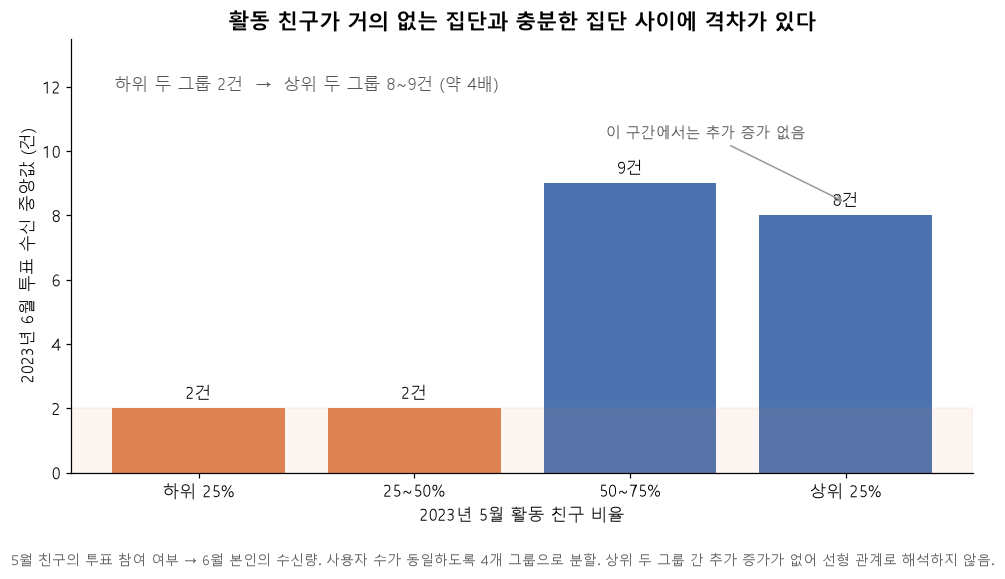

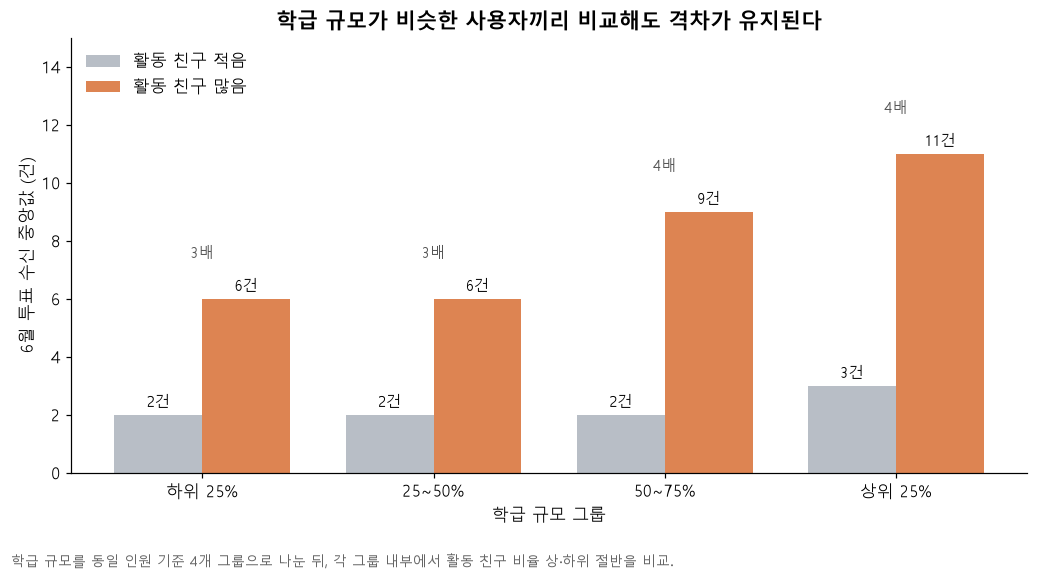

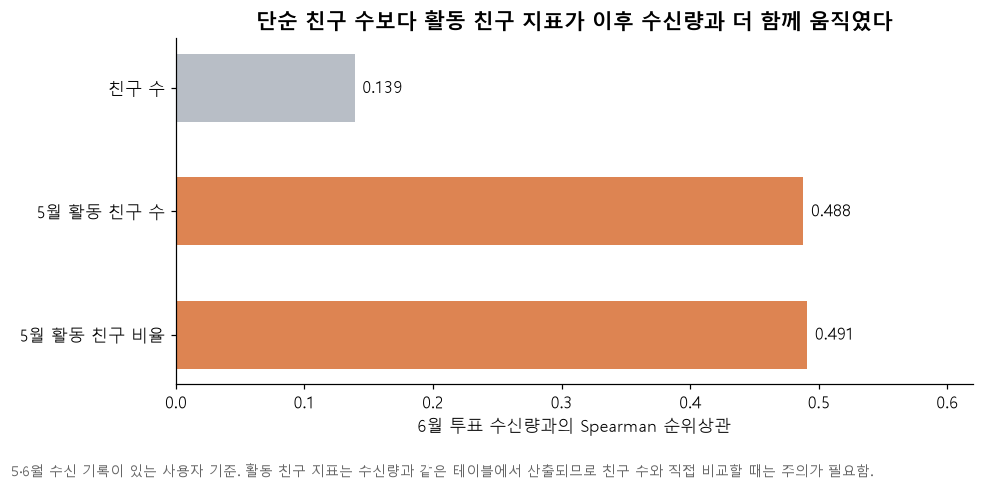

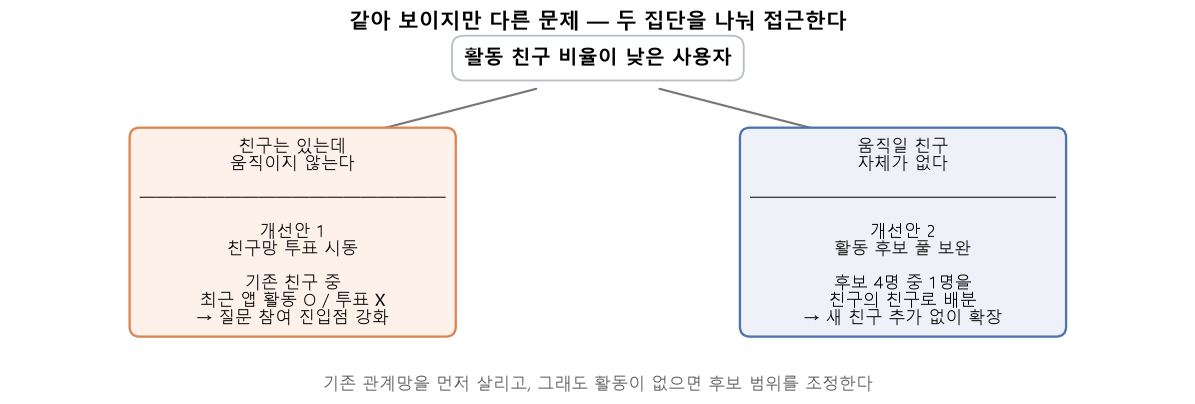

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_friend_activity


In [45]:
# 친구 활동성 개선안 근거 차트
# 값은 팀 분석 결과(5월 → 6월 시간 분리, 학급 규모 통제)를 사용합니다.
# VSCode에서 '# %%' 단위로 셀 실행이 가능합니다.

# %% 0. 설정
import platform
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    mpl.rcParams["font.family"] = "Noto Sans CJK KR"

mpl.rcParams.update({
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#4C72B0"
ORANGE = "#DD8452"
GRAY = "#B8BEC6"

OUT = Path("figures_friend_activity")
OUT.mkdir(exist_ok=True)


def finish(fig, name, note=None):
    if note:
        fig.text(0.01, -0.02, note, fontsize=9, color="#666666", ha="left", va="top")
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


# %% 1. 시간 분리 — 5월 활동 친구 비율 → 6월 수신량
groups = ["하위 25%", "25~50%", "50~75%", "상위 25%"]
recv = [2, 2, 9, 8]

fig, ax = plt.subplots(figsize=(9, 5))
b = ax.bar(groups, recv, color=[ORANGE, ORANGE, BLUE, BLUE])
ax.bar_label(b, fmt="%d건", padding=4, fontsize=11)

ax.axhspan(0, 2, color=ORANGE, alpha=0.08)
ax.text(0.5, 11.9, "하위 두 그룹 2건  →  상위 두 그룹 8~9건 (약 4배)",
        ha="center", color="#555555", fontsize=11)
ax.annotate("이 구간에서는 추가 증가 없음", xy=(3, 8.4), xytext=(2.35, 10.4),
            ha="center", fontsize=10, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#999999", lw=1))

ax.set_ylim(0, 13.5)
ax.set_xlabel("2023년 5월 활동 친구 비율")
ax.set_ylabel("2023년 6월 투표 수신 중앙값 (건)")
ax.set_title("활동 친구가 거의 없는 집단과 충분한 집단 사이에 격차가 있다")
finish(fig, "fa01_time_split",
       "5월 친구의 투표 참여 여부 → 6월 본인의 수신량. 사용자 수가 동일하도록 4개 그룹으로 분할. "
       "상위 두 그룹 간 추가 증가가 없어 선형 관계로 해석하지 않음.")


# %% 2. 학급 규모를 통제해도 유지된다
classes = ["하위 25%", "25~50%", "50~75%", "상위 25%"]
low = [2, 2, 2, 3]
high = [6, 6, 9, 11]

xpos = np.arange(len(classes))
w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 5))

b1 = ax.bar(xpos - w / 2, low, w, color=GRAY, label="활동 친구 적음")
b2 = ax.bar(xpos + w / 2, high, w, color=ORANGE, label="활동 친구 많음")
ax.bar_label(b1, fmt="%d건", padding=3, fontsize=10)
ax.bar_label(b2, fmt="%d건", padding=3, fontsize=10)

for i, (l, h) in enumerate(zip(low, high)):
    ax.text(i, h + 1.4, f"{h/l:.0f}배", ha="center", color="#555555", fontsize=10)

ax.set_xticks(xpos, classes)
ax.set_ylim(0, 15)
ax.set_xlabel("학급 규모 그룹")
ax.set_ylabel("6월 투표 수신 중앙값 (건)")
ax.legend(frameon=False)
ax.set_title("학급 규모가 비슷한 사용자끼리 비교해도 격차가 유지된다")
finish(fig, "fa02_class_controlled",
       "학급 규모를 동일 인원 기준 4개 그룹으로 나눈 뒤, 각 그룹 내부에서 활동 친구 비율 상·하위 절반을 비교.")


# %% 3. 친구 수보다 활동 친구가 더 함께 움직인다
labels = ["친구 수", "5월 활동 친구 수", "5월 활동 친구 비율"]
corr = [0.139, 0.488, 0.491]

fig, ax = plt.subplots(figsize=(9, 4.2))
b = ax.barh(labels, corr, color=[GRAY, ORANGE, ORANGE], height=0.55)
ax.bar_label(b, fmt="%.3f", padding=5, fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 0.62)
ax.set_xlabel("6월 투표 수신량과의 Spearman 순위상관")
ax.set_title("단순 친구 수보다 활동 친구 지표가 이후 수신량과 더 함께 움직였다")
finish(fig, "fa03_spearman",
       "5·6월 수신 기록이 있는 사용자 기준. 활동 친구 지표는 수신량과 같은 테이블에서 산출되므로 "
       "친구 수와 직접 비교할 때는 주의가 필요함.")


# %% 4. 개선안 분기 — 두 집단은 다른 문제다
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")

box = dict(boxstyle="round,pad=0.6", fc="white", ec="#B8BEC6", lw=1.2)
box_o = dict(boxstyle="round,pad=0.6", fc="#FDF1EA", ec=ORANGE, lw=1.5)
box_b = dict(boxstyle="round,pad=0.6", fc="#EEF2F8", ec=BLUE, lw=1.5)

ax.text(0.5, 0.92, "활동 친구 비율이 낮은 사용자", ha="center", fontsize=13,
        fontweight="bold", bbox=box)

ax.annotate("", xy=(0.24, 0.66), xytext=(0.45, 0.85),
            arrowprops=dict(arrowstyle="->", color="#777777", lw=1.4))
ax.annotate("", xy=(0.76, 0.66), xytext=(0.55, 0.85),
            arrowprops=dict(arrowstyle="->", color="#777777", lw=1.4))

ax.text(0.24, 0.42,
        "친구는 있는데\n움직이지 않는다\n\n" + "─" * 18 + "\n\n"
        "개선안 1\n친구망 투표 시동\n\n기존 친구 중\n최근 앱 활동 O / 투표 X\n→ 질문 참여 진입점 강화",
        ha="center", va="center", fontsize=11, bbox=box_o)

ax.text(0.76, 0.42,
        "움직일 친구\n자체가 없다\n\n" + "─" * 18 + "\n\n"
        "개선안 2\n활동 후보 풀 보완\n\n후보 4명 중 1명을\n친구의 친구로 배분\n→ 새 친구 추가 없이 확장",
        ha="center", va="center", fontsize=11, bbox=box_b)

ax.text(0.5, -0.05, "기존 관계망을 먼저 살리고, 그래도 활동이 없으면 후보 범위를 조정한다",
        ha="center", fontsize=11, color="#555555")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("같아 보이지만 다른 문제 — 두 집단을 나눠 접근한다", loc="center")
finish(fig, "fa04_two_branches")

print(f"저장 위치: {OUT.resolve()}")

In [46]:
import pandas as pd
from pathlib import Path

DATA = PROJECT_ROOT / "data" / "processed" / "preprocessed_data_2"

user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
user['created_at'] = pd.to_datetime(user['created_at'])

# ============================================
# 1. 탈퇴 관련 컬럼·테이블 확인
# ============================================
print("=== accounts_user 컬럼 ===")
print([c for c in user.columns if 'ban' in c.lower() or 'withdraw' in c.lower() or 'delete' in c.lower()])
print()
print("=== ban_status 분포 ===")
print(user['ban_status'].value_counts(dropna=False))
print()

# 전처리본에 withdraw 테이블이 있는지
wd_path = DATA / "accounts_userwithdraw_preprocessed_2.csv"
print(f"accounts_userwithdraw 전처리본 존재: {wd_path.exists()}")
if wd_path.exists():
    wd = pd.read_csv(wd_path)
    print(f"  행수: {len(wd):,}, 컬럼: {wd.columns.tolist()}")

=== accounts_user 컬럼 ===
['ban_status']

=== ban_status 분포 ===
ban_status
N     668422
W       7855
NB       608
RB       190
Name: count, dtype: int64

accounts_userwithdraw 전처리본 존재: False


In [47]:
import pymysql
import pandas as pd

conn = pymysql.connect(host='localhost', user='root', password='codeit1234',
                       database='final', charset='utf8mb4')

# 컬럼 구조 먼저 확인
cols = pd.read_sql("SHOW COLUMNS FROM accounts_userwithdraw", conn)
print(cols[['Field', 'Type']])

# 월별 집계 (% 이스케이프 없이)
wd = pd.read_sql("""
    SELECT LEFT(created_at, 7) AS 월, COUNT(*) AS 탈퇴
    FROM accounts_userwithdraw
    GROUP BY 1 ORDER BY 1
""", conn)
print("\n=== 월별 탈퇴 ===")
print(wd)

conn.close()

        Field         Type
0          id       bigint
1      reason  varchar(50)
2  created_at     datetime

=== 월별 탈퇴 ===
          월     탈퇴
0   2023-03     17
1   2023-04   2397
2   2023-05  44845
3   2023-06   9642
4   2023-07   4811
5   2023-08   2310
6   2023-09   2450
7   2023-10   1164
8   2023-11    837
9   2023-12    693
10  2024-01    697
11  2024-02    319
12  2024-03    250
13  2024-04    240
14  2024-05     92


C:\Users\herosys\AppData\Local\Temp\ipykernel_23092\2626267065.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cols = pd.read_sql("SHOW COLUMNS FROM accounts_userwithdraw", conn)
C:\Users\herosys\AppData\Local\Temp\ipykernel_23092\2626267065.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  wd = pd.read_sql("""


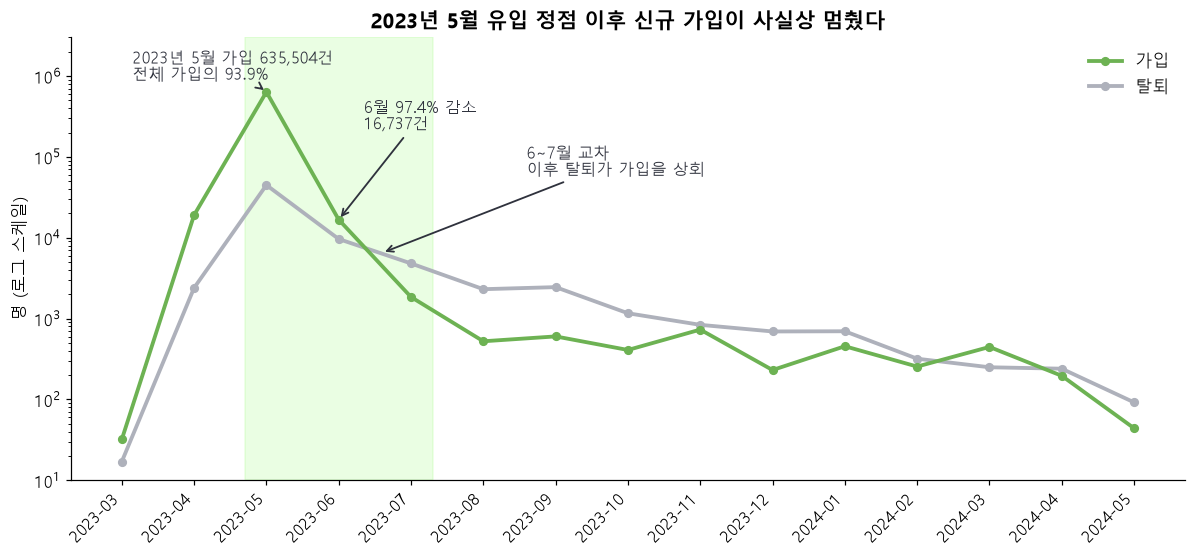

In [48]:
import platform
import matplotlib as mpl
import matplotlib.pyplot as plt

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"

mpl.rcParams.update({
    "axes.unicode_minus": False, "figure.dpi": 110, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})

BASE = "#AEB1BB"   # gray-300  — 기본
EMPH = "#99FA75"   # green-200 — 강조
MID  = "#6DB253"   # green-300 — 중간
INK  = "#2F323D"   # gray-800  — 텍스트

months = ["2023-03","2023-04","2023-05","2023-06","2023-07","2023-08","2023-09",
          "2023-10","2023-11","2023-12","2024-01","2024-02","2024-03","2024-04","2024-05"]
signup   = [32, 19060, 635504, 16737, 1849, 524, 602, 409, 731, 231, 455, 255, 446, 196, 44]
withdraw = [17, 2397, 44845, 9642, 4811, 2310, 2450, 1164, 837, 693, 697, 319, 250, 240, 92]

fig, ax = plt.subplots(figsize=(11, 5.2))

# 5~7월 강조 구간
ax.axvspan(1.7, 4.3, color=EMPH, alpha=0.20, zorder=0)

ax.plot(months, signup, marker="o", markersize=5, linewidth=2.5,
        color=MID, label="가입", zorder=3)
ax.plot(months, withdraw, marker="o", markersize=5, linewidth=2.5,
        color=BASE, label="탈퇴", zorder=2)

ax.set_yscale("log")
ax.set_ylim(10, 3_000_000)
ax.set_ylabel("명 (로그 스케일)")
ax.legend(frameon=False, loc="upper right")

# 정점
ax.annotate("2023년 5월 가입 635,504건\n전체 가입의 93.9%",
            xy=(2, 635504), xytext=(0.15, 900_000),
            fontsize=10.5, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))

# 급감 구간
ax.annotate("6월 97.4% 감소\n16,737건",
            xy=(3, 16737), xytext=(3.35, 220_000),
            fontsize=10.5, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))

# 교차 지점
ax.annotate("6~7월 교차\n이후 탈퇴가 가입을 상회",
            xy=(3.6, 6500), xytext=(5.6, 60_000),
            fontsize=10.5, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))

plt.xticks(rotation=45, ha="right")
ax.set_title("2023년 5월 유입 정점 이후 신규 가입이 사실상 멈췄다")



fig.tight_layout()
fig.savefig("signup_withdraw.png", dpi=200, bbox_inches="tight")
plt.show()

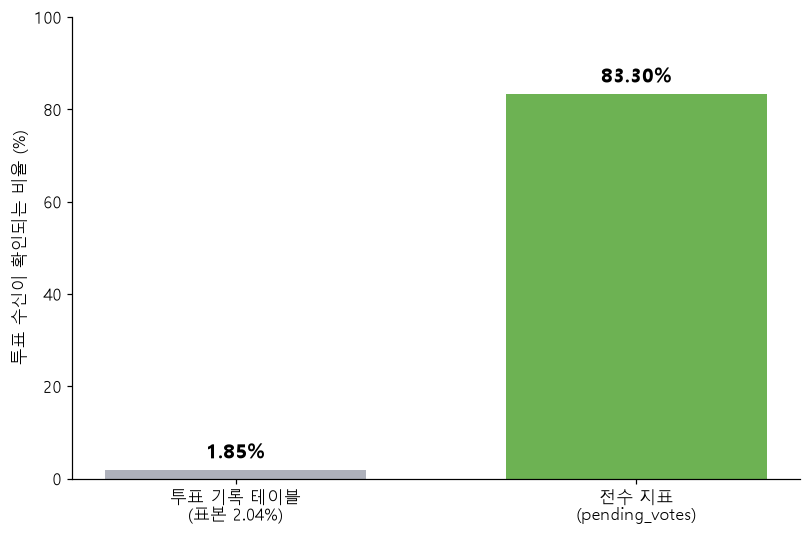

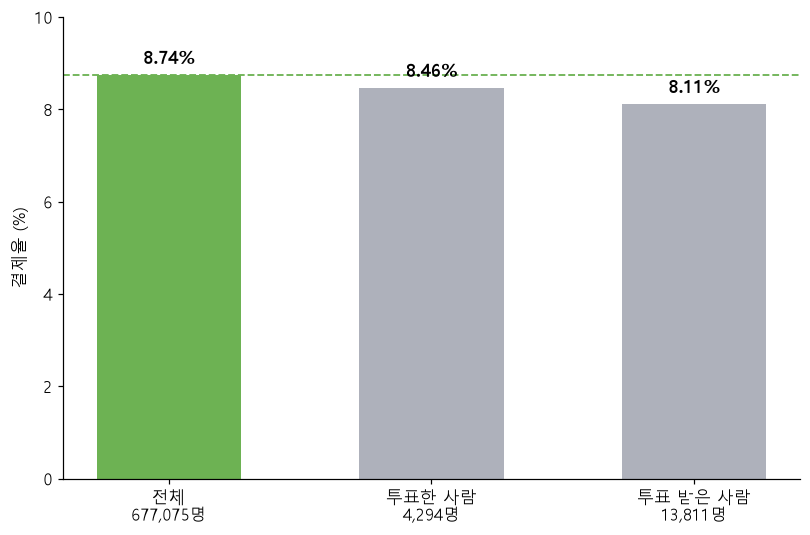

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_friend_activity


In [49]:
# %% 1. 커버리지 — 1.85%는 수신율이 아니다
labels = ["투표 기록 테이블\n(표본 2.04%)", "전수 지표\n(pending_votes)"]
values = [1.85, 83.3]

fig, ax = plt.subplots(figsize=(7.5, 5))
b = ax.bar(labels, values, color=[BASE, MID], width=0.65)
ax.bar_label(b, fmt="%.2f%%", padding=5, fontsize=13, fontweight="bold")

ax.set_ylim(0, 100)
ax.set_ylabel("투표 수신이 확인되는 비율 (%)")
finish(fig, "pr01_coverage")


# %% 2. 표본 편향 — 결제율이 유사하다
groups = ["전체\n677,075명", "투표한 사람\n4,294명", "투표 받은 사람\n13,811명"]
rates = [8.74, 8.46, 8.11]

fig, ax = plt.subplots(figsize=(7.5, 5))
b = ax.bar(groups, rates, color=[MID, BASE, BASE], width=0.55)
ax.bar_label(b, fmt="%.2f%%", padding=5, fontsize=12, fontweight="bold")

ax.axhline(8.74, color=MID, linestyle="--", linewidth=1.2, zorder=0)
ax.set_ylim(0, 10)
ax.set_ylabel("결제율 (%)")
finish(fig, "pr02_sample_bias")

print(f"저장 위치: {OUT.resolve()}")

In [50]:
import matplotlib as mpl
import matplotlib.font_manager as fm

print("설정된 폰트:", mpl.rcParams["font.family"])
print("실제 적용 파일:", fm.findfont(fm.FontProperties(family=mpl.rcParams["font.family"])))

설정된 폰트: ['Malgun Gothic']
실제 적용 파일: C:\Windows\Fonts\malgun.ttf


In [51]:
import os
print(OUT.resolve())
os.startfile(OUT / "pr02_sample_bias.png")   # 윈도우 기본 뷰어로 열기

C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\figures_friend_activity


In [52]:
import pandas as pd
from pathlib import Path

DATA = PROJECT_ROOT / "data" / "processed" / "preprocessed_data_2"

user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
uqr  = pd.read_csv(DATA / "accounts_userquestionrecord_preprocessed_2.csv")
fr   = pd.read_csv(DATA / "accounts_friendrequest_preprocessed_2.csv",
                   usecols=['send_user_id', 'receive_user_id', 'status'])
uqr['created_at'] = pd.to_datetime(uqr['created_at'])

grp_size = user.groupby('group_id').size()
g = user.set_index('id')['group_id']

# ── 친구 쌍 (양방향)
fr_a = fr[fr['status'] == 'A']
pairs = pd.concat([
    fr_a[['send_user_id', 'receive_user_id']].rename(columns={'send_user_id': 'u', 'receive_user_id': 'f'}),
    fr_a[['receive_user_id', 'send_user_id']].rename(columns={'receive_user_id': 'u', 'send_user_id': 'f'}),
]).drop_duplicates()

# ── 5월 활동 친구 비율 / 6월 수신량
may = uqr[uqr['created_at'].dt.to_period('M') == '2023-05']
jun = uqr[uqr['created_at'].dt.to_period('M') == '2023-06']

may_voters = set(may['user_id'])
pairs['활동친구'] = pairs['f'].isin(may_voters)

ratio = pairs.groupby('u')['활동친구'].agg(친구수='size', 활동친구수='sum')
ratio['활동친구비율'] = ratio['활동친구수'] / ratio['친구수'] * 100

jun_recv = jun['chosen_user_id'].value_counts().rename('6월수신')
ratio = ratio.join(jun_recv).fillna({'6월수신': 0})
ratio['학급인원'] = ratio.index.map(g).map(grp_size)
ratio = ratio.dropna(subset=['학급인원'])

# ── 분석 대상: 5·6월 기록이 있는 사용자
target = ratio[ratio.index.isin(set(may['chosen_user_id']) | set(jun['chosen_user_id']) | may_voters)]

print("=" * 60)
print("[1] 전체 대상 규모")
print("=" * 60)
print(f"친구 보유자 전체: {len(ratio):,}명")
print(f"5·6월 기록 보유: {len(target):,}명")

print()
print("=" * 60)
print("[2] 활동 친구 비율 4구간 × 학급 규모 — 6월 수신 중앙값")
print("=" * 60)
t = target.copy()
t['활동구간'] = pd.qcut(t['활동친구비율'], 4,
                      labels=['하위25%', '25-50%', '50-75%', '상위25%'], duplicates='drop')
t['학급구간'] = pd.cut(t['학급인원'], [0, 9, 19, 49, float('inf')],
                     labels=['1-9명', '10-19명', '20-49명', '50명+'])

print(t.pivot_table(index='활동구간', columns='학급구간', values='6월수신',
                    aggfunc='median', observed=True))
print("\n인원")
print(t.pivot_table(index='활동구간', columns='학급구간', values='6월수신',
                    aggfunc='size', observed=True))

print()
print("=" * 60)
print("[3] 대상 규모 — 활동 친구 비율 하위 50%")
print("=" * 60)
low = t[t['활동구간'].isin(['하위25%', '25-50%'])]
print(f"전체: {len(low):,}명")
print("\n학급 규모별:")
print(low.groupby('학급구간', observed=True).size())

print()
print("=" * 60)
print("[4] 전수 기준 활동 친구 비율 분포 (참고)")
print("=" * 60)
ratio['활동친구없음'] = ratio['활동친구수'] == 0
print(f"친구 보유자 {len(ratio):,}명 중")
print(f"  활동 친구 0명: {ratio['활동친구없음'].sum():,}명 ({ratio['활동친구없음'].mean()*100:.1f}%)")
print(f"  활동 친구 비율 25% 미만: {(ratio['활동친구비율'] < 25).sum():,}명")

[1] 전체 대상 규모
친구 보유자 전체: 574,163명
5·6월 기록 보유: 10,514명

[2] 활동 친구 비율 4구간 × 학급 규모 — 6월 수신 중앙값


ValueError: Bin labels must be one fewer than the number of bin edges

In [54]:
# PPT 기준: 6월 수신 기록이 있는 사용자만
t = target[target['6월수신'] > 0].copy()

t['활동구간'] = pd.cut(t['활동친구비율'], [-0.1, 25, 50, 100],
                     labels=['25% 미만', '25-50%', '50% 이상'])
t['학급구간'] = pd.cut(t['학급인원'], [0, 9, 19, 49],
                     labels=['1-9명', '10-19명', '20-49명'])
t = t.dropna(subset=['학급구간'])

print("=" * 60)
print("[1] 대상 규모")
print("=" * 60)
print(f"6월 수신 기록 보유: {len(t):,}명")

print()
print("=" * 60)
print("[2] 활동 친구 비율 × 학급 규모 — 6월 수신 중앙값")
print("=" * 60)
print(t.pivot_table(index='활동구간', columns='학급구간', values='6월수신',
                    aggfunc='median', observed=True))
print("\n인원")
print(t.pivot_table(index='활동구간', columns='학급구간', values='6월수신',
                    aggfunc='size', observed=True))

print()
print("=" * 60)
print("[3] 활동 친구 비율별 전체 (학급 통합)")
print("=" * 60)
print(t.groupby('활동구간', observed=True).agg(
    인원=('6월수신', 'size'),
    수신중앙=('6월수신', 'median'),
    수신평균=('6월수신', 'mean')
).round(1))

print()
print("=" * 60)
print("[4] 개선안 대상 — 활동 친구 비율 25% 미만")
print("=" * 60)
low = t[t['활동구간'] == '25% 미만']
print(f"전체: {len(low):,}명")
print("\n학급 규모별:")
print(low.groupby('학급구간', observed=True).size())

[1] 대상 규모
6월 수신 기록 보유: 6,303명

[2] 활동 친구 비율 × 학급 규모 — 6월 수신 중앙값
학급구간    1-9명  10-19명  20-49명
활동구간                        
25% 미만   2.0     2.0     2.0
25-50%   4.5     4.0     6.0
50% 이상   9.0     8.0    10.0

인원
학급구간    1-9명  10-19명  20-49명
활동구간                        
25% 미만   530    1860     504
25-50%    70     325     111
50% 이상   169    1770     964

[3] 활동 친구 비율별 전체 (학급 통합)
          인원  수신중앙  수신평균
활동구간                    
25% 미만  2894   2.0   3.6
25-50%   506   5.0   9.4
50% 이상  2903   9.0  16.5

[4] 개선안 대상 — 활동 친구 비율 25% 미만
전체: 2,894명

학급 규모별:
학급구간
1-9명       530
10-19명    1860
20-49명     504
dtype: int64


In [55]:
from scipy import stats

# ── 첫 수신 기준 데이터 (앞서 만든 o, pre 재사용)
# pre: 첫 수신 전 투표 경험 없음 + 7일 이내 시작자 제외
pre['학급인원'] = pre.index.map(g).map(grp_size)
p2 = pre.dropna(subset=['학급인원']).copy()
p2['학급구간'] = pd.cut(p2['학급인원'], [0, 9, 19, 49],
                      labels=['1-9명', '10-19명', '20-49명'])
p2 = p2.dropna(subset=['학급구간'])

print("=" * 60)
print("[1] 학급 규모 × 초기 7일 수신 — 이후 투표 시작률 (%)")
print("=" * 60)
print(p2.pivot_table(index='학급구간', columns='구간', values='이후투표시작',
                     aggfunc=lambda x: round(x.mean() * 100, 2), observed=True))

print("\n인원")
print(p2.pivot_table(index='학급구간', columns='구간', values='이후투표시작',
                     aggfunc='size', observed=True))

print("\n투표 시작자 수 (분자)")
print(p2.pivot_table(index='학급구간', columns='구간', values='이후투표시작',
                     aggfunc='sum', observed=True))

print()
print("=" * 60)
print("[2] 학급 구간별 검정")
print("=" * 60)
for lv in ['1-9명', '10-19명', '20-49명']:
    d = p2[p2['학급구간'] == lv]
    starters = d['이후투표시작'].sum()
    if starters < 10:
        print(f"{lv}: N={len(d):,}, 시작자 {starters}명 — 표본 부족으로 검정 불가")
        continue
    chi2, pv, _, _ = stats.chi2_contingency(pd.crosstab(d['구간'], d['이후투표시작']))
    print(f"{lv}: N={len(d):,}, 시작자 {starters}명, chi2={chi2:.1f}, p={pv:.2e}")

print()
print("=" * 60)
print("[3] 학급 2구간으로 묶었을 때")
print("=" * 60)
p2['학급2'] = pd.cut(p2['학급인원'], [0, 19, 49], labels=['1-19명', '20-49명'])
print(p2.pivot_table(index='학급2', columns='구간', values='이후투표시작',
                     aggfunc=lambda x: round(x.mean() * 100, 2), observed=True))
print("\n시작자 수")
print(p2.pivot_table(index='학급2', columns='구간', values='이후투표시작',
                     aggfunc='sum', observed=True))

[1] 학급 규모 × 초기 7일 수신 — 이후 투표 시작률 (%)
구간       1-3  4-10  11-30    30+
학급구간                            
1-9명    0.12  0.88   0.00   1.41
10-19명  0.28  1.66   3.78   4.32
20-49명  0.37  2.42   6.21  10.00

인원
구간       1-3  4-10  11-30  30+
학급구간                          
1-9명     845   339    187   71
10-19명  2460  1143    688  324
20-49명   547   331    177  100

투표 시작자 수 (분자)
구간      1-3  4-10  11-30  30+
학급구간                         
1-9명      1     3      0    1
10-19명    7    19     26   14
20-49명    2     8     11   10

[2] 학급 구간별 검정
1-9명: N=1,442, 시작자 5명 — 표본 부족으로 검정 불가
10-19명: N=4,615, 시작자 66명, chi2=69.5, p=5.53e-15
20-49명: N=1,155, 시작자 31명, chi2=40.3, p=9.27e-09

[3] 학급 2구간으로 묶었을 때
구간       1-3  4-10  11-30   30+
학급2                            
1-19명   0.24  1.48   2.97   3.8
20-49명  0.37  2.42   6.21  10.0

시작자 수
구간      1-3  4-10  11-30  30+
학급2                          
1-19명     8    22     26   15
20-49명    2     8     11   10


In [58]:
# Looker Studio용 CSV 추출
# 커널 재시작 후 이 파일 전체를 실행하면 csv_for_looker/ 폴더에 파일이 생성됩니다.
#
# Looker Studio는 MEDIAN 집계를 지원하지 않으므로,
# 중앙값이 필요한 표는 "학급구간 × 활동구간" 조합별로 미리 계산해 긴 형식(long format)으로 내보냅니다.
# 학급구간에 '전체' 행을 포함시켜, 필터에서 '전체'를 고르면 그 행이 보이도록 했습니다.

import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[3]        # 노트북 위치에 따라 조정
sys.path.append(str(PROJECT_ROOT))
DATA = PROJECT_ROOT / "data" / "processed" / "preprocessed_data_2"

OUT = Path("csv_for_looker")
OUT.mkdir(exist_ok=True)

user = pd.read_csv(DATA / "accounts_user_preprocessed_2.csv")
uqr  = pd.read_csv(DATA / "accounts_userquestionrecord_preprocessed_2.csv")
pay  = pd.read_csv(DATA / "accounts_paymenthistory_preprocessed_2.csv")
fr   = pd.read_csv(DATA / "accounts_friendrequest_preprocessed_2.csv",
                   usecols=['send_user_id', 'receive_user_id', 'status'])

user['created_at'] = pd.to_datetime(user['created_at'])
uqr['created_at']  = pd.to_datetime(uqr['created_at'])
pay['created_at']  = pd.to_datetime(pay['created_at'])

END = pd.Timestamp('2024-05-07 23:59:59')

fr_a = fr[fr['status'] == 'A']
friends  = pd.concat([fr_a['send_user_id'], fr_a['receive_user_id']]).value_counts()
grp_size = user.groupby('group_id').size()
g = user.set_index('id')['group_id']

step1_users = set(user['id'])
step2_users = set(friends.index) & step1_users
recv_users  = set(uqr['chosen_user_id'])
voters      = set(uqr['user_id'])
paid        = set(pay['user_id'])

CLASS_BINS   = [0, 9, 19, 49]
CLASS_LABELS = ['1-9명', '10-19명', '20-49명']


# ============================================================
# 1. 개요 — 퍼널
# ============================================================
funnel = pd.DataFrame([
    ("1. 가입",      len(step1_users), "전수"),
    ("2. 친구 형성",  len(step2_users), "전수"),
    ("3. 투표 수신",  len(step2_users & recv_users), "표본"),
    ("4. 투표 참여",  len(step2_users & recv_users & voters), "표본"),
    ("5. 결제",      len(paid), "전수"),
], columns=["단계", "사용자수", "데이터범위"])
funnel["전체대비비율"] = (funnel["사용자수"] / len(step1_users) * 100).round(2)
funnel.to_csv(OUT / "ov_funnel.csv", index=False, encoding="utf-8-sig")


# ============================================================
# 2. 개요 — 월별 가입
# ============================================================
signup = (user.groupby(user['created_at'].dt.to_period('M'))
              .size().rename("가입").reset_index())
signup['created_at'] = signup['created_at'].astype(str)
signup.columns = ["월", "가입"]
signup.to_csv(OUT / "ov_signup.csv", index=False, encoding="utf-8-sig")


# ============================================================
# 3. 개요 — 학급 규모별 현황 (전수)
# ============================================================
u = user[['id', 'group_id', 'pending_votes']].copy()
u['학급인원'] = u['group_id'].map(grp_size)
u['학급구간'] = pd.cut(u['학급인원'], [0, 4, 9, 19, 49],
                     labels=['1-4명', '5-9명', '10-19명', '20-49명'])
cls = (u.dropna(subset=['학급구간'])
         .groupby('학급구간', observed=True)
         .agg(사용자수=('id', 'size'),
              수신흔적보유율=('pending_votes', lambda x: round((x > 0).mean() * 100, 1)),
              미확인투표중앙값=('pending_votes', 'median'))
         .reset_index())
cls.to_csv(OUT / "ov_class.csv", index=False, encoding="utf-8-sig")


# ============================================================
# 4. STEP 1 — 활동 친구 비율 × 학급 규모별 수신 중앙값
# ============================================================
pairs = pd.concat([
    fr_a[['send_user_id', 'receive_user_id']].rename(columns={'send_user_id': 'u', 'receive_user_id': 'f'}),
    fr_a[['receive_user_id', 'send_user_id']].rename(columns={'receive_user_id': 'u', 'send_user_id': 'f'}),
]).drop_duplicates()

may = uqr[uqr['created_at'].dt.to_period('M') == '2023-05']
jun = uqr[uqr['created_at'].dt.to_period('M') == '2023-06']
may_voters = set(may['user_id'])

pairs['활동친구'] = pairs['f'].isin(may_voters)
ratio = pairs.groupby('u')['활동친구'].agg(친구수='size', 활동친구수='sum')
ratio['활동친구비율'] = ratio['활동친구수'] / ratio['친구수'] * 100
ratio = ratio.join(jun['chosen_user_id'].value_counts().rename('6월수신')).fillna({'6월수신': 0})
ratio['학급인원'] = ratio.index.map(g).map(grp_size)
ratio = ratio.dropna(subset=['학급인원'])

s1 = ratio[ratio['6월수신'] > 0].copy()           # PPT와 동일 기준: 6월 수신 기록 보유
s1['활동구간'] = pd.cut(s1['활동친구비율'], [-0.1, 25, 50, 100],
                      labels=['25% 미만', '25-50%', '50% 이상'])
s1['학급구간'] = pd.cut(s1['학급인원'], CLASS_BINS, labels=CLASS_LABELS)
s1 = s1.dropna(subset=['학급구간', '활동구간'])

rows = []
for cls_name in ['전체'] + CLASS_LABELS:                 # '전체' 행을 함께 생성
    sub = s1 if cls_name == '전체' else s1[s1['학급구간'] == cls_name]
    for act in ['25% 미만', '25-50%', '50% 이상']:
        d = sub[sub['활동구간'] == act]
        rows.append({
            "학급구간": cls_name,
            "활동구간": act,
            "수신중앙값": round(d['6월수신'].median(), 1) if len(d) else np.nan,
            "인원": len(d),
            "대상여부": "대상" if act == '25% 미만' else "비교",
        })
pd.DataFrame(rows).to_csv(OUT / "s1_median.csv", index=False, encoding="utf-8-sig")


# ============================================================
# 5. STEP 2 — 초기 7일 수신량별 투표 시작률 (표본 충분 여부 포함)
# ============================================================
first_recv = uqr.groupby('chosen_user_id')['created_at'].min()
first_vote = uqr.groupby('user_id')['created_at'].min()

t = uqr[['chosen_user_id', 'created_at']].copy()
t['first'] = t['chosen_user_id'].map(first_recv)
early = t[t['created_at'] <= t['first'] + pd.Timedelta(days=7)]['chosen_user_id'].value_counts()

o = pd.DataFrame({'first_recv': first_recv})
o['초기7일']  = early.reindex(o.index).fillna(0).astype(int)
o['관찰가능'] = (END - o['first_recv']).dt.days
o = o[(o['관찰가능'] >= 60) & (o.index.isin(step2_users))].copy()
o['첫투표'] = o.index.map(first_vote)

pre = o[o['첫투표'].isna() | (o['첫투표'] > o['first_recv'] + pd.Timedelta(days=7))].copy()
pre['이후투표시작'] = pre['첫투표'].notna()
pre['초기구간'] = pd.cut(pre['초기7일'], [0, 3, 10, 30, float('inf')],
                      labels=['1-3건', '4-10건', '11-30건', '30건+'])
pre['학급인원'] = pre.index.map(g).map(grp_size)
pre['학급구간'] = pd.cut(pre['학급인원'], CLASS_BINS, labels=CLASS_LABELS)
pre = pre.dropna(subset=['학급구간', '초기구간'])

MIN_STARTERS = 10          # 학급 구간 전체 기준
MIN_CELL = 5               # 구간(칸)별 최소 시작자 수

rows2 = []
for cls_name in ['전체'] + CLASS_LABELS:
    sub = pre if cls_name == '전체' else pre[pre['학급구간'] == cls_name]
    total_start = int(sub['이후투표시작'].sum())
    enough = total_start >= MIN_STARTERS

    cells = {}
    for seg in ['1-3건', '4-10건', '11-30건', '30건+']:
        d = sub[sub['초기구간'] == seg]
        cells[seg] = (len(d), int(d['이후투표시작'].sum()),
                      round(d['이후투표시작'].mean() * 100, 2) if len(d) else np.nan)
    hidden = [s for s, (n, st, r) in cells.items() if enough and st < MIN_CELL]

    if not enough:
        note = f"학급 {cls_name} · 투표 시작자 {total_start}명으로 표본이 부족해 결과를 표시하지 않습니다"
    elif hidden:
        note = f"{', '.join(hidden)} 구간은 시작자 {MIN_CELL}명 미만으로 표시하지 않습니다"
    else:
        note = ""

    for seg, (n, st, rate) in cells.items():
        show = enough and st >= MIN_CELL
        rows2.append({
            "학급구간": cls_name,
            "초기구간": seg,
            "투표시작률": rate if show else np.nan,      # 표본 부족 시 빈 값
            "분모": n,
            "시작자수": st,
            "표본충분": "충분" if enough else "부족",
            "칸표시": "표시" if show else "미표시",
            "안내문구": note,
        })
pd.DataFrame(rows2).to_csv(OUT / "s2_rate.csv", index=False, encoding="utf-8-sig")


# ============================================================
# 6. 판단 요약 — 학급구간별 대상 인원
# ============================================================
rows3 = []
for cls_name in ['전체'] + CLASS_LABELS:
    sub = s1 if cls_name == '전체' else s1[s1['학급구간'] == cls_name]
    sub2 = pre if cls_name == '전체' else pre[pre['학급구간'] == cls_name]
    low = sub[sub['활동구간'] == '25% 미만']
    high = sub[sub['활동구간'] == '50% 이상']
    starters = int(sub2['이후투표시작'].sum())
    rows3.append({
        "학급구간": cls_name,
        "분석대상": len(sub),
        "대상인원": len(low),
        "대상수신중앙값": round(low['6월수신'].median(), 1) if len(low) else np.nan,
        "목표수신중앙값": round(high['6월수신'].median(), 1) if len(high) else np.nan,
        "STEP2_시작자수": starters,
        "STEP2_표본충분": "충분" if starters >= MIN_STARTERS else "부족",
    })
pd.DataFrame(rows3).to_csv(OUT / "summary_by_class.csv", index=False, encoding="utf-8-sig")


print(f"저장 위치: {OUT.resolve()}")
for f in sorted(OUT.glob("*.csv")):
    print(" -", f.name)

저장 위치: C:\Users\herosys\codeit-final\team4-final-project\notebooks\eda\selected_segments\step2_3_friend_to_vote\csv_for_looker
 - ov_class.csv
 - ov_funnel.csv
 - ov_signup.csv
 - s1_median.csv
 - s2_rate.csv
 - summary_by_class.csv


In [59]:
import pandas as pd
df = pd.read_csv("csv_for_looker/s2_rate.csv")
print(df[['학급구간', '초기구간', '투표시작률', '시작자수', '칸표시']].to_string(index=False))
print()
print("안내문구:")
print(df[['학급구간', '안내문구']].drop_duplicates().to_string(index=False))

  학급구간   초기구간  투표시작률  시작자수 칸표시
    전체   1-3건   0.26    10  표시
    전체  4-10건   1.65    30  표시
    전체 11-30건   3.52    37  표시
    전체   30건+   5.05    25  표시
  1-9명   1-3건    NaN     1 미표시
  1-9명  4-10건    NaN     3 미표시
  1-9명 11-30건    NaN     0 미표시
  1-9명   30건+    NaN     1 미표시
10-19명   1-3건   0.28     7  표시
10-19명  4-10건   1.66    19  표시
10-19명 11-30건   3.78    26  표시
10-19명   30건+   4.32    14  표시
20-49명   1-3건    NaN     2 미표시
20-49명  4-10건   2.42     8  표시
20-49명 11-30건   6.21    11  표시
20-49명   30건+  10.00    10  표시

안내문구:
  학급구간                                        안내문구
    전체                                         NaN
  1-9명 학급 1-9명 · 투표 시작자 5명으로 표본이 부족해 결과를 표시하지 않습니다
10-19명                                         NaN
20-49명              1-3건 구간은 시작자 5명 미만으로 표시하지 않습니다
